# Anisotropy Processing

**Purpose:** Correct the signals from a spinning gold nanorod with 4-channel polarisation-resolved data, then reconstruct orientation and speed with the Fourkas model.

## Notebook workflow

| Step | Section | Description |
|------|---------|-------------|
| **1. Setup** | 1-2 | Imports and reusable model/helper functions |
| **2. Data loading** | 3-4 | Select TDMS file and load raw channels |
| **3. Reference extraction** | 5-6 | Build track-aware merged trajectory and phase-ordered fit points |
| **4. Channel correction** | 7 | Per-channel gain and T-matrix correction |
| **5. Fourkas calibration** | 8 | Set calibrated NA and compute A/B/C |
| **6. Shape fitting** | 9 | Alternating DE optimisation + L-BFGS-B polish |
| **7. Processed-window phase processing** | 10 | Apply fitted corrections on the selected data window and track continuous rotation phase |
| **8. Quick-look plots** | 10b | Re-plot ψ and θ/φ in a user-defined test window |
| **9. Output figures** | 11 | Export figures (anisotropy, speed, lab angles) |
| **10. Metadata** | 12 | Export NPZ summary |

### Key variables to configure

- `tdms_path` — path to input TDMS file (Section 3).
- `fit_start_s` / `fit_end_s` — fit-window limits in seconds (Section 3).
- `VISIBLE_TRACK` / `THEORETICAL_TRACK` — topology mode `(2,2)`, `(1,2)`, or `(1,1)` (Section 6).
- `a_manual` — optional manual channel gains override (Section 3).
- `NA_CALIBRATED`, `USE_HOLE_CORRECTION`, `NA_in`, `NA_out` — optical calibration controls (Section 8).
- `N_OUTER_ITERATIONS`, `DE_MAXITER`, `DE_POPSIZE`, `DE_TOL` — shape-fit optimiser controls (Section 9).
- `PHASE_DECIMATION`, `PHASE_KDTREE_N_MODEL`, `PHASE_KDTREE_K` — KDTree phase-tracking controls (Section 10).
- `data_t_start` / `data_t_end` — processing window applied in Section 10.
- `TEST_T_START` / `TEST_T_END` — quick-look plot window (Section 10b).

#### For polarisation camera setup

- `a_manual = [1.0, 1.0, 1.0, 1.0]` can be used as a starting point.
- If needed, set `use_tmatrix = False` until your setup-specific T-matrix is calibrated.
- Replace `tdms_path` and the load logic in Section 4 with your acquisition pipeline.
- Use `NA = 1.3` as a default until calibration is available.
- For hole correction (Section 8), use `NA_in = 0.39` and `NA_out = 1.3` as the standard polarisation-camera annulus.


## v3 notes (cleaned workflow)

- Topology is controlled only by `VISIBLE_TRACK` and `THEORETICAL_TRACK`.
- Reference extraction runs on the full fit window (no cycle detection path).
- Merged-track phase ordering is the single source for shape-fit input. The reference-curve fallback was removed; Section 6b raises if the merged track is unavailable.
- Phase 0 is anchored to the leftmost merged-track point.
- All polar-track and merge helpers (`_extract_tracks_polar`, `_build_touch_merge_dual`, `_build_touch_merge_single_sym`, `_blend_to_touch_local`, `_idx_circ`) live in Section 5; Section 6 is execution-only.
- Channel correction stack-order map `_idx_fit` is established in Section 7 (channel correction); later sections reuse it.
- Shape-fit `OptimizeResult` is named `shape_fit_res` (the channel-gain `OptimizeResult` is `gain_fit`) so they are no longer ambiguous.
- `fourkas_template` and shape matching both use full-turn phase parameterization.


## TODO (next pass)

1. **Alternative fitting mode including theta:** prototype a new fitting strategy that explicitly fits theta, likely requiring separation of background parameters from Fourkas template geometry parameters (especially for 1,2 topology).

2. **Validation set** run current fit on additional samples.

## 1. Imports

In [49]:
from pathlib import Path
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
from nptdms import TdmsFile
from scipy.optimize import minimize, differential_evolution

## 2. Function & model definitions

This cell defines all reusable functions and the physical models used throughout the notebook:

- **T-matrix correction** (`T_Icor_Matrix`) — 4×4 polarisation cross-talk correction matrix derived from measured optical transmission/reflection coefficients.
- **Channel gain fit** (`find_best_coeff_using_mat`) — finds per-channel multiplicative gains `[a_90, a_45, a_135]` by minimising the residual `(c0 + c90) - (c45 + c135)`.
- **Anisotropy** (`anisotropy_from_channels`) — computes `ax = (c0 - c90)/(c0 + c90)` and `ay = (c45 - c135)/(c45 + c135)`.
- **Fourkas model** (`fourkas_ABC`, `fourkas_template`) — coefficients A, B, C from the objective NA, and a forward model that generates the expected (ax, ay) closed curve for a rod spinning at cone half-angle Λ around axis (Θ, Φ).
- **Speed estimation principle** — windowed linear regression on unwrapped phase to estimate instantaneous rotation speed in Hz (implemented in the speed figure cell).

In [50]:

# ── T correction matrix ───────────────────────────────────────────────────────
def T_Icor_Matrix():  # order: 0, 90, 45, 135, with 45 reflected
    ret = np.zeros([4, 4])
    ret[0][0] = 0.152  # transmitted
    ret[0][1] = 0
    ret[1][0] = 0
    ret[1][1] = 0.148  # reflected
    alpha = 0.455
    beta  = 0.009  # This is quite critical
    t     = 0.757  # transmitted in PBS
    r     = 0.741  # reflected
    ret[2][0] = -alpha * beta * r  # Reflected
    ret[2][1] =  alpha * beta * r
    ret[2][2] =  alpha * alpha * r
    ret[2][3] =  beta  * beta  * r
    ret[3][0] = -alpha * beta * t  # Transmitted
    ret[3][1] =  alpha * beta * t
    ret[3][2] =  beta  * beta  * t
    ret[3][3] =  alpha * alpha * t
    return np.linalg.inv(ret) / 8

# ── Gain fit ──────────────────────────────────────────────────────────────────
def _chcor_objective(params, ac, mat):
    a90, a45, a135 = params
    ap = np.copy(ac)
    ap[1, :] *= a90
    ap[2, :] *= a45
    ap[3, :] *= a135
    bc = np.dot(mat, ap)
    return np.sum((bc[0] + bc[1] - bc[2] - bc[3]) ** 2)

def find_best_coeff_using_mat(c0, c90, c45, c135, mat):
    ac = np.vstack((c0, c90, c45, c135)).astype(float)
    return minimize(partial(_chcor_objective, ac=ac, mat=mat), [1.0, 1.0, 1.0])

# ── Polarisation index mapping ────────────────────────────────────────────────
#   A small helper function to switch between different orders of polarizations 
#   depending on the conventions used.
_orientations = ["90", "45", "135", "0"]

def get_pol_ind(listpol):
    return [_orientations.index(p) for p in listpol]

# ── Pre-compute T matrix in stack order [c90, c45, c135, c0] ──────────────────
matcorb = T_Icor_Matrix()
_inds   = get_pol_ind(["0", "90", "45", "135"])
_Pmat   = np.zeros([4, 4])
for _i in range(4):
    _Pmat[_i, _inds[_i]] = 1
matcor = np.dot(np.linalg.inv(_Pmat), np.dot(matcorb, _Pmat))
del _inds, _Pmat, _i

# ── Anisotropy ────────────────────────────────────────────────────────────────
def anisotropy_from_channels(c0, c90, c45, c135):
    denom_x = c0 + c90
    denom_y = c45 + c135
    ax = np.where(denom_x > 0, (c0 - c90)   / denom_x, 0.0)
    ay = np.where(denom_y > 0, (c45 - c135) / denom_y, 0.0)
    return ax, ay

# ── Fourkas ───────────────────────────────────────────────────────────────────
def fourkas_ABC(alpha):
    """Coefficients A, B, C as functions of collection half-angle α."""
    ca = np.cos(alpha)
    A  = 1/6  - ca/4               + (ca**3)/12
    B  =        ca/8               - (ca**3)/8
    C  = 7/48 - ca/16 - (ca**2)/16 - (ca**3)/48
    return A, B, C

# ── Forward model: Rodrigues rotation + Fourkas ──────────────────────────────
def fourkas_template(Theta_axis_deg, Phi_axis_deg, Lambda_deg, A, B, C,
                     N_model=360):
    """Generate model anisotropy curve for given rotation geometry.

    Parameters
    ----------
    Theta_axis_deg, Phi_axis_deg : rotation axis direction (degrees)
    Lambda_deg                   : cone half-angle (degrees)
    A, B, C                      : Fourkas coefficients
    N_model                      : number of points on the model curve

    Returns
    -------
    ax_model, ay_model : arrays of shape (N_model,)
    """
    theta_ax = np.radians(Theta_axis_deg)
    phi_ax   = np.radians(Phi_axis_deg)
    lam      = np.radians(Lambda_deg)

    # Rotation axis unit vector
    kx = np.sin(theta_ax) * np.cos(phi_ax)
    ky = np.sin(theta_ax) * np.sin(phi_ax)
    kz = np.cos(theta_ax)
    k_hat = np.array([kx, ky, kz])

    # Orthonormal basis (k_hat, e1, e2)
    if abs(kz) < 0.9999:
        e1 = np.array([0.0, 0.0, 1.0]) - kz * k_hat
        e1 /= np.linalg.norm(e1)
    else:
        e1 = np.array([1.0, 0.0, 0.0])
    e2 = np.cross(k_hat, e1)

    # Rodrigues rotation: d(ψ) = cos(Λ)·k̂ + sin(Λ)·[cos(ψ)·e1 + sin(ψ)·e2]
    psi = np.linspace(0.0, 2.0 * np.pi, N_model, endpoint=False)
    d = (  np.cos(lam) * k_hat[np.newaxis, :]
         + np.sin(lam) * (np.cos(psi)[:, np.newaxis] * e1[np.newaxis, :]
                        + np.sin(psi)[:, np.newaxis] * e2[np.newaxis, :]) )

    theta_psi = np.arccos(np.clip(d[:, 2], -1.0, 1.0))
    phi_psi   = np.arctan2(d[:, 1], d[:, 0])

    # Forward Fourkas: θ → r → (ax, ay)
    s2 = np.sin(theta_psi) ** 2
    r  = C * s2 / (A + B * s2)
    ax_model = r * np.cos(2.0 * phi_psi)
    ay_model = r * np.sin(2.0 * phi_psi)

    return ax_model, ay_model

## 3. File Selection and Configuration

Set the path to your TDMS file and choose the fit-window time range.

**User-configurable parameters:**
- `tdms_path` — full path to the `.tdms` data file.
- `a_manual` — set to `None` (auto-compute) or provide `[a_90, a_45, a_135, a_0]` to override channel gains.
- `fit_start_s` / `fit_end_s` — fit-window range (seconds) used for reference extraction and parameter estimation.
- `dec_correction` — decimation factor for the fit window (`1` = no decimation).
- `use_tmatrix` — set `True` to apply T-matrix correction; set `False` for uncalibrated alternative setups.

In [51]:
# ── File ──────────────────────────────────────────────────────────────────────
tdms_path = Path(r"C:\Users\denny\workspace\pyqtrod\data\2025_07_02_MT_DX_MRB\file4.tdms")
#tdms_path = Path(r"C:\Users\denny\workspace\pyqtrod\data\2025.02.23 ox Daping\file1.tdms")

# ── Output folder detection ──────────────────────────────────────────────────
# Detect "data" folder in the path and replace with "data_analysed"
_tdms_parts = tdms_path.parts
try:
    _data_idx = list(_tdms_parts).index("data")
except ValueError:
    _data_idx = max(0, len(_tdms_parts) - 2)  # fallback: parent of file
_output_dir = Path(*_tdms_parts[:_data_idx]) / "data_analysed" / Path(*_tdms_parts[_data_idx+1:]).with_suffix("")
_output_dir.mkdir(parents=True, exist_ok=True)

# Relative filename (everything after \data\)
_relative_filename = str(Path(*_tdms_parts[_data_idx+1:]))

print(f"Output folder: {_output_dir}")
print(f"Relative name: {_relative_filename}")

# ── Channel-correction coefficients ──────────────────────────────────────────
# o, a all use the same physical stack order: [c90, c45, c135, c0]
#
# a: per-channel gain — set to None to auto-calculate from data
a_manual = [1.08, 1.16, 1.02, 1.0]   # e.g. default [a_90, a_45, a_135, a_0] = [1.0, 1.2, 1.0, 1.0]

# Time window for the coefficient fit (None = use all data)
fit_start_s    = 60.0
fit_end_s      = 61.0
dec_correction = 1   # decimation applied during the fit

# ── T-matrix correction toggle ───────────────────────────────────────────────
# Set to True to apply the optical T-matrix correction, False to skip it
use_tmatrix = True

print(f"File : {tdms_path.name}")
print(f"Exists: {tdms_path.exists()}")
print(f"T-matrix correction: {'ON' if use_tmatrix else 'OFF'}")

Output folder: C:\Users\denny\workspace\pyqtrod\data_analysed\2025_07_02_MT_DX_MRB\file4
Relative name: 2025_07_02_MT_DX_MRB\file4.tdms
File : file4.tdms
Exists: True
T-matrix correction: ON


## 4. Load raw data

Read four polarisation channels (0°, 90°, 45°, 135°) from the TDMS file and build the time axis.

In [52]:

# ── Load raw channel intensities from TDMS file ───────────────────────────────
tdms_obj  = TdmsFile.open(str(tdms_path))
group     = tdms_obj.groups()[0]
channels  = group.channels()
datasize  = len(channels[0])

try:
    time_inc = float(channels[0].properties["wf_increment"])
    time_off = float(channels[0].properties["wf_start_offset"])
except KeyError:
    time_inc = 4e-6
    time_off = 0.0
    print("Warning: no time metadata — using time_inc=4e-6 s")

freq   = 1.0 / time_inc
time_s = time_off + time_inc * np.arange(datasize)

idx      = get_pol_ind(["0", "90", "45", "135"])
c0_raw   = np.asarray(channels[idx[0]][:], dtype=float)
c90_raw  = np.asarray(channels[idx[1]][:], dtype=float)
c45_raw  = np.asarray(channels[idx[2]][:], dtype=float)
c135_raw = np.asarray(channels[idx[3]][:], dtype=float)

print(f"Loaded: {tdms_path.name}")
print(f"  {datasize:,} points  |  {freq:.0f} Hz  |  duration: {time_s[-1]:.1f} s")


Loaded: file4.tdms
  59,970,000 points  |  250000 Hz  |  duration: 239.9 s


## 5. Helper Functions

Reusable utilities used by Sections 6 and 6b. All functions defined here are pure (no notebook state) so they can be re-imported in scripts without side effects.

**Closed-curve smoothing**
- `_resample_closed_curve(px, py, out_n)` — arc-length resample of a closed polyline to `out_n` points, with degenerate-input fallback.
- `_smooth_cycle_2d(ax_seg, ay_seg, smoothing, num_points, resample_n)` — periodic B-spline smoothing of a 2-D cycle, falling back to linear arc-length resampling when `splprep` cannot fit.

**Track extraction (Section 6)**
- `_extract_tracks_polar(...)` — bins an anisotropy point cloud by polar angle around its centre and returns three concentric closed tracks (`q_low`, median, `q_high`) used to identify visible loops.

**Touch-point loop merging (Section 6)**
- `_idx_circ`, `_blend_to_touch_local` — small index/blending utilities used by both merge variants.
- `_build_touch_merge_dual(inner, outer)` — `(2,2)` topology: stitches inner and outer visible loops into a single closed trajectory through their best touch point.
- `_build_touch_merge_single_sym(sx, sy)` — `(1,2)` topology: emits the single visible loop traversed twice through its lower-tangent principal-axis extremum.


In [53]:
# ── Helper functions ──────────────────────────────────────────────────────────
from scipy.signal import savgol_filter
from scipy.interpolate import splprep, splev

def _resample_closed_curve(px, py, out_n):
    """Arc-length resample of a closed polyline to exactly out_n points."""
    out_n = int(max(8, out_n))
    px = np.asarray(px, dtype=float).ravel()
    py = np.asarray(py, dtype=float).ravel()
    valid = np.isfinite(px) & np.isfinite(py)
    px = px[valid]
    py = py[valid]

    if len(px) == 0:
        return np.zeros(out_n, dtype=float), np.zeros(out_n, dtype=float)
    if len(px) == 1:
        return np.full(out_n, px[0], dtype=float), np.full(out_n, py[0], dtype=float)

    pts = np.column_stack([px, py])
    if not np.allclose(pts[0], pts[-1]):
        pts = np.vstack([pts, pts[0]])

    dxy = np.diff(pts, axis=0)
    ds = np.hypot(dxy[:, 0], dxy[:, 1])
    s = np.concatenate([[0.0], np.cumsum(ds)])

    if not np.isfinite(s[-1]) or s[-1] <= 0:
        return np.full(out_n, pts[0, 0], dtype=float), np.full(out_n, pts[0, 1], dtype=float)

    uniq = np.concatenate(([True], np.diff(s) > 1e-15))
    s = s[uniq]
    pts = pts[uniq]
    if len(s) < 2 or s[-1] <= 0:
        return np.full(out_n, pts[0, 0], dtype=float), np.full(out_n, pts[0, 1], dtype=float)

    u = np.linspace(0.0, s[-1], out_n, endpoint=False)
    rx = np.interp(u, s, pts[:, 0])
    ry = np.interp(u, s, pts[:, 1])
    return rx, ry

def _smooth_cycle_2d(ax_seg, ay_seg, smoothing=0.5, num_points=500, resample_n=500):
    """Periodic B-spline smooth of a 2-D cycle with robust fallback."""
    num_points = int(max(8, num_points))

    ax_seg = np.asarray(ax_seg, dtype=float).ravel()
    ay_seg = np.asarray(ay_seg, dtype=float).ravel()
    valid = np.isfinite(ax_seg) & np.isfinite(ay_seg)
    ax_seg = ax_seg[valid]
    ay_seg = ay_seg[valid]

    if len(ax_seg) < 4:
        return _resample_closed_curve(ax_seg, ay_seg, num_points)

    pts = np.column_stack([ax_seg, ay_seg])
    if not np.allclose(pts[0], pts[-1]):
        pts = np.vstack([pts, pts[0]])

    dxy = np.diff(pts, axis=0)
    ds = np.hypot(dxy[:, 0], dxy[:, 1])
    keep = np.concatenate(([True], ds > 1e-12))
    pts = pts[keep]

    if len(pts) < 5:
        return _resample_closed_curve(pts[:, 0], pts[:, 1], num_points)

    seg_len = np.hypot(np.diff(pts[:, 0]), np.diff(pts[:, 1]))
    cum_arc = np.concatenate([[0.0], np.cumsum(seg_len)])
    if not np.isfinite(cum_arc[-1]) or cum_arc[-1] <= 0:
        return _resample_closed_curve(pts[:, 0], pts[:, 1], num_points)

    uniq = np.concatenate(([True], np.diff(cum_arc) > 1e-15))
    cum_arc = cum_arc[uniq]
    pts = pts[uniq]

    if len(cum_arc) < 5 or cum_arc[-1] <= 0:
        return _resample_closed_curve(pts[:, 0], pts[:, 1], num_points)

    arc_uniform = np.linspace(0.0, cum_arc[-1], int(max(8, resample_n)), endpoint=False)
    rx = np.interp(arc_uniform, cum_arc, pts[:, 0])
    ry = np.interp(arc_uniform, cum_arc, pts[:, 1])

    pts_uniform = np.column_stack([rx, ry])
    pts_uniform = np.vstack([pts_uniform, pts_uniform[0]])

    if smoothing is None:
        smoothing = 0.01 * len(pts_uniform)

    try:
        tck, _ = splprep(pts_uniform.T, per=True, s=float(smoothing))
        u = np.linspace(0.0, 1.0, num_points, endpoint=False)
        sx, sy = splev(u, tck)
        return np.asarray(sx), np.asarray(sy)
    except Exception:
        return _resample_closed_curve(rx, ry, num_points)

# ── Polar-track extraction ────────────────────────────────────────────────────
def _extract_tracks_polar(ax_pool, ay_pool, n_bins, q_low, q_high, min_bin, smooth_w):
    """Extract inner/median/outer radial tracks from a 2-D anisotropy point cloud
    by binning in polar angle around the cloud centre and taking per-bin quantiles.
    Returns (sx_in, sy_in, sx_md, sy_md, sx_out, sy_out)."""
    cx = 0.5 * (np.quantile(ax_pool, 0.01) + np.quantile(ax_pool, 0.99))
    cy = 0.5 * (np.quantile(ay_pool, 0.01) + np.quantile(ay_pool, 0.99))

    phi = np.mod(np.arctan2(ay_pool - cy, ax_pool - cx), 2.0 * np.pi)
    rad = np.hypot(ax_pool - cx, ay_pool - cy)

    edges = np.linspace(0.0, 2.0 * np.pi, n_bins + 1)
    cent = 0.5 * (edges[:-1] + edges[1:])
    bidx = np.minimum(np.searchsorted(edges, phi, side="right") - 1, n_bins - 1)
    bidx = np.maximum(bidx, 0)

    r_in = np.full(n_bins, np.nan)
    r_md = np.full(n_bins, np.nan)
    r_out = np.full(n_bins, np.nan)

    for b in range(n_bins):
        vals = rad[bidx == b]
        if vals.size < min_bin:
            continue
        sv = np.sort(vals)
        r_in[b] = np.quantile(sv, q_low)
        r_md[b] = np.median(sv)
        r_out[b] = np.quantile(sv, q_high)

    valid = np.isfinite(r_in) & np.isfinite(r_md) & np.isfinite(r_out)
    if np.any(valid):
        x = cent[valid]
        x_ext = np.concatenate([x - 2.0 * np.pi, x, x + 2.0 * np.pi])
        r_in = np.interp(cent, x_ext, np.concatenate([r_in[valid], r_in[valid], r_in[valid]]))
        r_md = np.interp(cent, x_ext, np.concatenate([r_md[valid], r_md[valid], r_md[valid]]))
        r_out = np.interp(cent, x_ext, np.concatenate([r_out[valid], r_out[valid], r_out[valid]]))
    else:
        r_in[:] = np.quantile(rad, q_low)
        r_md[:] = np.median(rad)
        r_out[:] = np.quantile(rad, q_high)

    w = min(smooth_w, n_bins // 2 * 2 - 1)
    if w >= 7:
        r_in = savgol_filter(r_in, w, 2, mode="wrap")
        r_md = savgol_filter(r_md, w, 2, mode="wrap")
        r_out = savgol_filter(r_out, w, 2, mode="wrap")

    r_out = np.maximum(r_out, r_in + 1e-4)
    r_md = np.clip(r_md, r_in + 5e-5, r_out - 5e-5)

    sx_in = cx + r_in * np.cos(cent)
    sy_in = cy + r_in * np.sin(cent)
    sx_md = cx + r_md * np.cos(cent)
    sy_md = cy + r_md * np.sin(cent)
    sx_out = cx + r_out * np.cos(cent)
    sy_out = cy + r_out * np.sin(cent)
    return sx_in, sy_in, sx_md, sy_md, sx_out, sy_out

# ── Touch-point merging helpers ───────────────────────────────────────────────
def _idx_circ(i, n):
    return int(i % n)

def _blend_to_touch_local(pts, idx, tp, half_window=10):
    """Smoothly pull a local neighborhood of a closed polyline toward a touch
    point `tp` using a raised-cosine weight (no hard snap)."""
    n = len(pts)
    q = np.copy(pts)
    hw = int(max(1, min(half_window, n // 6)))
    for k in range(-hw, hw + 1):
        i = _idx_circ(idx + k, n)
        frac = abs(k) / (hw + 1)
        w = 0.5 * (1.0 + np.cos(np.pi * frac))
        q[i] = (1.0 - w) * q[i] + w * tp
    return q

def _build_touch_merge_dual(sx_in, sy_in, sx_out, sy_out):
    """Stitch two visible loops (inner/outer) into a single merged closed
    trajectory by finding the best touch-point pair (closest distance + low
    tangent-misalignment) and concatenating outer -> inner via that touch."""
    n_merge = int(max(len(sx_in), len(sx_out), 240))
    sx_in_u, sy_in_u = _smooth_cycle_2d(sx_in, sy_in, smoothing=0.0, num_points=n_merge, resample_n=max(2 * n_merge, 400))
    sx_out_u, sy_out_u = _smooth_cycle_2d(sx_out, sy_out, smoothing=0.0, num_points=n_merge, resample_n=max(2 * n_merge, 400))

    in_pts = np.column_stack([sx_in_u, sy_in_u])
    out_pts = np.column_stack([sx_out_u, sy_out_u])
    dm = np.linalg.norm(out_pts[:, None, :] - in_pts[None, :, :], axis=2)

    k_touch = min(80, dm.size)
    tangent_w = 0.02

    def _norm_vec(v):
        n = np.linalg.norm(v)
        return v / n if n > 1e-12 else np.array([1.0, 0.0])

    def _ang(u, v):
        return float(np.arccos(np.clip(np.dot(_norm_vec(u), _norm_vec(v)), -1.0, 1.0)))

    cand_flat = np.argpartition(dm.ravel(), k_touch - 1)[:k_touch]
    cand_pairs = [tuple(map(int, p)) for p in np.column_stack(np.unravel_index(cand_flat, dm.shape))]

    best = None
    for j_try, i_try in cand_pairs:
        d0 = float(dm[j_try, i_try])
        for s_try in (+1, -1):
            o_prev = out_pts[_idx_circ(j_try - s_try, n_merge)]
            o_curr = out_pts[_idx_circ(j_try, n_merge)]
            o_next = out_pts[_idx_circ(j_try + s_try, n_merge)]
            i_prev = in_pts[_idx_circ(i_try - s_try, n_merge)]
            i_curr = in_pts[_idx_circ(i_try, n_merge)]
            i_next = in_pts[_idx_circ(i_try + s_try, n_merge)]
            a0 = _ang(i_curr - i_prev, o_next - o_curr) + _ang(o_curr - o_prev, i_next - i_curr)
            score = d0 + tangent_w * a0
            if (best is None) or (score < best[0]):
                best = (score, j_try, i_try, s_try, d0, a0)

    _, ja, ia, s_best, dA, aA = best
    touch_pt = 0.5 * (out_pts[ja] + in_pts[ia])
    out_pts = _blend_to_touch_local(out_pts, ja, touch_pt)
    in_pts = _blend_to_touch_local(in_pts, ia, touch_pt)

    idx_outer = (ja + s_best * np.arange(1, n_merge + 1)) % n_merge
    idx_inner = (ia + s_best * np.arange(1, n_merge + 1)) % n_merge
    path = np.vstack([
        touch_pt[None, :],
        out_pts[idx_outer],
        touch_pt[None, :],
        in_pts[idx_inner],
        touch_pt[None, :],
    ])
    return path[:, 0], path[:, 1], touch_pt, dA, aA, s_best

def _build_touch_merge_single_sym(sx, sy):
    """Single-loop merge for (1, 2) topology: pick the principal-axis extremum
    with the smaller local tangent magnitude as the touch point and emit the
    loop traversed twice through it."""
    n_merge = int(max(len(sx), 240))
    sx_u, sy_u = _smooth_cycle_2d(sx, sy, smoothing=0.0, num_points=n_merge, resample_n=max(2 * n_merge, 400))
    pts = np.column_stack([sx_u, sy_u])

    ctr = np.mean(pts, axis=0)
    pc = pts - ctr[None, :]
    cov = np.cov(pc.T)
    evals, evecs = np.linalg.eigh(cov)
    u = evecs[:, int(np.argmax(evals))]
    proj = pc @ u
    i1 = int(np.argmin(proj))
    i2 = int(np.argmax(proj))

    def _tan_mag(arr, i):
        p_prev = arr[(i - 1) % len(arr)]
        p_next = arr[(i + 1) % len(arr)]
        return float(np.linalg.norm(p_next - p_prev))

    t1 = _tan_mag(pts, i1)
    t2 = _tan_mag(pts, i2)
    it = i1 if (t1 <= t2) else i2
    touch_pt = np.copy(pts[it])
    pts = _blend_to_touch_local(pts, it, touch_pt)

    idx_loop = (it + np.arange(1, n_merge + 1)) % n_merge
    path = np.vstack([
        touch_pt[None, :],
        pts[idx_loop],
        touch_pt[None, :],
        pts[idx_loop],
        touch_pt[None, :],
    ])
    return path[:, 0], path[:, 1], touch_pt, min(t1, t2), max(t1, t2), it


## 6. Reference Extraction and Track Topology

Decimates the fit-window data, builds anisotropy tracks, and constructs the merged trajectory used for phase assignment in shape fitting.

Topology is fully controlled by two parameters:
- `VISIBLE_TRACK` — number of visibly separable loops in anisotropy (`1` or `2`).
- `THEORETICAL_TRACK` — number of loops to model in merged trajectory (`1` or `2`).

Supported combinations:
- `(2,2)`: two visible loops, merged from inner + outer tracks.
- `(1,2)`: one visible loop, merged as two passes of the same loop with a symmetry-guided touch point.
- `(1,1)`: one visible loop, single-loop trajectory only.

Core controls:
- `N_SUBSAMPLE` — number of final phase points.
- `POLAR_N_BINS`, `POLAR_Q_LOW`, `POLAR_Q_HIGH` — polar extraction controls.

Diagnostic plots:
1. Raw anisotropy cloud and reference source window.
2. Extracted visible track(s).
3. Final merged trajectory used for phase ordering.

Reference source window: [0, 250000] (250000 pts / 250000)
  Time: 60.000 - 61.000 s
Merged track (2,2): touch distance=0.03833, tangent_pen=0.0689, orient=+1


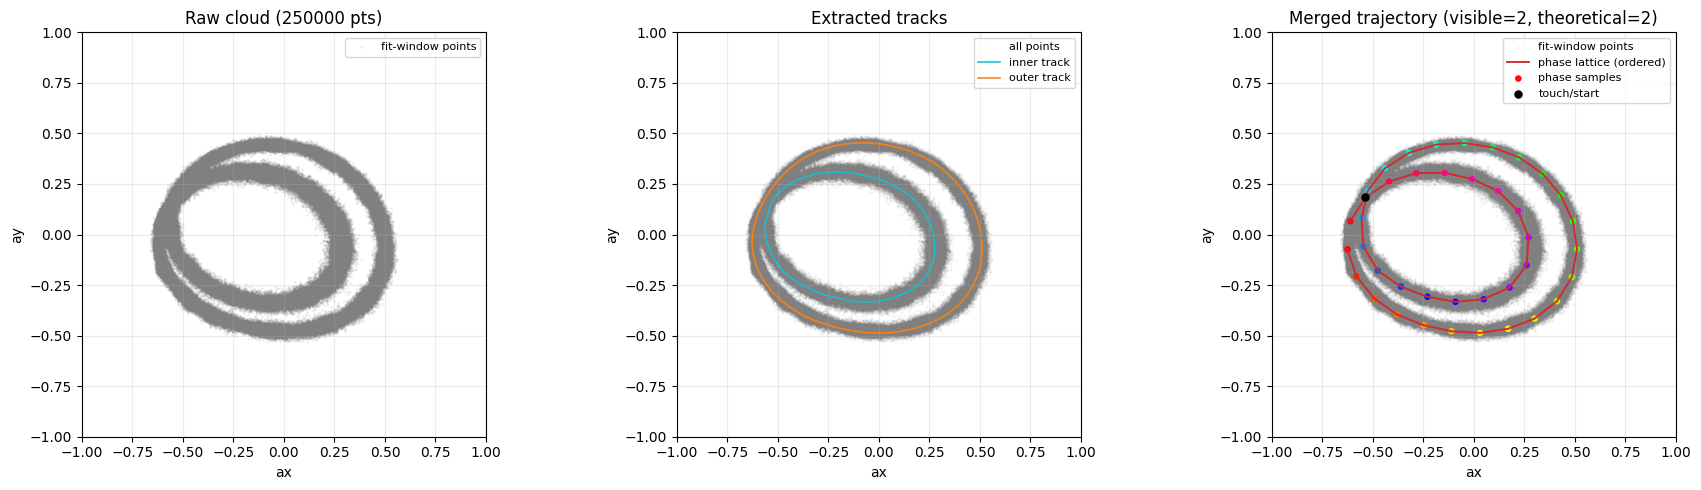

Track topology: visible=2, theoretical=2
Merged-track points: 483


In [54]:
# ── Reference extraction + merged-trajectory construction ──────────────────────
# Helper functions used here (_extract_tracks_polar, _build_touch_merge_dual,
# _build_touch_merge_single_sym, _blend_to_touch_local, _idx_circ) are defined
# in Section 5.

# Sampling / smoothing
N_SUBSAMPLE = 40

# Track topology (the only topology controls)
VISIBLE_TRACK = 2
THEORETICAL_TRACK = 2
if (VISIBLE_TRACK, THEORETICAL_TRACK) not in ((2, 2), (1, 2), (1, 1)):
    raise ValueError("Supported (VISIBLE_TRACK, THEORETICAL_TRACK) are (2,2), (1,2), (1,1)")

# Polar extraction controls
POLAR_N_BINS = max(180, 4 * N_SUBSAMPLE)
POLAR_Q_LOW, POLAR_Q_HIGH = 0.16, 0.84
POLAR_MIN_BIN = 8
POLAR_SMOOTH_WINDOW = 31

# Matching controls (actual phase matching happens in Section 6b)
FORCE_UNIQUE = False

# ── Decimate raw data over fit window ──────────────────────────────────────────
fit_s = int((fit_start_s - time_off) / time_inc) if fit_start_s is not None else 0
fit_e = int((fit_end_s - time_off) / time_inc) if fit_end_s is not None else datasize
fit_s = max(0, min(fit_s, datasize))
fit_e = max(fit_s, min(fit_e, datasize))

_c0_dec = c0_raw[fit_s:fit_e:dec_correction]
_c90_dec = c90_raw[fit_s:fit_e:dec_correction]
_c45_dec = c45_raw[fit_s:fit_e:dec_correction]
_c135_dec = c135_raw[fit_s:fit_e:dec_correction]
_t_dec = time_s[fit_s:fit_e:dec_correction]

_ax_raw, _ay_raw = anisotropy_from_channels(_c0_dec, _c90_dec, _c45_dec, _c135_dec)
_cyc_start, _cyc_end = 0, len(_ax_raw)
_ax_cyc = _ax_raw
_ay_cyc = _ay_raw
_n_cyc = len(_ax_cyc)
if len(_t_dec) > 0:
    print(f"Reference source window: [{_cyc_start}, {_cyc_end}] ({_n_cyc} pts / {len(_ax_raw)})")
    print(f"  Time: {_t_dec[0]:.3f} - {_t_dec[-1]:.3f} s")

# ── Extract tracks from full window ────────────────────────────────────────────
_sx_inner_dense, _sy_inner_dense, _sx_mid_dense, _sy_mid_dense, _sx_outer_dense, _sy_outer_dense = _extract_tracks_polar(
    _ax_cyc, _ay_cyc,
    n_bins=POLAR_N_BINS,
    q_low=POLAR_Q_LOW,
    q_high=POLAR_Q_HIGH,
    min_bin=POLAR_MIN_BIN,
    smooth_w=POLAR_SMOOTH_WINDOW,
)

# Visible-track interpretation
if VISIBLE_TRACK == 1:
    _sx_vis = np.copy(_sx_mid_dense)
    _sy_vis = np.copy(_sy_mid_dense)
    _sx_inner_plot = None
    _sy_inner_plot = None
    _sx_outer_plot = None
    _sy_outer_plot = None
else:
    _sx_vis = np.copy(_sx_mid_dense)
    _sy_vis = np.copy(_sy_mid_dense)
    _sx_inner_plot = _sx_inner_dense
    _sy_inner_plot = _sy_inner_dense
    _sx_outer_plot = _sx_outer_dense
    _sy_outer_plot = _sy_outer_dense

# ── Build merged trajectory according to (VISIBLE_TRACK, THEORETICAL_TRACK) ───
_sx_merge_track = None
_sy_merge_track = None
_touch_pt = None

if (VISIBLE_TRACK, THEORETICAL_TRACK) == (2, 2):
    _sx_merge_track, _sy_merge_track, _touch_pt, _dA, _aA, _orient = _build_touch_merge_dual(
        _sx_inner_dense, _sy_inner_dense, _sx_outer_dense, _sy_outer_dense
    )
    print(f"Merged track (2,2): touch distance={_dA:.5f}, tangent_pen={_aA:.4f}, orient={_orient:+d}")

elif (VISIBLE_TRACK, THEORETICAL_TRACK) == (1, 2):
    _sx_merge_track, _sy_merge_track, _touch_pt, _tmin, _tmax, _it = _build_touch_merge_single_sym(
        _sx_vis, _sy_vis
    )
    print(f"Merged track (1,2): symmetry-touch tangent min={_tmin:.5f}, max={_tmax:.5f}, idx={_it}")

elif (VISIBLE_TRACK, THEORETICAL_TRACK) == (1, 1):
    n_merge = int(max(len(_sx_vis), 240))
    _sx_merge_track, _sy_merge_track = _smooth_cycle_2d(
        _sx_vis, _sy_vis,
        smoothing=0.0,
        num_points=n_merge,
        resample_n=max(2 * n_merge, 400),
    )
    _touch_pt = np.array([_sx_merge_track[0], _sy_merge_track[0]])
    print("Merged track (1,1): single-loop trajectory")

else:
    raise RuntimeError("Unhandled track topology.")

# ── Diagnostics ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=100)

axes[0].scatter(_ax_raw, _ay_raw, s=1, alpha=0.10, c="grey", rasterized=True, label="fit-window points")
axes[0].set_title(f"Raw cloud ({_n_cyc} pts)")
axes[0].legend(fontsize=8)

axes[1].scatter(_ax_raw, _ay_raw, s=1, alpha=0.06, c="grey", rasterized=True, label="all points")
if _sx_inner_plot is not None and _sx_outer_plot is not None:
    axes[1].plot(_sx_inner_plot, _sy_inner_plot, "-", c="tab:cyan", lw=1.2, alpha=0.95, label="inner track")
    axes[1].plot(_sx_outer_plot, _sy_outer_plot, "-", c="tab:orange", lw=1.2, alpha=0.95, label="outer track")
elif VISIBLE_TRACK == 1:
    axes[1].plot(_sx_vis, _sy_vis, "-", c="tab:orange", lw=1.2, alpha=0.95, label="single extracted track")
axes[1].set_title(f"Extracted tracks")
axes[1].legend(fontsize=8)

# Render panel 3 in the same phase-order style as the matching diagnostics.
_pts_m = np.column_stack([np.asarray(_sx_merge_track, float), np.asarray(_sy_merge_track, float)])
if len(_pts_m) >= 3 and np.linalg.norm(_pts_m[0] - _pts_m[-1]) < 1e-12:
    _pts_m = _pts_m[:-1]
_pts_m_closed = np.vstack([_pts_m, _pts_m[0]])
_dxy_m = np.diff(_pts_m_closed, axis=0)
_ds_m = np.hypot(_dxy_m[:, 0], _dxy_m[:, 1])
_s_m = np.concatenate([[0.0], np.cumsum(_ds_m)])
_L_m = float(_s_m[-1])
if _L_m > 1e-12:
    _su_m = np.linspace(0.0, _L_m, N_SUBSAMPLE, endpoint=False)
    _sx_m = np.interp(_su_m, _s_m, _pts_m_closed[:, 0])
    _sy_m = np.interp(_su_m, _s_m, _pts_m_closed[:, 1])
    _i0_m = int(np.argmin(_sx_m))
    _sx_m = np.roll(_sx_m, -_i0_m)
    _sy_m = np.roll(_sy_m, -_i0_m)
else:
    _sx_m = np.asarray(_sx_merge_track, float)
    _sy_m = np.asarray(_sy_merge_track, float)

axes[2].scatter(_ax_raw, _ay_raw, s=1, alpha=0.06, c="grey", rasterized=True, label="fit-window points")
axes[2].plot(_sx_m, _sy_m, "-", c="tab:red", lw=1.4, alpha=0.95, label="phase lattice (ordered)")
axes[2].scatter(_sx_m, _sy_m, s=14, c=np.linspace(0, 1, len(_sx_m)), cmap='hsv', alpha=0.95, label="phase samples")
if _touch_pt is not None:
    axes[2].scatter(_touch_pt[0], _touch_pt[1], s=26, c="k", zorder=5, label="touch/start")
axes[2].set_title(f"Merged trajectory (visible={VISIBLE_TRACK}, theoretical={THEORETICAL_TRACK})")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect("equal")
    ax.set_xlabel("ax")
    ax.set_ylabel("ay")
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Track topology: visible={VISIBLE_TRACK}, theoretical={THEORETICAL_TRACK}")
print(f"Merged-track points: {len(_sx_merge_track)}")


## 6b. Phase lattice and nearest-match

Build `N_SUBSAMPLE` arc-length-evenly spaced phase samples on the merged trajectory from Section 6, anchor phase 0 at the leftmost sample, and assign each phase point its nearest raw point from the full fit window.

The matched arrays (`c0_fit`, `c90_fit`, `c45_fit`, `c135_fit` and `_ax_sub`, `_ay_sub`) are explicitly **ordered by merged-track phase**, not by acquisition time. Downstream channel correction (Section 7) and shape fitting (Section 9) consume them in this order.

Set `FORCE_UNIQUE = True` to require unique raw-point assignments per phase sample (greedy distance-optimal); the default `False` allows multiple phase points to land on the same raw point when the merged track passes near itself.


Phase-matching for shape fitting:
  source: merged track
  track topology: visible=2, theoretical=2
  N phase points: 40
  phase parameterization: one full 0..2pi turn on the selected merged trajectory
  matched unique raw points: 40/40
  distance: mean=0.0005, max=0.0016
  fit arrays rebuilt: 40 points (phase-ordered)


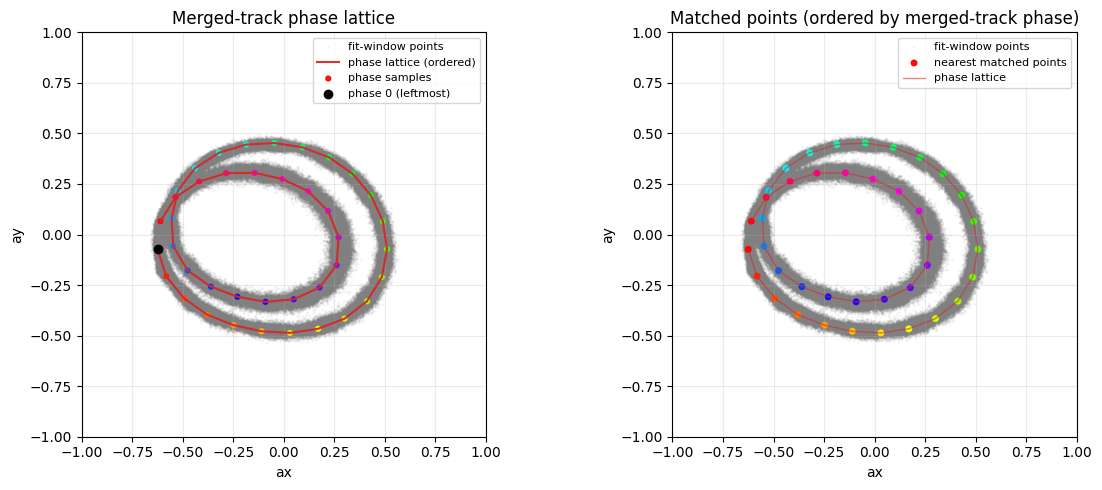

In [55]:
# ── Phase-ordered matching from merged track (for shape fitting) ───────────────
# Build N_SUBSAMPLE evenly spaced phase points on the merged track, set phase 0 to
# the leftmost merged-track point, and match each phase point to its nearest raw
# point over the full fit window. The selected fit arrays are ordered by merged-track
# phase (not by original time/index order).

if ('_sx_merge_track' not in globals()) or (_sx_merge_track is None) or (len(_sx_merge_track) < 3):
    raise RuntimeError(
        "Merged trajectory `_sx_merge_track` is not available. "
        "Run the reference-extraction cell first."
    )

_sx_phase_src = np.asarray(_sx_merge_track, dtype=float)
_sy_phase_src = np.asarray(_sy_merge_track, dtype=float)

_phase_pts0 = np.column_stack([_sx_phase_src, _sy_phase_src])

# Remove duplicated closure point if present.
if np.linalg.norm(_phase_pts0[0] - _phase_pts0[-1]) < 1e-12:
    _phase_pts0 = _phase_pts0[:-1]

# Closed arc-length parametrization.
_phase_closed = np.vstack([_phase_pts0, _phase_pts0[0]])
_phase_dxy = np.diff(_phase_closed, axis=0)
_phase_ds = np.hypot(_phase_dxy[:, 0], _phase_dxy[:, 1])
_phase_s = np.concatenate([[0.0], np.cumsum(_phase_ds)])
_phase_L = float(_phase_s[-1])
if _phase_L <= 1e-12:
    raise RuntimeError('Phase source has near-zero arc length.')

# Uniform phase lattice with endpoint=False (last point is one step before wrap).
_phase_su = np.linspace(0.0, _phase_L, N_SUBSAMPLE, endpoint=False)
_sx_phase = np.interp(_phase_su, _phase_s, _phase_closed[:, 0])
_sy_phase = np.interp(_phase_su, _phase_s, _phase_closed[:, 1])

# Enforce phase=0 at the leftmost sampled phase point.
_i_left = int(np.argmin(_sx_phase))
_sx_ref = np.roll(_sx_phase, -_i_left)
_sy_ref = np.roll(_sy_phase, -_i_left)

_ref_pts = np.column_stack([_sx_ref, _sy_ref])
_raw_pts_full = np.column_stack([_ax_raw, _ay_raw])
_all_d = np.linalg.norm(_raw_pts_full[None, :, :] - _ref_pts[:, None, :], axis=2)

_matched_idx = np.argmin(_all_d, axis=1)
_matched_dist = _all_d[np.arange(N_SUBSAMPLE), _matched_idx]

# Optional uniqueness across matched raw points (kept distance-optimal greedily).
if FORCE_UNIQUE:
    _order = np.argsort(_matched_dist)
    _taken = np.zeros(len(_ax_raw), dtype=bool)
    _idx_u = np.empty_like(_matched_idx)
    for _ri in _order:
        _j = int(_matched_idx[_ri])
        if not _taken[_j]:
            _idx_u[_ri] = _j
            _taken[_j] = True
        else:
            _cand = np.argsort(_all_d[_ri])
            for _jj in _cand:
                if not _taken[_jj]:
                    _idx_u[_ri] = int(_jj)
                    _taken[_jj] = True
                    break
    _matched_idx = _idx_u
    _matched_dist = np.linalg.norm(_raw_pts_full[_matched_idx] - _ref_pts, axis=1)

# Keep these arrays explicitly phase-ordered for downstream shape fitting.
_phase_order = np.arange(N_SUBSAMPLE)
_phase_frac = _phase_order / float(N_SUBSAMPLE)

_ax_sub = _ax_raw[_matched_idx]
_ay_sub = _ay_raw[_matched_idx]
_n_unique = len(np.unique(_matched_idx))

c0_fit = _c0_dec[_matched_idx]
c90_fit = _c90_dec[_matched_idx]
c45_fit = _c45_dec[_matched_idx]
c135_fit = _c135_dec[_matched_idx]

print('Phase-matching for shape fitting:')
print('  source: merged track')
if 'VISIBLE_TRACK' in globals() and 'THEORETICAL_TRACK' in globals():
    print(f'  track topology: visible={VISIBLE_TRACK}, theoretical={THEORETICAL_TRACK}')
print(f'  N phase points: {N_SUBSAMPLE}')
print('  phase parameterization: one full 0..2pi turn on the selected merged trajectory')
print(f'  matched unique raw points: {_n_unique}/{N_SUBSAMPLE}')
print(f'  distance: mean={np.mean(_matched_dist):.4f}, max={np.max(_matched_dist):.4f}')
print(f'  fit arrays rebuilt: {len(c0_fit)} points (phase-ordered)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)
axes[0].scatter(_ax_raw, _ay_raw, s=1, alpha=0.07, c='grey', rasterized=True, label='fit-window points')
axes[0].plot(_sx_ref, _sy_ref, '-', c='tab:red', lw=1.5, alpha=0.95, label='phase lattice (ordered)')
axes[0].scatter(_sx_ref, _sy_ref, s=12, c=np.linspace(0, 1, N_SUBSAMPLE), cmap='hsv', alpha=0.9, label='phase samples')
axes[0].scatter(_sx_ref[0], _sy_ref[0], s=36, c='k', zorder=5, label='phase 0 (leftmost)')
axes[0].set_title('Merged-track phase lattice')
axes[0].legend(fontsize=8)

axes[1].scatter(_ax_raw, _ay_raw, s=1, alpha=0.07, c='grey', rasterized=True, label='fit-window points')
axes[1].scatter(_ax_sub, _ay_sub, s=16, c=_phase_frac, cmap='hsv', alpha=0.95, label='nearest matched points')
axes[1].plot(_sx_ref, _sy_ref, '-', c='tab:red', lw=1.0, alpha=0.55, label='phase lattice')
axes[1].set_title('Matched points (ordered by merged-track phase)')
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    ax.set_xlabel('ax')
    ax.set_ylabel('ay')
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 7. Channel correction

Computes per-channel gains `a = [a_90, a_45, a_135, a_0]` from the phase-ordered fit subset, then applies gain -> T-matrix to build `tcor_fit_sub` for shape fitting.

If any channel goes negative after gain application, a warning is printed — usually indicates dropouts/blinks in the raw signal that should be masked out upstream rather than papered over with a DC offset.

In [56]:
# ── Channel correction (phase-ordered fit segment) ────────────────────────────
# c0_fit, c90_fit, c45_fit, c135_fit are built in Section 6b from merged-track phase matching.

# Stack-order index map [c0, c90, c45, c135] -> positions in the [c90, c45, c135, c0] stack.
# Used here and re-used by all downstream cells operating on `tcor_*` stacks.
_idx_fit = get_pol_ind(["0", "90", "45", "135"])

if not use_tmatrix:
    matcor = np.eye(4)
    print("T-matrix correction disabled — using identity matrix.")

if a_manual is not None:
    a = list(a_manual)
    print(f"Channel correction: using manual a = {[f'{v:.4f}' for v in a]}")
else:
    gain_fit = find_best_coeff_using_mat(c0_fit, c90_fit, c45_fit, c135_fit, matcorb)
    l90, l45, l135 = gain_fit.x
    a = [1.0, 1.0, 1.0, 1.0]
    a[get_pol_ind(["90"])[0]] = float(l90)
    a[get_pol_ind(["45"])[0]] = float(l45)
    a[get_pol_ind(["135"])[0]] = float(l135)
    print(f"Channel correction: computed a = {[f'{v:.4f}' for v in a]}")

print(f"Gain   a = {[f'{v:.4g}' for v in a]}")
if any(v < 0 for v in a):
    print(f"WARNING: negative channel coefficient — {a}")

fit_stack = np.vstack((c90_fit, c45_fit, c135_fit, c0_fit)).astype(float)
for i in range(4):
    fit_stack[i] = a[i] * fit_stack[i]

_neg_per_ch = [int(np.sum(fit_stack[i] < 0)) for i in range(4)]
if any(_neg_per_ch):
    _ch_labels = ["c90", "c45", "c135", "c0"]
    print("WARNING: negative samples after gain in fit segment — "
          + ", ".join(f"{lbl}={n}" for lbl, n in zip(_ch_labels, _neg_per_ch))
          + " (consider masking dropouts upstream).")


tcor_fit_sub = np.dot(matcor, fit_stack)
del fit_stack

print(f"Gain + T-matrix applied to fit segment ({tcor_fit_sub.shape[1]} pts).")

Channel correction: using manual a = ['1.0800', '1.1600', '1.0200', '1.0000']
Gain   a = ['1.08', '1.16', '1.02', '1']
Gain + T-matrix applied to fit segment (40 pts).


## 8. Fourkas calibration constants

Set `NA_CALIBRATED` (effective NA from your calibration procedure) and refractive index `nw`.
Computes the Fourkas A, B, C coefficients and the saturation anisotropy radius `R_sat = C / (A + B)`.

### Hole-correction toggle

Set `USE_HOLE_CORRECTION = True` to switch from the legacy full-cone Fourkas formula to an
**annular-collection** path that integrates over the actual BFP annulus (inner hole to outer rim).

| Parameter | Meaning | Default |
|-----------|---------|--------|
| `USE_HOLE_CORRECTION` | Enable annular (hole) path | `False` |
| `NA_out` | Outer numerical aperture of collection annulus | `1.3` |
| `NA_in`  | Inner numerical aperture (hole edge) | `0.38` |

**Annular integrals** (beta = aperture polar angle):

$$J_1 = \int_{\alpha_{in}}^{\alpha_{out}} \left[2\cos^2\beta + \tfrac{3}{4}\sin^4\beta\right]\sin\beta\,d\beta$$
$$J_2 = \int_{\alpha_{in}}^{\alpha_{out}} \tfrac{1}{4}\sin^4\beta\,\sin\beta\,d\beta$$
$$J_3 = \int_{\alpha_{in}}^{\alpha_{out}} \sin^2\beta\cos^2\beta\,\sin\beta\,d\beta$$

**Mapping to Fourkas A, B, C:**
$$C = J_1 - J_2, \quad A = 2J_3, \quad B = J_1 + J_2 - 2J_3$$


In [57]:
# ── Fourkas calibration constants ─────────────────────────────────────────────
from scipy.integrate import quad

NA_CALIBRATED = 1.28671   # effective NA from calibration (original NA = 1.3)
nw            = 1.33      # refractive index of immersion medium

# ── Hole-correction toggle ─────────────────────────────────────────────────────
USE_HOLE_CORRECTION = True  # set True to use annular (hole) collection path

# Annular collection NA limits (only used when USE_HOLE_CORRECTION = True)
NA_out = 1.3    # outer NA of collection annulus
NA_in  = 0.38   # inner NA (hole edge)

if USE_HOLE_CORRECTION:
    # ── Annular (hole) path ────────────────────────────────────────────────────
    alpha_out = np.arcsin(NA_out / nw)   # outer half-angle
    alpha_in  = np.arcsin(NA_in  / nw)   # inner half-angle (hole)

    # Integrands (integration variable beta = aperture polar angle)
    J1, _ = quad(lambda b: (2*np.cos(b)**2 + 0.75*np.sin(b)**4) * np.sin(b),
                 alpha_in, alpha_out)
    J2, _ = quad(lambda b: 0.25 * np.sin(b)**4 * np.sin(b),
                 alpha_in, alpha_out)
    J3, _ = quad(lambda b: np.sin(b)**2 * np.cos(b)**2 * np.sin(b),
                 alpha_in, alpha_out)

    # Map annular J-values to Fourkas-style coefficients
    C_cal = J1 - J2
    A_cal = 2 * J3
    B_cal = J1 + J2 - 2 * J3

    print(f"Hole correction ON  (NA_in={NA_in}, NA_out={NA_out}, n={nw})")
    print(f"alpha_in={np.degrees(alpha_in):.4f}\u00b0  alpha_out={np.degrees(alpha_out):.4f}\u00b0")
    print(f"J1={J1:.6f}  J2={J2:.6f}  J3={J3:.6f}")
else:
    # ── Legacy path (full-cone Fourkas) ───────────────────────────────────────
    alpha_calib   = np.arcsin(NA_CALIBRATED / nw)
    A_cal, B_cal, C_cal = fourkas_ABC(alpha_calib)

    print(f"Hole correction OFF — legacy Fourkas path")
    print(f"NA_calibrated = {NA_CALIBRATED}  (original NA = 1.3)")
    print(f"\u03b1 = {np.degrees(alpha_calib):.4f}\u00b0")

R_SAT = C_cal / (A_cal + B_cal)

print(f"A={A_cal:.6f}  B={B_cal:.6f}  C={C_cal:.6f}")
print(f"r_sat = {R_SAT:.5f}")

_c0_fc   = tcor_fit_sub[_idx_fit[0]]
_c90_fc  = tcor_fit_sub[_idx_fit[1]]
_c45_fc  = tcor_fit_sub[_idx_fit[2]]
_c135_fc = tcor_fit_sub[_idx_fit[3]]

_ax_fit, _ay_fit = anisotropy_from_channels(_c0_fc, _c90_fc, _c45_fc, _c135_fc)

print(f"\nFit segment: {tcor_fit_sub.shape[1]:,} points")
print(f"Anisotropy range: ax \u2208 [{_ax_fit.min():.4f}, {_ax_fit.max():.4f}],  "
      f"ay \u2208 [{_ay_fit.min():.4f}, {_ay_fit.max():.4f}]")


Hole correction ON  (NA_in=0.38, NA_out=1.3, n=1.33)
alpha_in=16.6015°  alpha_out=77.8075°
J1=0.826623  J2=0.082060  J3=0.128657
A=0.257315  B=0.651368  C=0.744563
r_sat = 0.81939

Fit segment: 40 points
Anisotropy range: ax ∈ [-0.6556, 0.4716],  ay ∈ [-0.4279, 0.5130]


## 9. Shape fitting

Core optimisation cell. Fits 6 parameters to the phase-ordered anisotropy fit subset:

| Parameter | Meaning |
|-----------|---------|
| **Theta_axis** | Polar angle of the rotation axis (degrees) |
| **Phi_axis** | Azimuthal angle of the rotation axis (degrees) |
| **Lambda** | Cone half-angle (degrees) |
| **dc** | Total per-channel background intensity (sum of paired backgrounds) |
| **fa** | Fractional 0°/90° background asymmetry |
| **fb** | Fractional 45°/135° background asymmetry |

**Background parametrization.** Backgrounds for the four polarisation channels are derived from `(dc, fa, fb)` as

$$b_0 = \tfrac{dc + fa\cdot dc}{2},\quad b_{90} = \tfrac{dc - fa\cdot dc}{2},\quad b_{45} = \tfrac{dc + fb\cdot dc}{2},\quad b_{135} = \tfrac{dc - fb\cdot dc}{2}$$

so `dc` is the *sum* of paired channel backgrounds (`b_0 + b_90 = b_45 + b_135 = dc`) and `fa`, `fb ∈ [-1, 1]` set the asymmetry within each pair.

**Algorithm:** Alternating differential evolution (DE):
1. geometry fit with background fixed;
2. background fit with geometry fixed;
then repeated for `N_OUTER_ITERATIONS`, followed by joint L-BFGS-B polish.

The reported 1σ uncertainties come from a finite-difference Hessian of the cost at the optimum and are approximate (the cost has interpolation/`min(fwd,rev)` discontinuities).

Tune with: `N_OUTER_ITERATIONS`, `DE_MAXITER`, `DE_POPSIZE`, `DE_TOL`.


Fit channel data for shape fitting: 40 points
Model phase domain: fourkas_template uses psi in [0, 2pi) for each evaluation (N_model=720 in fit).
δc upper bound: 0.5655

Running 4-iteration alternating optimization:
  Stage 1: DE on (Θ, Φ, Λ) with background fixed
  Stage 2: DE on (δc, fa, fb) with geometry fixed

Outer iteration 1/4
  Stage 1: fit (Θ, Φ, Λ) | fixed δc=0.0000, fa=0.0000, fb=0.0000
    → Θ=68.01°  Φ=-9.40°  Λ=83.21°  cost=0.02415
  Stage 2: fit (δc, fa, fb) | fixed Θ=68.01°, Φ=-9.40°, Λ=83.21°
    → δc=0.1882  fa=0.4843  fb=-0.1860  cost=0.005116
Outer iteration 2/4
  Stage 1: fit (Θ, Φ, Λ) | fixed δc=0.1882, fa=0.4843, fb=-0.1860
    → Θ=68.48°  Φ=170.97°  Λ=83.27°  cost=0.005047
  Stage 2: fit (δc, fa, fb) | fixed Θ=68.48°, Φ=170.97°, Λ=83.27°
    → δc=0.1770  fa=0.5579  fb=-0.1885  cost=0.004981
Outer iteration 3/4
  Stage 1: fit (Θ, Φ, Λ) | fixed δc=0.1770, fa=0.5579, fb=-0.1885
    → Θ=68.94°  Φ=-8.96°  Λ=83.38°  cost=0.004928
  Stage 2: fit (δc, fa, fb) | fixed Θ=

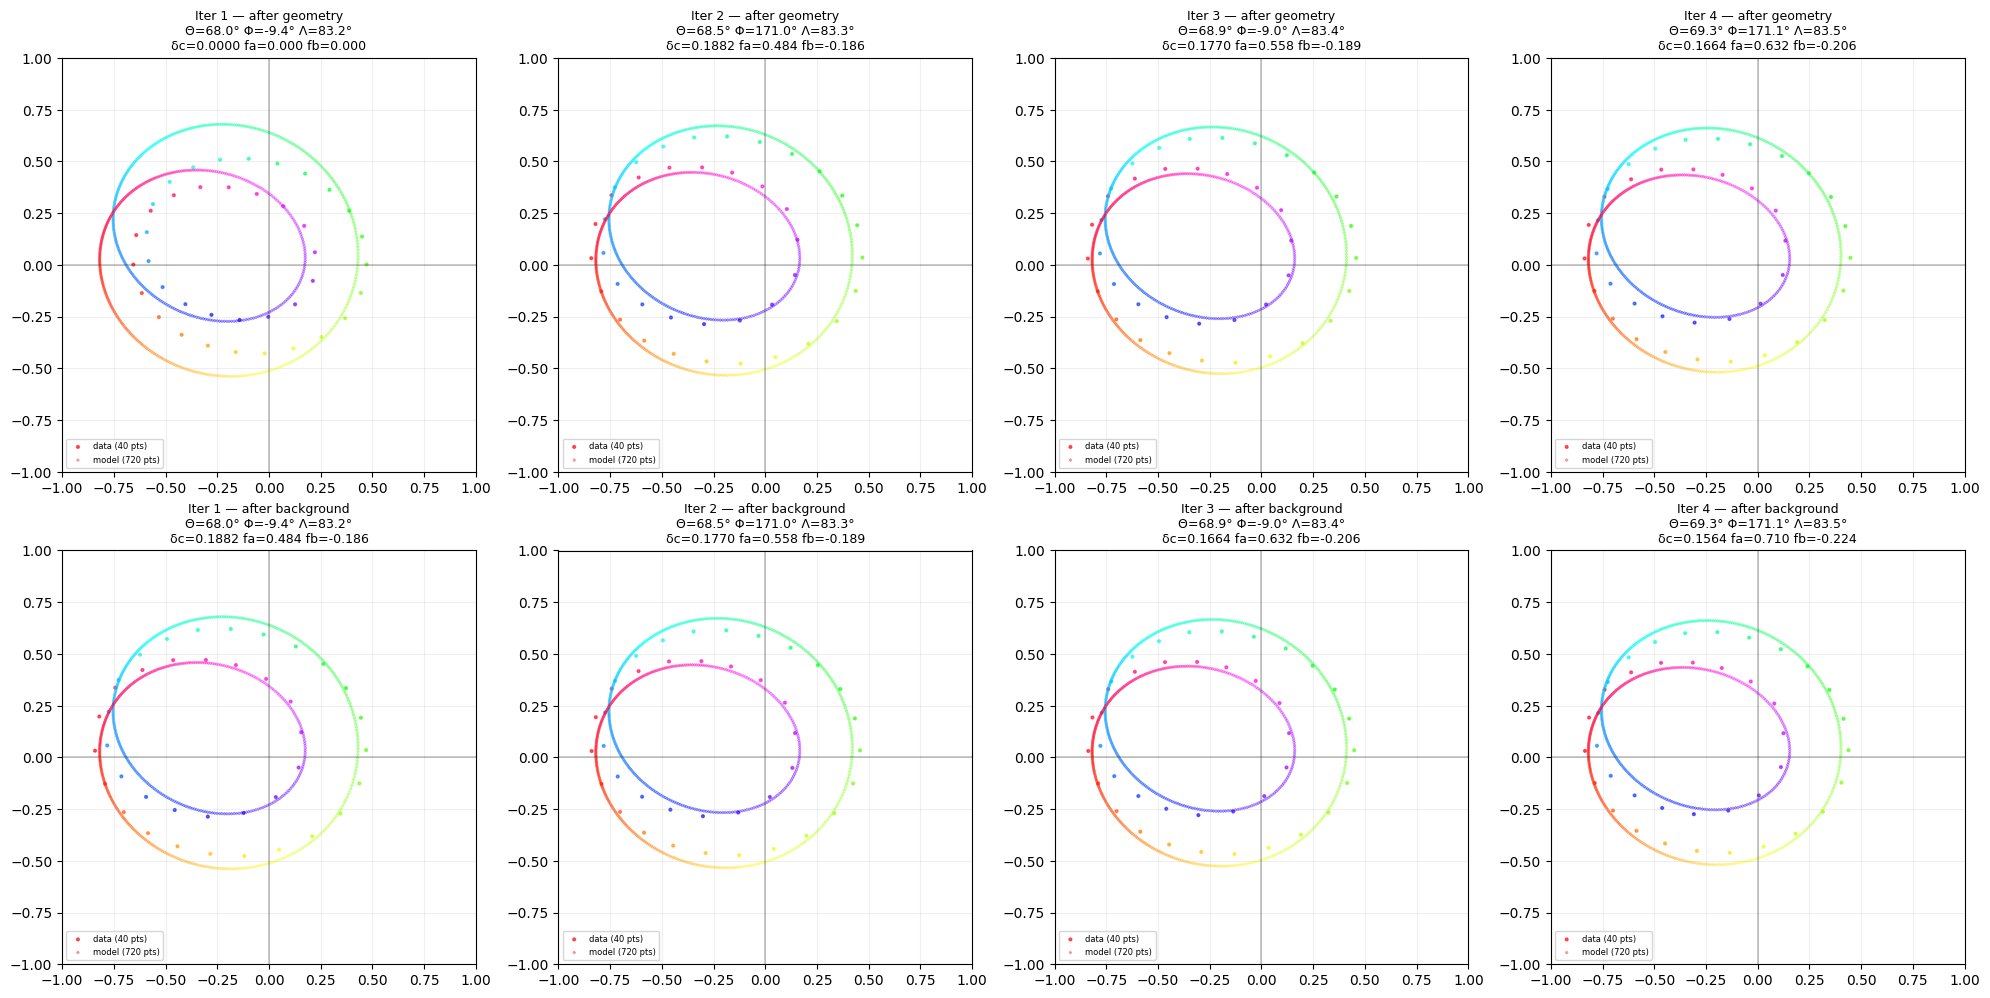


Final fit:
Θ_axis = 69.346°
Φ_axis = 171.086°
Λ      = 83.468°
δc     = 0.156411
fa     = 0.709669
fb     = -0.224170
Cost   = 0.00479613

Derived channel backgrounds:
b0   = 0.133706
b90  = 0.022705
b45  = 0.060674
b135 = 0.095737

Approximate 1σ uncertainties (Hessian inverse):
σ(Θ_axis) = 0.0005377
σ(Φ_axis) = 0.0005377
σ(Λ)      = 0.0005377
σ(δc)     = 1.452
σ(fa)     = 9.637
σ(fb)     = 4.983


In [58]:
# ══════════════════════════════════════════════════════════════════════════════
# SHAPE FIT — Arc-length matching with two-stage alternating optimisation
# ══════════════════════════════════════════════════════════════════════════════
# tcor_fit_sub contains the phase-ordered fit segment (gain + T-matrix
# corrected). We use all points directly for the fit.

# ── User-configurable optimisation parameters ────────────────────────────
N_OUTER_ITERATIONS = 4
DE_MAXITER = 200
DE_POPSIZE = 15
DE_TOL     = 1e-6

# ── Arc-length helpers ───────────────────────────────────────────────────────
def _cumulative_arclen(ax, ay):
    dx = np.diff(ax)
    dy = np.diff(ay)
    ds = np.sqrt(dx**2 + dy**2)
    s = np.concatenate([[0.0], np.cumsum(ds)])
    total = s[-1]
    if total > 0:
        s /= total
    return s

def _reorder_from_leftmost(ax, ay):
    i0 = int(np.argmin(ax))
    return np.roll(ax, -i0), np.roll(ay, -i0)

def _interp_curve_at_fractions(ax, ay, fracs):
    s = _cumulative_arclen(ax, ay)
    return np.interp(fracs, s, ax), np.interp(fracs, s, ay)

# ── Extract fit-segment channel data ─────────────────────────────────────
_c0_cyc   = tcor_fit_sub[_idx_fit[0]]
_c90_cyc  = tcor_fit_sub[_idx_fit[1]]
_c45_cyc  = tcor_fit_sub[_idx_fit[2]]
_c135_cyc = tcor_fit_sub[_idx_fit[3]]

print(f"Fit channel data for shape fitting: {len(_c0_cyc)} points")
print("Model phase domain: fourkas_template uses psi in [0, 2pi) for each evaluation (N_model=720 in fit).")

# ── Cost function — arc-length matched residuals ─────────────────────────
def shape_fit_cost(params, cyc_c0, cyc_c90, cyc_c45, cyc_c135, A, B, C):
    Theta_ax, Phi_ax, Lam, dc, fa, fb = params
    da = fa * dc
    db = fb * dc
    b0   = (dc + da) / 2
    b90  = (dc - da) / 2
    b45  = (dc + db) / 2
    b135 = (dc - db) / 2

    c0_adj   = cyc_c0 - b0
    c90_adj  = cyc_c90 - b90
    c45_adj  = cyc_c45 - b45
    c135_adj = cyc_c135 - b135

    valid = (c0_adj > 0) & (c90_adj > 0) & (c45_adj > 0) & (c135_adj > 0)
    if valid.sum() < 20:
        return 1e6

    ax_d = (c0_adj[valid] - c90_adj[valid]) / (c0_adj[valid] + c90_adj[valid])
    ay_d = (c45_adj[valid] - c135_adj[valid]) / (c45_adj[valid] + c135_adj[valid])

    ax_d_r, ay_d_r = _reorder_from_leftmost(ax_d, ay_d)
    s_data = _cumulative_arclen(ax_d_r, ay_d_r)

    ax_m, ay_m = fourkas_template(Theta_ax, Phi_ax, Lam, A, B, C, N_model=720)
    if len(ax_m) < 5:
        return 1e6

    ax_m_r, ay_m_r = _reorder_from_leftmost(ax_m, ay_m)
    ax_m_interp, ay_m_interp = _interp_curve_at_fractions(ax_m_r, ay_m_r, s_data)
    cost_fwd = np.mean((ax_d_r - ax_m_interp)**2 + (ay_d_r - ay_m_interp)**2)

    ax_m_rev, ay_m_rev = _reorder_from_leftmost(ax_m[::-1], ay_m[::-1])
    ax_m_rev_interp, ay_m_rev_interp = _interp_curve_at_fractions(ax_m_rev, ay_m_rev, s_data)
    cost_rev = np.mean((ax_d_r - ax_m_rev_interp)**2 + (ay_d_r - ay_m_rev_interp)**2)

    return min(cost_fwd, cost_rev)

# ── δc upper bound ───────────────────────────────────────────────────────
dc_upper = max(0.0, min(float(np.min(_c0_cyc) + np.min(_c90_cyc)),
                        float(np.min(_c45_cyc) + np.min(_c135_cyc))))
print(f"δc upper bound: {dc_upper:.4f}")

# ── Parameter bounds ─────────────────────────────────────────────────────
_bounds_geom = [(0.0, 90.0), (-180.0, 180.0), (0.0, 90.0)]
_bounds_bg   = [(0.0, dc_upper), (-1.0, 1.0), (-1.0, 1.0)]  # fa, fb in [-1, 1] keeps b_k >= 0.
_bounds_all  = _bounds_geom + _bounds_bg

def _geom_cost(geom_params, dc, fa, fb, ec0, ec90, ec45, ec135, A, B, C):
    return shape_fit_cost([*geom_params, dc, fa, fb], ec0, ec90, ec45, ec135, A, B, C)

def _bg_cost(bg_params, Theta, Phi, Lam, ec0, ec90, ec45, ec135, A, B, C):
    return shape_fit_cost([Theta, Phi, Lam, *bg_params], ec0, ec90, ec45, ec135, A, B, C)

# ── Alternating optimization with diagnostics ────────────────────────────
_cur_dc, _cur_fa, _cur_fb = 0.0, 0.0, 0.0
_cur_Th, _cur_Ph, _cur_Lm = 45.0, 0.0, 20.0

print(f"\nRunning {N_OUTER_ITERATIONS}-iteration alternating optimization:")
print("  Stage 1: DE on (Θ, Φ, Λ) with background fixed")
print("  Stage 2: DE on (δc, fa, fb) with geometry fixed\n")

_diag_axes = plt.subplots(2, N_OUTER_ITERATIONS, figsize=(5 * N_OUTER_ITERATIONS, 10), dpi=100)[1]

for _outer in range(N_OUTER_ITERATIONS):
    print(f"{'='*70}")
    print(f"Outer iteration {_outer+1}/{N_OUTER_ITERATIONS}")
    print(f"{'='*70}")

    print(f"  Stage 1: fit (Θ, Φ, Λ) | fixed δc={_cur_dc:.4f}, fa={_cur_fa:.4f}, fb={_cur_fb:.4f}")
    _res_geom = differential_evolution(
        _geom_cost,
        bounds=_bounds_geom,
        args=(_cur_dc, _cur_fa, _cur_fb,
              _c0_cyc, _c90_cyc, _c45_cyc, _c135_cyc,
              A_cal, B_cal, C_cal),
        maxiter=DE_MAXITER, popsize=DE_POPSIZE, tol=DE_TOL,
        seed=42 + _outer, polish=True, disp=False, workers=1,
    )
    _cur_Th, _cur_Ph, _cur_Lm = _res_geom.x
    print(f"    → Θ={_cur_Th:.2f}°  Φ={_cur_Ph:.2f}°  Λ={_cur_Lm:.2f}°  cost={_res_geom.fun:.4g}")

    _da_d = _cur_fa * _cur_dc
    _db_d = _cur_fb * _cur_dc
    _c0_d   = _c0_cyc   - (_cur_dc + _da_d) / 2
    _c90_d  = _c90_cyc  - (_cur_dc - _da_d) / 2
    _c45_d  = _c45_cyc  - (_cur_dc + _db_d) / 2
    _c135_d = _c135_cyc - (_cur_dc - _db_d) / 2
    _v_d = (_c0_d > 0) & (_c90_d > 0) & (_c45_d > 0) & (_c135_d > 0)
    _ax_d = (_c0_d[_v_d] - _c90_d[_v_d]) / (_c0_d[_v_d] + _c90_d[_v_d])
    _ay_d = (_c45_d[_v_d] - _c135_d[_v_d]) / (_c45_d[_v_d] + _c135_d[_v_d])

    _ax_mr, _ay_mr = fourkas_template(_cur_Th, _cur_Ph, _cur_Lm, A_cal, B_cal, C_cal, N_model=720)

    _ax_d_r, _ay_d_r = _reorder_from_leftmost(_ax_d, _ay_d)
    _s_d_diag = _cumulative_arclen(_ax_d_r, _ay_d_r)
    _ax_m_r, _ay_m_r = _reorder_from_leftmost(_ax_mr, _ay_mr)
    _s_m_diag = _cumulative_arclen(_ax_m_r, _ay_m_r)

    _a1 = _diag_axes[0, _outer]
    _a1.scatter(_ax_d_r, _ay_d_r, s=4, c=_s_d_diag, cmap='hsv', alpha=0.6, label=f'data ({len(_ax_d)} pts)')
    _a1.scatter(_ax_m_r, _ay_m_r, s=2, c=_s_m_diag, cmap='hsv', alpha=0.4, marker='x', label=f'model ({len(_ax_mr)} pts)')
    _a1.set_title(
        f"Iter {_outer+1} — after geometry\n"
        f"Θ={_cur_Th:.1f}° Φ={_cur_Ph:.1f}° Λ={_cur_Lm:.1f}°\n"
        f"δc={_cur_dc:.4f} fa={_cur_fa:.3f} fb={_cur_fb:.3f}",
        fontsize=9,
    )
    _a1.set_xlim(-1, 1)
    _a1.set_ylim(-1, 1)
    _a1.set_aspect('equal')
    _a1.axhline(0, color='k', lw=0.3)
    _a1.axvline(0, color='k', lw=0.3)
    _a1.grid(alpha=0.2)
    _a1.legend(fontsize=6, loc='lower left')

    print(f"  Stage 2: fit (δc, fa, fb) | fixed Θ={_cur_Th:.2f}°, Φ={_cur_Ph:.2f}°, Λ={_cur_Lm:.2f}°")
    _res_bg = differential_evolution(
        _bg_cost,
        bounds=_bounds_bg,
        args=(_cur_Th, _cur_Ph, _cur_Lm,
              _c0_cyc, _c90_cyc, _c45_cyc, _c135_cyc,
              A_cal, B_cal, C_cal),
        maxiter=DE_MAXITER, popsize=DE_POPSIZE, tol=DE_TOL,
        seed=42 + _outer, polish=True, disp=False, workers=1,
    )
    _cur_dc, _cur_fa, _cur_fb = _res_bg.x
    print(f"    → δc={_cur_dc:.4f}  fa={_cur_fa:.4f}  fb={_cur_fb:.4f}  cost={_res_bg.fun:.4g}")

    _da_d2 = _cur_fa * _cur_dc
    _db_d2 = _cur_fb * _cur_dc
    _c0_d2   = _c0_cyc   - (_cur_dc + _da_d2) / 2
    _c90_d2  = _c90_cyc  - (_cur_dc - _da_d2) / 2
    _c45_d2  = _c45_cyc  - (_cur_dc + _db_d2) / 2
    _c135_d2 = _c135_cyc - (_cur_dc - _db_d2) / 2
    _v_d2 = (_c0_d2 > 0) & (_c90_d2 > 0) & (_c45_d2 > 0) & (_c135_d2 > 0)
    _ax_d2 = (_c0_d2[_v_d2] - _c90_d2[_v_d2]) / (_c0_d2[_v_d2] + _c90_d2[_v_d2])
    _ay_d2 = (_c45_d2[_v_d2] - _c135_d2[_v_d2]) / (_c45_d2[_v_d2] + _c135_d2[_v_d2])

    _ax_mr2, _ay_mr2 = fourkas_template(_cur_Th, _cur_Ph, _cur_Lm, A_cal, B_cal, C_cal, N_model=720)

    _ax_d2_r, _ay_d2_r = _reorder_from_leftmost(_ax_d2, _ay_d2)
    _s_d2_diag = _cumulative_arclen(_ax_d2_r, _ay_d2_r)
    _ax_m2_r, _ay_m2_r = _reorder_from_leftmost(_ax_mr2, _ay_mr2)
    _s_m2_diag = _cumulative_arclen(_ax_m2_r, _ay_m2_r)

    _a2 = _diag_axes[1, _outer]
    _a2.scatter(_ax_d2_r, _ay_d2_r, s=4, c=_s_d2_diag, cmap='hsv', alpha=0.6, label=f'data ({len(_ax_d2)} pts)')
    _a2.scatter(_ax_m2_r, _ay_m2_r, s=2, c=_s_m2_diag, cmap='hsv', alpha=0.4, marker='x', label=f'model ({len(_ax_mr2)} pts)')
    _a2.set_title(
        f"Iter {_outer+1} — after background\n"
        f"Θ={_cur_Th:.1f}° Φ={_cur_Ph:.1f}° Λ={_cur_Lm:.1f}°\n"
        f"δc={_cur_dc:.4f} fa={_cur_fa:.3f} fb={_cur_fb:.3f}",
        fontsize=9,
    )
    _a2.set_xlim(-1, 1)
    _a2.set_ylim(-1, 1)
    _a2.set_aspect('equal')
    _a2.axhline(0, color='k', lw=0.3)
    _a2.axvline(0, color='k', lw=0.3)
    _a2.grid(alpha=0.2)
    _a2.legend(fontsize=6, loc='lower left')

plt.tight_layout()
plt.show()

# ── Final joint polish ───────────────────────────────────────────────────
x0 = [_cur_Th, _cur_Ph, _cur_Lm, _cur_dc, _cur_fa, _cur_fb]
shape_fit_res = minimize(
    shape_fit_cost,
    x0,
    args=(_c0_cyc, _c90_cyc, _c45_cyc, _c135_cyc, A_cal, B_cal, C_cal),
    bounds=_bounds_all,
    method='L-BFGS-B',
)

Theta_axis_fitted, Phi_axis_fitted, Lambda_fitted, dc_fitted, fa_fitted, fb_fitted = shape_fit_res.x
print(f"\nFinal fit:")
print(f"Θ_axis = {Theta_axis_fitted:.3f}°")
print(f"Φ_axis = {Phi_axis_fitted:.3f}°")
print(f"Λ      = {Lambda_fitted:.3f}°")
print(f"δc     = {dc_fitted:.6f}")
print(f"fa     = {fa_fitted:.6f}")
print(f"fb     = {fb_fitted:.6f}")
print(f"Cost   = {shape_fit_res.fun:.6g}")

# ── Background decomposition ─────────────────────────────────────────────
da_fitted = fa_fitted * dc_fitted
db_fitted = fb_fitted * dc_fitted
b0_fitted   = (dc_fitted + da_fitted) / 2
b90_fitted  = (dc_fitted - da_fitted) / 2
b45_fitted  = (dc_fitted + db_fitted) / 2
b135_fitted = (dc_fitted - db_fitted) / 2

print("\nDerived channel backgrounds:")
print(f"b0   = {b0_fitted:.6f}")
print(f"b90  = {b90_fitted:.6f}")
print(f"b45  = {b45_fitted:.6f}")
print(f"b135 = {b135_fitted:.6f}")

# ── Numerical Hessian uncertainty estimate ───────────────────────────────
def numerical_hessian(func, x, eps=1e-5):
    x = np.asarray(x, dtype=float)
    n = len(x)
    H = np.zeros((n, n), dtype=float)
    f0 = func(x)
    for i in range(n):
        xi_p = x.copy(); xi_p[i] += eps
        xi_m = x.copy(); xi_m[i] -= eps
        f_ip = func(xi_p)
        f_im = func(xi_m)
        H[i, i] = (f_ip - 2 * f0 + f_im) / (eps ** 2)
        for j in range(i + 1, n):
            x_pp = x.copy(); x_pp[i] += eps; x_pp[j] += eps
            x_pm = x.copy(); x_pm[i] += eps; x_pm[j] -= eps
            x_mp = x.copy(); x_mp[i] -= eps; x_mp[j] += eps
            x_mm = x.copy(); x_mm[i] -= eps; x_mm[j] -= eps
            f_pp = func(x_pp)
            f_pm = func(x_pm)
            f_mp = func(x_mp)
            f_mm = func(x_mm)
            hij = (f_pp - f_pm - f_mp + f_mm) / (4 * eps ** 2)
            H[i, j] = hij
            H[j, i] = hij
    return H

_obj = lambda p: shape_fit_cost(p, _c0_cyc, _c90_cyc, _c45_cyc, _c135_cyc, A_cal, B_cal, C_cal)
H = numerical_hessian(_obj, shape_fit_res.x, eps=1e-5)

try:
    cov = np.linalg.inv(H)
    diag = np.diag(cov)
    uncertainties = np.sqrt(np.abs(diag))
except np.linalg.LinAlgError:
    cov = np.full_like(H, np.nan)
    uncertainties = np.full(6, np.nan)

print("\nApproximate 1σ uncertainties (Hessian inverse):")
print(f"σ(Θ_axis) = {uncertainties[0]:.4g}")
print(f"σ(Φ_axis) = {uncertainties[1]:.4g}")
print(f"σ(Λ)      = {uncertainties[2]:.4g}")
print(f"σ(δc)     = {uncertainties[3]:.4g}")
print(f"σ(fa)     = {uncertainties[4]:.4g}")
print(f"σ(fb)     = {uncertainties[5]:.4g}")

## 9b. Per-channel residual diagnostic

Diagnostic for `fa`/`fb` running into their bounds. After the shape fit, recomputes
the data anisotropy at the fitted backgrounds, matches each data point to the
model curve by arc-length (same as the fit cost), and plots the **per-axis residual**:

- `Δax = ax_data − ax_model` reflects mismatch on the (c0, c90) channel pair.
- `Δay = ay_data − ay_model` reflects mismatch on the (c45, c135) channel pair.

**What to look for**
- Concentrated residual in `Δay` only → 45/135 channel pair has uncorrected
  cross-talk or gain bias that `fb` is trying to absorb.
- Mean residual significantly nonzero → DC mismatch (background term not flexible
  enough).
- Sinusoidal pattern → gain/T-matrix or geometry misspecification, not background.
- Random scatter only → fit is OK, `fa`/`fb` reaching the bound is genuine.

**Note on bounds.** This diagnostic is most informative with `fa`, `fb` clamped to
`[-1, 1]` (the physical range, b_k ≥ 0). If they are unbounded, the fit will absorb
the antisymmetric residual and these plots will look flat — defeating the purpose.

Diagnostic — model orientation chosen: forward  (cost_fwd=0.004796, cost_rev=0.5071)
Δax (c0/c90 pair):   mean=+0.0060  std=0.0478  rms=0.0482
Δay (c45/c135 pair): mean=+0.0037  std=0.0496  rms=0.0498


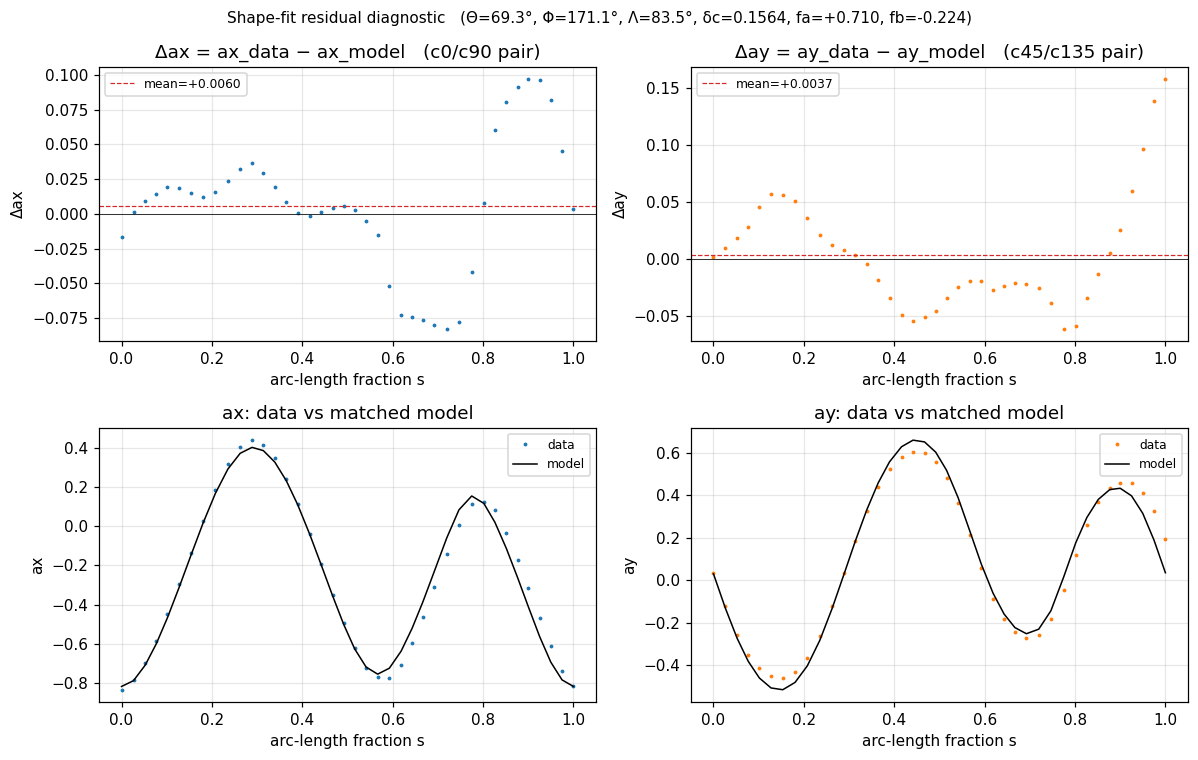

In [59]:
# ── Per-channel (per-axis) residual diagnostic ───────────────────────────────
# Recomputes the same arc-length-matched residual the fit minimized, then breaks
# it down by anisotropy axis (and therefore by channel pair).

_Th, _Ph, _Lm, _dc, _fa, _fb = shape_fit_res.x
_da = _fa * _dc
_db = _fb * _dc
_b0   = (_dc + _da) / 2
_b90  = (_dc - _da) / 2
_b45  = (_dc + _db) / 2
_b135 = (_dc - _db) / 2

_c0_d   = _c0_cyc   - _b0
_c90_d  = _c90_cyc  - _b90
_c45_d  = _c45_cyc  - _b45
_c135_d = _c135_cyc - _b135

_valid = (_c0_d > 0) & (_c90_d > 0) & (_c45_d > 0) & (_c135_d > 0)
if _valid.sum() < 20:
    raise RuntimeError("Diagnostic: <20 valid points after background subtraction.")

_ax_data = (_c0_d[_valid]  - _c90_d[_valid])  / (_c0_d[_valid]  + _c90_d[_valid])
_ay_data = (_c45_d[_valid] - _c135_d[_valid]) / (_c45_d[_valid] + _c135_d[_valid])

# Model curve, same orientation choice (fwd vs reversed) as the cost picks
_ax_data_r, _ay_data_r = _reorder_from_leftmost(_ax_data, _ay_data)
_s_data = _cumulative_arclen(_ax_data_r, _ay_data_r)

_ax_m_full, _ay_m_full = fourkas_template(_Th, _Ph, _Lm, A_cal, B_cal, C_cal, N_model=720)

_ax_m_fwd_r, _ay_m_fwd_r = _reorder_from_leftmost(_ax_m_full, _ay_m_full)
_ax_fwd, _ay_fwd = _interp_curve_at_fractions(_ax_m_fwd_r, _ay_m_fwd_r, _s_data)
_cost_fwd = np.mean((_ax_data_r - _ax_fwd) ** 2 + (_ay_data_r - _ay_fwd) ** 2)

_ax_m_rev_r, _ay_m_rev_r = _reorder_from_leftmost(_ax_m_full[::-1], _ay_m_full[::-1])
_ax_rev, _ay_rev = _interp_curve_at_fractions(_ax_m_rev_r, _ay_m_rev_r, _s_data)
_cost_rev = np.mean((_ax_data_r - _ax_rev) ** 2 + (_ay_data_r - _ay_rev) ** 2)

if _cost_fwd <= _cost_rev:
    _ax_model, _ay_model, _orient = _ax_fwd, _ay_fwd, "forward"
else:
    _ax_model, _ay_model, _orient = _ax_rev, _ay_rev, "reversed"

_d_ax = _ax_data_r - _ax_model
_d_ay = _ay_data_r - _ay_model

# Stats
_mean_dax, _std_dax = float(np.mean(_d_ax)), float(np.std(_d_ax))
_mean_day, _std_day = float(np.mean(_d_ay)), float(np.std(_d_ay))
_rms_dax = float(np.sqrt(np.mean(_d_ax ** 2)))
_rms_day = float(np.sqrt(np.mean(_d_ay ** 2)))

print(f"Diagnostic — model orientation chosen: {_orient}  (cost_fwd={_cost_fwd:.4g}, cost_rev={_cost_rev:.4g})")
print(f"Δax (c0/c90 pair):   mean={_mean_dax:+.4f}  std={_std_dax:.4f}  rms={_rms_dax:.4f}")
print(f"Δay (c45/c135 pair): mean={_mean_day:+.4f}  std={_std_day:.4f}  rms={_rms_day:.4f}")
if max(abs(_fa), abs(_fb)) >= 0.999:
    print(f"NOTE: fitted fa={_fa:+.3f}, fb={_fb:+.3f} at/near bound \u00b11. The pair with the larger residual is what fb (or fa) is trying to absorb.")

_fig_diag, _axes_diag = plt.subplots(2, 2, figsize=(11, 7), dpi=110)

# Top row: residual vs arc-length fraction
_axes_diag[0, 0].plot(_s_data, _d_ax, '.', ms=3, color='C0')
_axes_diag[0, 0].axhline(0, color='k', lw=0.5)
_axes_diag[0, 0].axhline(_mean_dax, color='C3', lw=0.8, ls='--', label=f'mean={_mean_dax:+.4f}')
_axes_diag[0, 0].set_title("Δax = ax_data − ax_model   (c0/c90 pair)")
_axes_diag[0, 0].set_xlabel("arc-length fraction s")
_axes_diag[0, 0].set_ylabel("Δax")
_axes_diag[0, 0].grid(alpha=0.3)
_axes_diag[0, 0].legend(fontsize=8)

_axes_diag[0, 1].plot(_s_data, _d_ay, '.', ms=3, color='C1')
_axes_diag[0, 1].axhline(0, color='k', lw=0.5)
_axes_diag[0, 1].axhline(_mean_day, color='C3', lw=0.8, ls='--', label=f'mean={_mean_day:+.4f}')
_axes_diag[0, 1].set_title("Δay = ay_data − ay_model   (c45/c135 pair)")
_axes_diag[0, 1].set_xlabel("arc-length fraction s")
_axes_diag[0, 1].set_ylabel("Δay")
_axes_diag[0, 1].grid(alpha=0.3)
_axes_diag[0, 1].legend(fontsize=8)

# Bottom row: data vs model overlays for context
_axes_diag[1, 0].plot(_s_data, _ax_data_r, '.', ms=3, label='data', color='C0')
_axes_diag[1, 0].plot(_s_data, _ax_model,  '-', lw=1.0, label='model', color='k')
_axes_diag[1, 0].set_title("ax: data vs matched model")
_axes_diag[1, 0].set_xlabel("arc-length fraction s")
_axes_diag[1, 0].set_ylabel("ax")
_axes_diag[1, 0].grid(alpha=0.3)
_axes_diag[1, 0].legend(fontsize=8)

_axes_diag[1, 1].plot(_s_data, _ay_data_r, '.', ms=3, label='data', color='C1')
_axes_diag[1, 1].plot(_s_data, _ay_model,  '-', lw=1.0, label='model', color='k')
_axes_diag[1, 1].set_title("ay: data vs matched model")
_axes_diag[1, 1].set_xlabel("arc-length fraction s")
_axes_diag[1, 1].set_ylabel("ay")
_axes_diag[1, 1].grid(alpha=0.3)
_axes_diag[1, 1].legend(fontsize=8)

_fig_diag.suptitle(
    f"Shape-fit residual diagnostic   (Θ={_Th:.1f}°, Φ={_Ph:.1f}°, Λ={_Lm:.1f}°, "
    f"δc={_dc:.4f}, fa={_fa:+.3f}, fb={_fb:+.3f})",
    fontsize=10,
)
plt.tight_layout()
plt.show()

## 9c. Orthogonal (point-to-curve) refit — diagnostic

The default cost in Section 9 matches data and model by **arc-length fraction** along their respective closed loops. This biases the residual whenever the loop is not a perfect circle (data and model parametrise their loops at different speeds), and it concentrates error at the seam where both curves are reordered to start at `argmin(ax)`.

This cell refits the same 6 parameters using a **point-to-curve** cost: for each data point, find the perpendicular distance to a finely-sampled model curve (KDTree nearest-neighbour). No phase ordering, no seam.

We run it from several starting points (current Section 9 solution + a small grid in Θ) to also test whether the bad sample is sitting in a degenerate local minimum near Θ ≈ 0°.

**Reading the output**
- If orthogonal cost ≪ arc-length cost at the same parameters → arc-length matching is the issue.
- If a different Θ-seed gives a much lower cost → Section 9 was stuck in a local minimum.
- If `fb` settles to an interior value → background bound was just absorbing parametrisation error.
- If `fb` still pegs at ±1 → real upstream issue (T-matrix / gain).

Orthogonal-cost evaluation at Section-9 solution: 0.00119451
Arc-length cost at Section-9 solution:           0.00479613

Seed                         Θ        Φ       Λ        δc       fa       fb        cost
------------------------------------------------------------------------------------
Sec9 solution            68.71   175.26   84.53    0.1683   +0.647   +0.019   0.0007404
Θ=30°, Φ=0°              66.61    31.26   83.21    0.2167   +0.015   +0.995    0.001839
Θ=60°, Φ=0°              68.86    -4.12   84.60    0.1643   +0.686   +0.052   0.0007399
Θ=45°, Φ=90°             65.69    59.69   84.15    0.2164   -1.000   +1.000    0.001889
Θ=45°, Φ=-90°            64.20  -105.17   83.68    0.2663   -1.000   +0.449    0.002234

Best orthogonal fit: 'Θ=60°, Φ=0°'  cost=0.000739937
fa=+0.686, fb=+0.052 interior — background bounds are not active.


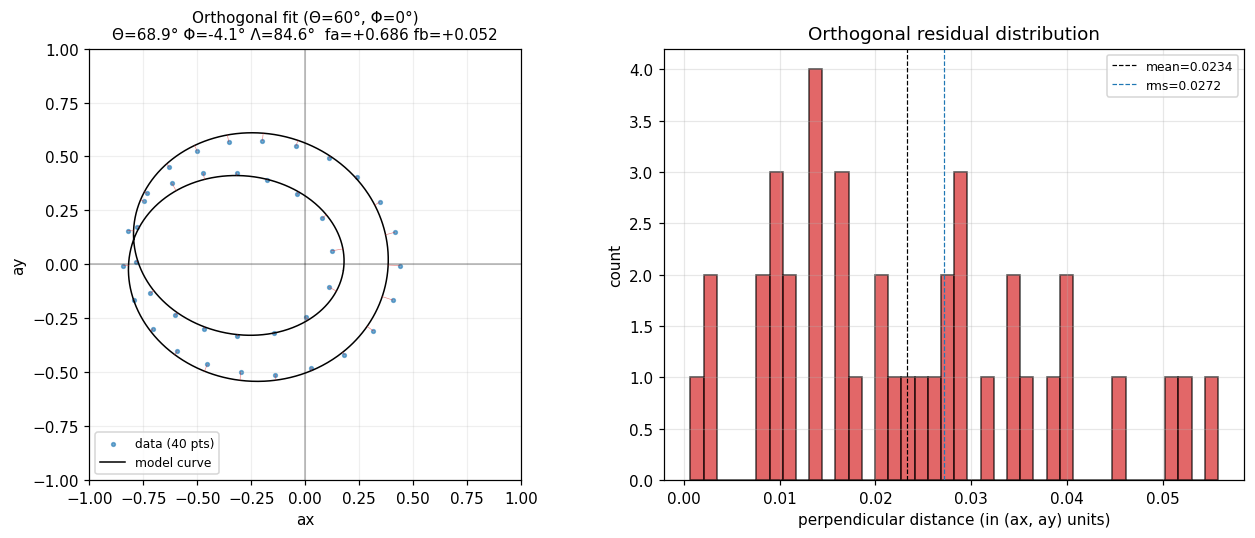

In [60]:
# ── Orthogonal point-to-curve refit (diagnostic) ─────────────────────────────
from scipy.spatial import cKDTree as _cKDTree_diag

_N_MODEL_ORTHO = 1440  # fine model sampling for nearest-neighbour matching


def _ortho_cost(params, cyc_c0, cyc_c90, cyc_c45, cyc_c135, A, B, C):
    Theta_ax, Phi_ax, Lam, dc, fa, fb = params
    da = fa * dc
    db = fb * dc
    b0   = (dc + da) / 2
    b90  = (dc - da) / 2
    b45  = (dc + db) / 2
    b135 = (dc - db) / 2

    c0_a   = cyc_c0   - b0
    c90_a  = cyc_c90  - b90
    c45_a  = cyc_c45  - b45
    c135_a = cyc_c135 - b135

    valid = (c0_a > 0) & (c90_a > 0) & (c45_a > 0) & (c135_a > 0)
    if valid.sum() < 20:
        return 1e6

    ax_d = (c0_a[valid]  - c90_a[valid])  / (c0_a[valid]  + c90_a[valid])
    ay_d = (c45_a[valid] - c135_a[valid]) / (c45_a[valid] + c135_a[valid])

    ax_m, ay_m = fourkas_template(Theta_ax, Phi_ax, Lam, A, B, C, N_model=_N_MODEL_ORTHO)
    if len(ax_m) < 5:
        return 1e6

    tree = _cKDTree_diag(np.column_stack([ax_m, ay_m]))
    d2, _ = tree.query(np.column_stack([ax_d, ay_d]), k=1)
    return float(np.mean(d2 ** 2))


# Build seed set: current Section 9 solution + Θ grid (Φ also varied a bit)
_x_curr = list(shape_fit_res.x)
_seeds = [
    ("Sec9 solution",     _x_curr),
    ("Θ=30°, Φ=0°",       [30.0,   0.0, _x_curr[2], _x_curr[3], 0.0, 0.0]),
    ("Θ=60°, Φ=0°",       [60.0,   0.0, _x_curr[2], _x_curr[3], 0.0, 0.0]),
    ("Θ=45°, Φ=90°",      [45.0,  90.0, _x_curr[2], _x_curr[3], 0.0, 0.0]),
    ("Θ=45°, Φ=-90°",     [45.0, -90.0, _x_curr[2], _x_curr[3], 0.0, 0.0]),
]

print(f"Orthogonal-cost evaluation at Section-9 solution: "
      f"{_ortho_cost(_x_curr, _c0_cyc, _c90_cyc, _c45_cyc, _c135_cyc, A_cal, B_cal, C_cal):.6g}")
print(f"Arc-length cost at Section-9 solution:           {shape_fit_res.fun:.6g}\n")

print(f"{'Seed':<22} {'Θ':>7} {'Φ':>8} {'Λ':>7} {'δc':>9} {'fa':>8} {'fb':>8} {'cost':>11}")
print("-" * 84)

_ortho_results = []
for _label, _x0 in _seeds:
    _res = minimize(
        _ortho_cost,
        _x0,
        args=(_c0_cyc, _c90_cyc, _c45_cyc, _c135_cyc, A_cal, B_cal, C_cal),
        bounds=_bounds_all,
        method="L-BFGS-B",
    )
    _ortho_results.append((_label, _res))
    _Th_o, _Ph_o, _Lm_o, _dc_o, _fa_o, _fb_o = _res.x
    print(f"{_label:<22} {_Th_o:>7.2f} {_Ph_o:>8.2f} {_Lm_o:>7.2f} "
          f"{_dc_o:>9.4f} {_fa_o:>+8.3f} {_fb_o:>+8.3f} {_res.fun:>11.4g}")

# Pick best seed for residual plot
_best_label, _best_res = min(_ortho_results, key=lambda lr: lr[1].fun)
_Th, _Ph, _Lm, _dc, _fa, _fb = _best_res.x
print(f"\nBest orthogonal fit: '{_best_label}'  cost={_best_res.fun:.6g}")
if max(abs(_fa), abs(_fb)) >= 0.999:
    print(f"NOTE: best fit still pegs fa={_fa:+.3f}, fb={_fb:+.3f} at bound \u00b11.")
else:
    print(f"fa={_fa:+.3f}, fb={_fb:+.3f} interior — background bounds are not active.")

# ── Plot: data + best model curve, plus orthogonal-residual histogram ────────
_da = _fa * _dc; _db = _fb * _dc
_b0   = (_dc + _da) / 2;  _b90  = (_dc - _da) / 2
_b45  = (_dc + _db) / 2;  _b135 = (_dc - _db) / 2

_c0_a   = _c0_cyc   - _b0
_c90_a  = _c90_cyc  - _b90
_c45_a  = _c45_cyc  - _b45
_c135_a = _c135_cyc - _b135
_v = (_c0_a > 0) & (_c90_a > 0) & (_c45_a > 0) & (_c135_a > 0)
_ax_d = (_c0_a[_v]  - _c90_a[_v])  / (_c0_a[_v]  + _c90_a[_v])
_ay_d = (_c45_a[_v] - _c135_a[_v]) / (_c45_a[_v] + _c135_a[_v])

_ax_m, _ay_m = fourkas_template(_Th, _Ph, _Lm, A_cal, B_cal, C_cal, N_model=_N_MODEL_ORTHO)
_tree = _cKDTree_diag(np.column_stack([_ax_m, _ay_m]))
_dist, _idx_nn = _tree.query(np.column_stack([_ax_d, _ay_d]), k=1)

_fig_o, _axo = plt.subplots(1, 2, figsize=(12, 5), dpi=110)

_axo[0].scatter(_ax_d, _ay_d, s=6, c="C0", alpha=0.6, label=f"data ({len(_ax_d)} pts)")
_axo[0].plot(_ax_m, _ay_m, "-", lw=1.0, color="k", label="model curve")
# draw a few residual segments
_step = max(1, len(_ax_d) // 80)
for _k in range(0, len(_ax_d), _step):
    _axo[0].plot(
        [_ax_d[_k], _ax_m[_idx_nn[_k]]],
        [_ay_d[_k], _ay_m[_idx_nn[_k]]],
        color="C3", lw=0.4, alpha=0.6,
    )
_axo[0].set_aspect("equal")
_axo[0].set_xlim(-1, 1); _axo[0].set_ylim(-1, 1)
_axo[0].axhline(0, color="k", lw=0.3); _axo[0].axvline(0, color="k", lw=0.3)
_axo[0].set_xlabel("ax"); _axo[0].set_ylabel("ay")
_axo[0].set_title(f"Orthogonal fit ({_best_label})\nΘ={_Th:.1f}° Φ={_Ph:.1f}° Λ={_Lm:.1f}°  fa={_fa:+.3f} fb={_fb:+.3f}",
                   fontsize=10)
_axo[0].grid(alpha=0.2)
_axo[0].legend(fontsize=8, loc="lower left")

_axo[1].hist(_dist, bins=40, color="C3", alpha=0.7, edgecolor="k")
_axo[1].axvline(float(np.mean(_dist)), color="k", ls="--", lw=0.8, label=f"mean={np.mean(_dist):.4f}")
_axo[1].axvline(float(np.sqrt(np.mean(_dist ** 2))), color="C0", ls="--", lw=0.8,
                label=f"rms={np.sqrt(np.mean(_dist ** 2)):.4f}")
_axo[1].set_xlabel("perpendicular distance (in (ax, ay) units)")
_axo[1].set_ylabel("count")
_axo[1].set_title("Orthogonal residual distribution")
_axo[1].grid(alpha=0.3)
_axo[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9d. Alternative shape fit — orthogonal cost on full fit-window data

Replacement for Section 9 that drops two restrictions of the original fit:

1. **No phase-ordering / arc-length matching.** Cost is the mean squared perpendicular distance from each data point to the model curve (KDTree nearest neighbour). No seam, no arc-length parametrisation bias.
2. **Uses the full decimated fit window**, not the 40-point phase-matched ref cycle. Thousands of points anchor the fit and constrain Θ/Φ/Λ much more strongly — especially for the doubled-loop (Θ < Λ) topology where 40 sparse points spread over two branches under-determine the geometry.

Optimisation: differential evolution on the orthogonal cost (global), then L-BFGS-B polish from the DE result and from the existing Section 9 solution; the lower of the two is taken.

Channel correction (`a`, `matcor`) is reused from Section 7 — gain calibration doesn't need phase ordering and is already done.

This is an alternative cell, not a replacement. Compare its outputs (`Theta_axis_fitted_alt`, `..._alt`) with the Section 9 ones before deciding to switch.

Alt fit data: 250,000 points (vs 40 in Section 9)
δc upper bound (alt): 0.5006

Stage 1: differential evolution (maxiter=300, popsize=20) ...
  DE result (2335.3s):  Θ=70.37°  Φ=-5.85°  Λ=85.25°  δc=0.1315  fa=+1.000  fb=-0.040  cost=0.00102422
  Polish from DE result           Θ=70.37°  Φ=-5.85°  Λ=85.25°  δc=0.1315  fa=+1.000  fb=-0.040  cost=0.00102422
  Polish from Section 9 result    Θ=70.51°  Φ=172.76°  Λ=85.27°  δc=0.1287  fa=+1.000  fb=-0.140  cost=0.00103399

Best alternative fit (from DE result):
  Θ_axis = 70.373°
  Φ_axis = -5.848°
  Λ      = 85.255°
  δc     = 0.131461
  fa     = +1.000000
  fb     = -0.040413
  cost   = 0.00102422
  NOTE: fa/fb still pegged — likely upstream issue (T-matrix / gain), not data quantity.


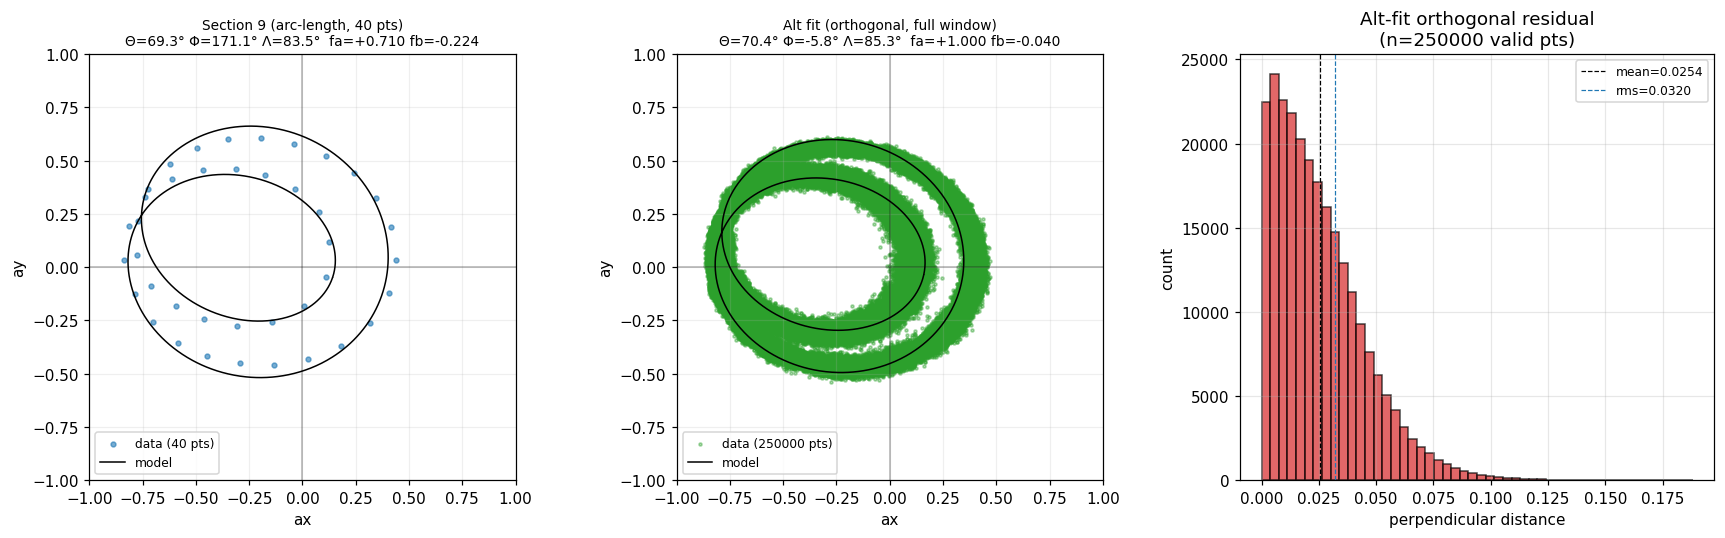


Comparison: Section 9 vs alternative fit
                            Section 9    Alternative
fit points                         40         250000
Θ_axis (deg)                   69.346         70.373
Φ_axis (deg)                  171.086         -5.848
Λ (deg)                        83.468         85.255
δc                             0.1564         0.1315
fa                            +0.7097        +1.0000
fb                            -0.2242        -0.0404


In [61]:
# ── Alternative shape fit: orthogonal cost on full fit-window data ───────────
from scipy.optimize import differential_evolution as _de_alt
from scipy.spatial import cKDTree as _cKDTree_alt

# Optimisation controls (independent of Section 9)
DE_MAXITER_ALT = 300
DE_POPSIZE_ALT = 20
DE_TOL_ALT     = 1e-7
N_MODEL_ALT    = 1440

# ── Rebuild decimated fit-window data and apply gain + T-matrix ──────────────
_c0d_raw   = c0_raw[fit_s:fit_e:dec_correction]
_c90d_raw  = c90_raw[fit_s:fit_e:dec_correction]
_c45d_raw  = c45_raw[fit_s:fit_e:dec_correction]
_c135d_raw = c135_raw[fit_s:fit_e:dec_correction]

_alt_stack = np.vstack((_c90d_raw, _c45d_raw, _c135d_raw, _c0d_raw)).astype(float)
for _i in range(4):
    _alt_stack[_i] = a[_i] * _alt_stack[_i]
_alt_stack = np.dot(matcor, _alt_stack)

_c0_alt   = _alt_stack[_idx_fit[0]]
_c90_alt  = _alt_stack[_idx_fit[1]]
_c45_alt  = _alt_stack[_idx_fit[2]]
_c135_alt = _alt_stack[_idx_fit[3]]
del _alt_stack

print(f"Alt fit data: {len(_c0_alt):,} points (vs {len(_c0_cyc)} in Section 9)")

# ── Orthogonal cost on this data ─────────────────────────────────────────────
def _ortho_cost_alt(params):
    Theta_ax, Phi_ax, Lam, dc, fa, fb = params
    da = fa * dc
    db = fb * dc
    b0   = (dc + da) / 2
    b90  = (dc - da) / 2
    b45  = (dc + db) / 2
    b135 = (dc - db) / 2

    c0_a   = _c0_alt   - b0
    c90_a  = _c90_alt  - b90
    c45_a  = _c45_alt  - b45
    c135_a = _c135_alt - b135

    valid = (c0_a > 0) & (c90_a > 0) & (c45_a > 0) & (c135_a > 0)
    if valid.sum() < 50:
        return 1e6

    ax_d = (c0_a[valid]  - c90_a[valid])  / (c0_a[valid]  + c90_a[valid])
    ay_d = (c45_a[valid] - c135_a[valid]) / (c45_a[valid] + c135_a[valid])

    ax_m, ay_m = fourkas_template(Theta_ax, Phi_ax, Lam, A_cal, B_cal, C_cal, N_model=N_MODEL_ALT)
    if len(ax_m) < 5:
        return 1e6

    tree = _cKDTree_alt(np.column_stack([ax_m, ay_m]))
    d2, _ = tree.query(np.column_stack([ax_d, ay_d]), k=1)
    return float(np.mean(d2 ** 2))


# δc upper bound from the larger pool
_dc_upper_alt = max(0.0, min(float(np.min(_c0_alt) + np.min(_c90_alt)),
                             float(np.min(_c45_alt) + np.min(_c135_alt))))
print(f"δc upper bound (alt): {_dc_upper_alt:.4f}")

_bounds_alt = [
    (0.0, 90.0),     # Θ
    (-180.0, 180.0), # Φ
    (0.0, 90.0),     # Λ
    (0.0, _dc_upper_alt),  # δc
    (-1.0, 1.0),     # fa
    (-1.0, 1.0),     # fb
]

# ── Stage 1: differential evolution (global) ─────────────────────────────────
import time as _time_alt
print(f"\nStage 1: differential evolution (maxiter={DE_MAXITER_ALT}, popsize={DE_POPSIZE_ALT}) ...")
_t0 = _time_alt.perf_counter()
_de_res = _de_alt(
    _ortho_cost_alt,
    bounds=_bounds_alt,
    maxiter=DE_MAXITER_ALT, popsize=DE_POPSIZE_ALT, tol=DE_TOL_ALT,
    seed=42, polish=True, disp=False, workers=1,
)
_t_de = _time_alt.perf_counter() - _t0
_Th_de, _Ph_de, _Lm_de, _dc_de, _fa_de, _fb_de = _de_res.x
print(f"  DE result ({_t_de:.1f}s):  Θ={_Th_de:.2f}°  Φ={_Ph_de:.2f}°  Λ={_Lm_de:.2f}°  "
      f"δc={_dc_de:.4f}  fa={_fa_de:+.3f}  fb={_fb_de:+.3f}  cost={_de_res.fun:.6g}")

# ── Stage 2: L-BFGS-B polish from DE result and from Section 9 result ────────
_polish_seeds = [
    ("DE result",         list(_de_res.x)),
    ("Section 9 result",  list(shape_fit_res.x)),
]
_polish_results = []
for _label, _x0 in _polish_seeds:
    _r = minimize(_ortho_cost_alt, _x0, bounds=_bounds_alt, method="L-BFGS-B")
    _polish_results.append((_label, _r))
    _T, _P, _L, _D, _Fa, _Fb = _r.x
    print(f"  Polish from {_label:<18}  Θ={_T:.2f}°  Φ={_P:.2f}°  Λ={_L:.2f}°  "
          f"δc={_D:.4f}  fa={_Fa:+.3f}  fb={_Fb:+.3f}  cost={_r.fun:.6g}")

_best_label_alt, _best_alt = min(_polish_results, key=lambda lr: lr[1].fun)
shape_fit_res_alt = _best_alt
(Theta_axis_fitted_alt, Phi_axis_fitted_alt, Lambda_fitted_alt,
 dc_fitted_alt, fa_fitted_alt, fb_fitted_alt) = _best_alt.x

print(f"\nBest alternative fit (from {_best_label_alt}):")
print(f"  Θ_axis = {Theta_axis_fitted_alt:.3f}°")
print(f"  Φ_axis = {Phi_axis_fitted_alt:.3f}°")
print(f"  Λ      = {Lambda_fitted_alt:.3f}°")
print(f"  δc     = {dc_fitted_alt:.6f}")
print(f"  fa     = {fa_fitted_alt:+.6f}")
print(f"  fb     = {fb_fitted_alt:+.6f}")
print(f"  cost   = {_best_alt.fun:.6g}")

if max(abs(fa_fitted_alt), abs(fb_fitted_alt)) >= 0.999:
    print(f"  NOTE: fa/fb still pegged — likely upstream issue (T-matrix / gain), not data quantity.")
else:
    print(f"  fa/fb interior — background bounds not active.")

# Derived backgrounds (alt)
da_fitted_alt = fa_fitted_alt * dc_fitted_alt
db_fitted_alt = fb_fitted_alt * dc_fitted_alt
b0_fitted_alt   = (dc_fitted_alt + da_fitted_alt) / 2
b90_fitted_alt  = (dc_fitted_alt - da_fitted_alt) / 2
b45_fitted_alt  = (dc_fitted_alt + db_fitted_alt) / 2
b135_fitted_alt = (dc_fitted_alt - db_fitted_alt) / 2

# ── Side-by-side comparison plot ─────────────────────────────────────────────
def _ax_ay_at(params, c0p, c90p, c45p, c135p):
    Theta_ax, Phi_ax, Lam, dc, fa, fb = params
    da = fa * dc; db = fb * dc
    b0_ = (dc + da) / 2;  b90_ = (dc - da) / 2
    b45_ = (dc + db) / 2; b135_ = (dc - db) / 2
    c0a   = c0p   - b0_
    c90a  = c90p  - b90_
    c45a  = c45p  - b45_
    c135a = c135p - b135_
    v = (c0a > 0) & (c90a > 0) & (c45a > 0) & (c135a > 0)
    ax = (c0a[v]  - c90a[v])  / (c0a[v]  + c90a[v])
    ay = (c45a[v] - c135a[v]) / (c45a[v] + c135a[v])
    axm, aym = fourkas_template(Theta_ax, Phi_ax, Lam, A_cal, B_cal, C_cal, N_model=N_MODEL_ALT)
    return ax, ay, axm, aym


_ax_d_s9, _ay_d_s9, _ax_m_s9, _ay_m_s9 = _ax_ay_at(shape_fit_res.x, _c0_cyc, _c90_cyc, _c45_cyc, _c135_cyc)
_ax_d_alt, _ay_d_alt, _ax_m_alt, _ay_m_alt = _ax_ay_at(_best_alt.x, _c0_alt, _c90_alt, _c45_alt, _c135_alt)

# Orthogonal residuals at alt fit
_tree_alt = _cKDTree_alt(np.column_stack([_ax_m_alt, _ay_m_alt]))
_dist_alt, _ = _tree_alt.query(np.column_stack([_ax_d_alt, _ay_d_alt]), k=1)

_fig_a, _axa = plt.subplots(1, 3, figsize=(16, 5), dpi=110)

_axa[0].scatter(_ax_d_s9, _ay_d_s9, s=10, c="C0", alpha=0.6, label=f"data ({len(_ax_d_s9)} pts)")
_axa[0].plot(_ax_m_s9, _ay_m_s9, "-", lw=1.0, color="k", label="model")
_axa[0].set_aspect("equal"); _axa[0].set_xlim(-1, 1); _axa[0].set_ylim(-1, 1)
_axa[0].axhline(0, color="k", lw=0.3); _axa[0].axvline(0, color="k", lw=0.3)
_axa[0].set_title(
    f"Section 9 (arc-length, {len(_ax_d_s9)} pts)\n"
    f"Θ={shape_fit_res.x[0]:.1f}° Φ={shape_fit_res.x[1]:.1f}° Λ={shape_fit_res.x[2]:.1f}°  "
    f"fa={shape_fit_res.x[4]:+.3f} fb={shape_fit_res.x[5]:+.3f}",
    fontsize=9,
)
_axa[0].set_xlabel("ax"); _axa[0].set_ylabel("ay"); _axa[0].grid(alpha=0.2)
_axa[0].legend(fontsize=8, loc="lower left")

_axa[1].scatter(_ax_d_alt, _ay_d_alt, s=4, c="C2", alpha=0.4, label=f"data ({len(_ax_d_alt)} pts)")
_axa[1].plot(_ax_m_alt, _ay_m_alt, "-", lw=1.0, color="k", label="model")
_axa[1].set_aspect("equal"); _axa[1].set_xlim(-1, 1); _axa[1].set_ylim(-1, 1)
_axa[1].axhline(0, color="k", lw=0.3); _axa[1].axvline(0, color="k", lw=0.3)
_axa[1].set_title(
    f"Alt fit (orthogonal, full window)\n"
    f"Θ={Theta_axis_fitted_alt:.1f}° Φ={Phi_axis_fitted_alt:.1f}° Λ={Lambda_fitted_alt:.1f}°  "
    f"fa={fa_fitted_alt:+.3f} fb={fb_fitted_alt:+.3f}",
    fontsize=9,
)
_axa[1].set_xlabel("ax"); _axa[1].set_ylabel("ay"); _axa[1].grid(alpha=0.2)
_axa[1].legend(fontsize=8, loc="lower left")

_axa[2].hist(_dist_alt, bins=50, color="C3", alpha=0.7, edgecolor="k")
_axa[2].axvline(float(np.mean(_dist_alt)), color="k", ls="--", lw=0.8,
                label=f"mean={np.mean(_dist_alt):.4f}")
_axa[2].axvline(float(np.sqrt(np.mean(_dist_alt ** 2))), color="C0", ls="--", lw=0.8,
                label=f"rms={np.sqrt(np.mean(_dist_alt ** 2)):.4f}")
_axa[2].set_xlabel("perpendicular distance")
_axa[2].set_ylabel("count")
_axa[2].set_title(f"Alt-fit orthogonal residual\n(n={len(_dist_alt)} valid pts)")
_axa[2].grid(alpha=0.3); _axa[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Comparison summary ───────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Comparison: Section 9 vs alternative fit")
print("=" * 70)
print(f"{'':<22} {'Section 9':>14} {'Alternative':>14}")
print(f"{'fit points':<22} {len(_c0_cyc):>14} {len(_c0_alt):>14}")
print(f"{'Θ_axis (deg)':<22} {shape_fit_res.x[0]:>14.3f} {Theta_axis_fitted_alt:>14.3f}")
print(f"{'Φ_axis (deg)':<22} {shape_fit_res.x[1]:>14.3f} {Phi_axis_fitted_alt:>14.3f}")
print(f"{'Λ (deg)':<22} {shape_fit_res.x[2]:>14.3f} {Lambda_fitted_alt:>14.3f}")
print(f"{'δc':<22} {shape_fit_res.x[3]:>14.4f} {dc_fitted_alt:>14.4f}")
print(f"{'fa':<22} {shape_fit_res.x[4]:>+14.4f} {fa_fitted_alt:>+14.4f}")
print(f"{'fb':<22} {shape_fit_res.x[5]:>+14.4f} {fb_fitted_alt:>+14.4f}")

## 9e. Windowed-fit stability diagnostic

Splits the fit window into `N_WINDOWS_DIAG` equal-time chunks and refits each chunk
independently using the **orthogonal cost** from Section 9d, seeded from the alt
fit result (L-BFGS-B only — no DE, so this is fast). The point is to test
whether the rod's geometry is **stable** across the recording or whether it
**drifts**.

**Interpretation:**

- If `Θ`, `Φ`, `Λ` are roughly flat across chunks → the rod is geometrically
  stable; the wide annular spread in the full-window data is just shot-noise on
  individual rotations and the global fit is doing the right thing. `fa`/`fb`
  pegging is then meaningless decoration that you can ignore.
- If `Λ` (or `Θ`) **drifts** monotonically or wobbles across chunks → the rod's
  effective cone half-angle is changing during the recording. A single Fourkas
  fit is then fundamentally biased; segment-wise fits or a time-varying `Λ(t)`
  model would be needed.
- If `fa`/`fb` are interior in some chunks but pegged in others → the optimizer
  is using extreme background to soak up model mismatch in only the bad chunks,
  which is a strong signal that those chunks have different physics.

Tweak `N_WINDOWS_DIAG` for finer/coarser temporal resolution. Runtime is
dominated by KDTree builds; 8 chunks on a 250k-pt window takes a few seconds.

Windowed stability diagnostic: 8 chunks × ~31,250 pts each
------------------------------------------------------------------------------------------------
 # t_mid (s)    n_pts    Θ (°)     Φ (°)    Λ (°)       δc       fa       fb       cost
------------------------------------------------------------------------------------------------
 0     60.06    31250    70.40     -5.82    85.38   0.1368   +0.934   -0.094   0.000804
 1     60.19    31250    70.38     -5.84    85.32   0.1343   +0.981   -0.069   0.001052
 2     60.31    31250    70.41     -5.85    85.16   0.1320   +0.964   +0.001   0.001079
 3     60.44    31250    70.41     -5.85    85.26   0.1386   +0.897   -0.026  0.0009302
 4     60.56    31250    70.54     -5.81    85.31   0.1366   +1.000   -0.046  0.0009998
 5     60.69    31250    69.37     -6.03    84.77   0.1537   +0.736   -0.032   0.001066
 6     60.81    31250    70.16     -5.86    85.27   0.1319   +1.000   -0.039    0.00106
 7     60.94    31250    69.79     -5.87   

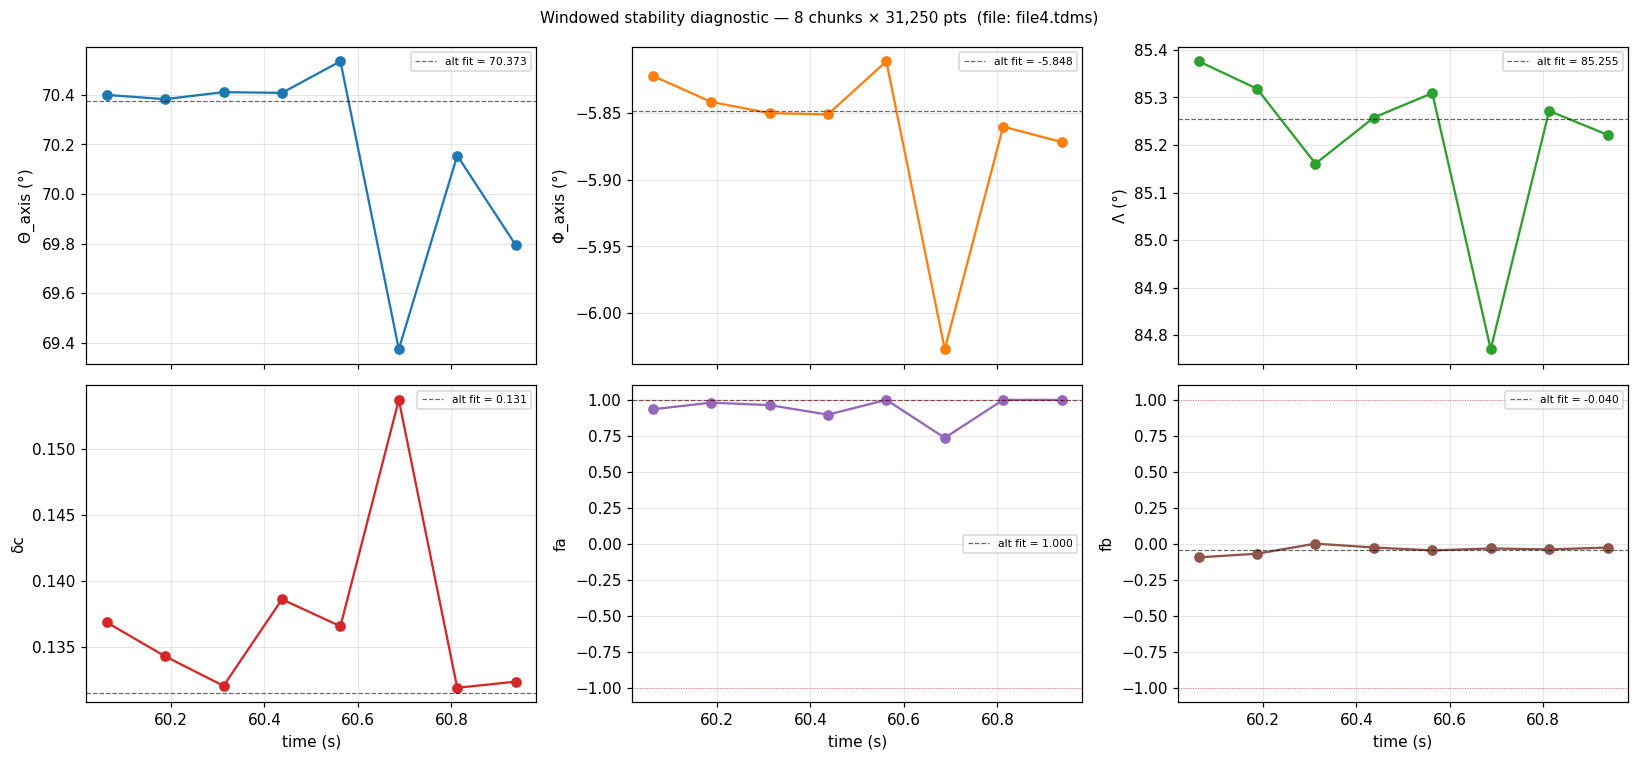

In [62]:
# ── Windowed-fit stability diagnostic ────────────────────────────────────────
# Refits each time chunk independently using L-BFGS-B from the alt fit result
# as the starting point. No DE → fast (a few seconds total).
from scipy.spatial import cKDTree as _cKDTree_win

N_WINDOWS_DIAG = 8        # number of equal-time chunks
N_MODEL_WIN    = 720      # model sampling per chunk fit (smaller → faster)
USE_DC_BOUND_PER_CHUNK = True  # recompute δc upper bound from each chunk

# Time axis aligned with _c0_alt (decimated fit-window)
_t_win = time_s[fit_s:fit_e:dec_correction]
assert len(_t_win) == len(_c0_alt), "time/data length mismatch in 9e"

_n_total = len(_c0_alt)
_chunk_edges = np.linspace(0, _n_total, N_WINDOWS_DIAG + 1, dtype=int)


def _ortho_cost_chunk(params, c0c, c90c, c45c, c135c):
    Theta_ax, Phi_ax, Lam, dc, fa, fb = params
    da = fa * dc; db = fb * dc
    b0   = (dc + da) / 2
    b90  = (dc - da) / 2
    b45  = (dc + db) / 2
    b135 = (dc - db) / 2

    c0_a   = c0c   - b0
    c90_a  = c90c  - b90
    c45_a  = c45c  - b45
    c135_a = c135c - b135

    valid = (c0_a > 0) & (c90_a > 0) & (c45_a > 0) & (c135_a > 0)
    if valid.sum() < 50:
        return 1e6

    ax_d = (c0_a[valid]  - c90_a[valid])  / (c0_a[valid]  + c90_a[valid])
    ay_d = (c45_a[valid] - c135_a[valid]) / (c45_a[valid] + c135_a[valid])

    ax_m, ay_m = fourkas_template(Theta_ax, Phi_ax, Lam, A_cal, B_cal, C_cal,
                                  N_model=N_MODEL_WIN)
    if len(ax_m) < 5:
        return 1e6

    tree = _cKDTree_win(np.column_stack([ax_m, ay_m]))
    d2, _ = tree.query(np.column_stack([ax_d, ay_d]), k=1)
    return float(np.mean(d2 ** 2))


_x0_seed = list(shape_fit_res_alt.x)  # seed from full-window alt fit
_chunk_records = []

print(f"Windowed stability diagnostic: {N_WINDOWS_DIAG} chunks "
      f"× ~{_n_total // N_WINDOWS_DIAG:,} pts each")
print("-" * 96)
print(f"{'#':>2} {'t_mid (s)':>9} {'n_pts':>8} "
      f"{'Θ (°)':>8} {'Φ (°)':>9} {'Λ (°)':>8} "
      f"{'δc':>8} {'fa':>8} {'fb':>8} {'cost':>10}")
print("-" * 96)

import time as _time_win
_t_w0 = _time_win.perf_counter()
for _k in range(N_WINDOWS_DIAG):
    _i0 = _chunk_edges[_k]
    _i1 = _chunk_edges[_k + 1]
    _c0c   = _c0_alt[_i0:_i1]
    _c90c  = _c90_alt[_i0:_i1]
    _c45c  = _c45_alt[_i0:_i1]
    _c135c = _c135_alt[_i0:_i1]
    _t_mid = 0.5 * (_t_win[_i0] + _t_win[_i1 - 1])

    if USE_DC_BOUND_PER_CHUNK:
        _dc_up_c = max(0.0, min(float(np.min(_c0c) + np.min(_c90c)),
                                float(np.min(_c45c) + np.min(_c135c))))
    else:
        _dc_up_c = _bounds_alt[3][1]

    _bounds_c = [
        (0.0, 90.0),
        (-180.0, 180.0),
        (0.0, 90.0),
        (0.0, _dc_up_c),
        (-1.0, 1.0),
        (-1.0, 1.0),
    ]

    # Clamp seed into bounds for safety
    _x0_c = [min(max(_x0_seed[_j], _bounds_c[_j][0]), _bounds_c[_j][1])
             for _j in range(6)]

    _r = minimize(_ortho_cost_chunk, _x0_c,
                  args=(_c0c, _c90c, _c45c, _c135c),
                  bounds=_bounds_c, method="L-BFGS-B")
    _T, _P, _L, _D, _Fa, _Fb = _r.x
    _chunk_records.append({
        "k": _k, "t_mid": _t_mid, "n_pts": len(_c0c),
        "Theta": _T, "Phi": _P, "Lambda": _L,
        "dc": _D, "fa": _Fa, "fb": _Fb, "cost": _r.fun,
    })
    print(f"{_k:>2} {_t_mid:>9.2f} {len(_c0c):>8} "
          f"{_T:>8.2f} {_P:>+9.2f} {_L:>8.2f} "
          f"{_D:>8.4f} {_Fa:>+8.3f} {_Fb:>+8.3f} {_r.fun:>10.4g}")

print("-" * 96)
print(f"Total time: {_time_win.perf_counter() - _t_w0:.1f}s")

# ── Summary stats ────────────────────────────────────────────────────────────
_rec = {k: np.array([r[k] for r in _chunk_records])
        for k in ("t_mid", "Theta", "Phi", "Lambda", "dc", "fa", "fb", "cost")}

print("\nParameter spread across chunks:")
for _name in ("Theta", "Phi", "Lambda", "dc", "fa", "fb"):
    _v = _rec[_name]
    print(f"  {_name:<7}  mean={np.mean(_v):>+9.4f}  std={np.std(_v):>8.4f}  "
          f"min={np.min(_v):>+9.4f}  max={np.max(_v):>+9.4f}  "
          f"range={np.max(_v) - np.min(_v):>8.4f}")

_n_pegged_fa = int(np.sum(np.abs(_rec["fa"]) >= 0.999))
_n_pegged_fb = int(np.sum(np.abs(_rec["fb"]) >= 0.999))
print(f"\n  fa pegged in {_n_pegged_fa}/{N_WINDOWS_DIAG} chunks")
print(f"  fb pegged in {_n_pegged_fb}/{N_WINDOWS_DIAG} chunks")

# ── Plot parameters vs time ──────────────────────────────────────────────────
_fig_w, _axw = plt.subplots(2, 3, figsize=(15, 7), dpi=110, sharex=True)
_axw = _axw.ravel()
_panels = [
    ("Theta",  "Θ_axis (°)",  "C0"),
    ("Phi",    "Φ_axis (°)",  "C1"),
    ("Lambda", "Λ (°)",       "C2"),
    ("dc",     "δc",          "C3"),
    ("fa",     "fa",          "C4"),
    ("fb",     "fb",          "C5"),
]
for _ax_, (_key, _ylab, _col) in zip(_axw, _panels):
    _ax_.plot(_rec["t_mid"], _rec[_key], "o-", color=_col, lw=1.5, ms=6)
    # Reference line: alt fit value (full window)
    _alt_val = {"Theta": Theta_axis_fitted_alt, "Phi": Phi_axis_fitted_alt,
                "Lambda": Lambda_fitted_alt, "dc": dc_fitted_alt,
                "fa": fa_fitted_alt, "fb": fb_fitted_alt}[_key]
    _ax_.axhline(_alt_val, color="k", ls="--", lw=0.8, alpha=0.6,
                 label=f"alt fit = {_alt_val:.3f}")
    if _key in ("fa", "fb"):
        _ax_.axhline(+1, color="r", ls=":", lw=0.6, alpha=0.5)
        _ax_.axhline(-1, color="r", ls=":", lw=0.6, alpha=0.5)
        _ax_.set_ylim(-1.1, 1.1)
    _ax_.set_ylabel(_ylab)
    _ax_.grid(alpha=0.3)
    _ax_.legend(fontsize=7, loc="best")

_axw[3].set_xlabel("time (s)")
_axw[4].set_xlabel("time (s)")
_axw[5].set_xlabel("time (s)")
_fig_w.suptitle(
    f"Windowed stability diagnostic — {N_WINDOWS_DIAG} chunks × "
    f"{_n_total // N_WINDOWS_DIAG:,} pts  (file: {tdms_path.name})",
    fontsize=10,
)
plt.tight_layout()
plt.show()

## 9f. Background-symmetric refit (fa = fb = 0)

Tests whether the bound-pegged `fa` / `fb` from Sections 9 / 9d / 9e are doing
**real work** or just sliding along a parameter degeneracy.

**Theory.** The Fourkas closed loop has only 3 shape parameters (`Θ, Φ, Λ`)
while the background freedom adds 3 more (`dc, fa, fb`). For data that exactly
matches *some* rigid Fourkas loop, certain background shifts are absorbed by
corresponding geometry shifts — the cost surface is nearly flat along that
direction and `fa`/`fb` are unconstrained. When the data doesn't quite match
any rigid loop, the optimizer pushes `fa`/`fb` to whatever extreme reduces the
residual most, and runs into the physical bound `|fa|, |fb| ≤ 1` (which
corresponds to "background can't exceed the DC signal").

**Diagnostic.** Force `fa = fb = 0` (background-symmetric: `b0 = b90 = b45 =
b135 = dc/2`) and refit only the geometry. Compare the cost to the
unconstrained alt fit:

- **Cost ratio close to 1 (≤ 1.5×)** → `fa`/`fb` were just sliding along a
  near-degeneracy. The data shape itself is consistent with a rigid Fourkas
  loop; you can drop `fa`, `fb` from the model.
- **Cost ratio large (≥ 3×)** → `fa`/`fb` were doing real work absorbing
  systematic mismatch between data and model. The mismatch is most likely
  upstream (gain `a`, T-matrix `matcor`, or finite-NA / depolarization effects
  the bare Fourkas A/B/C model doesn't capture).

The plot overlays the symmetric-background model and the unconstrained model on
the same data cloud, so you can **see** the offset that `fa`/`fb` was hiding.

Symmetric-background fit (fa = fb = 0) seeded from alt fit:
  L-BFGS-B from alt seed (12.6s):
    Θ = 59.922°  Φ = -6.760°  Λ = 83.038°  δc = 0.3245  cost = 0.00189282
  L-BFGS-B from Θ=20°, Φ=0°     Θ=21.15°  Φ=-8.90°  Λ=45.23°  δc=0.0000  cost=0.00581728
  L-BFGS-B from Θ=45°, Φ=0°     Θ=21.07°  Φ=-9.10°  Λ=45.16°  δc=0.0000  cost=0.00581682
  L-BFGS-B from Θ=70°, Φ=180°   Θ=59.96°  Φ=+173.02°  Λ=83.05°  δc=0.3239  cost=0.00189244

Best symmetric-bg fit (from Θ=70°, Φ=180°):
  Θ = 59.962°  Φ = 173.021°  Λ = 83.049°  δc = 0.3239  cost = 0.00189244

Cost comparison (orthogonal mean-squared distance):
  unconstrained alt (Sec 9d)           : 0.00102422
  fa = fb = 0 (symmetric background)   : 0.00189244
  ratio (sym / alt)                    : 1.85×
  Δ(Θ)  = -10.411°
  Δ(Φ)  = +178.869°
  Δ(Λ)  = -2.206°
  Δ(δc) = +0.1925

  → Cost ratio 1.8×: fa/fb help moderately. Some real model
    mismatch is being absorbed, but the geometry-only fit is still
    a reasonable approximation.


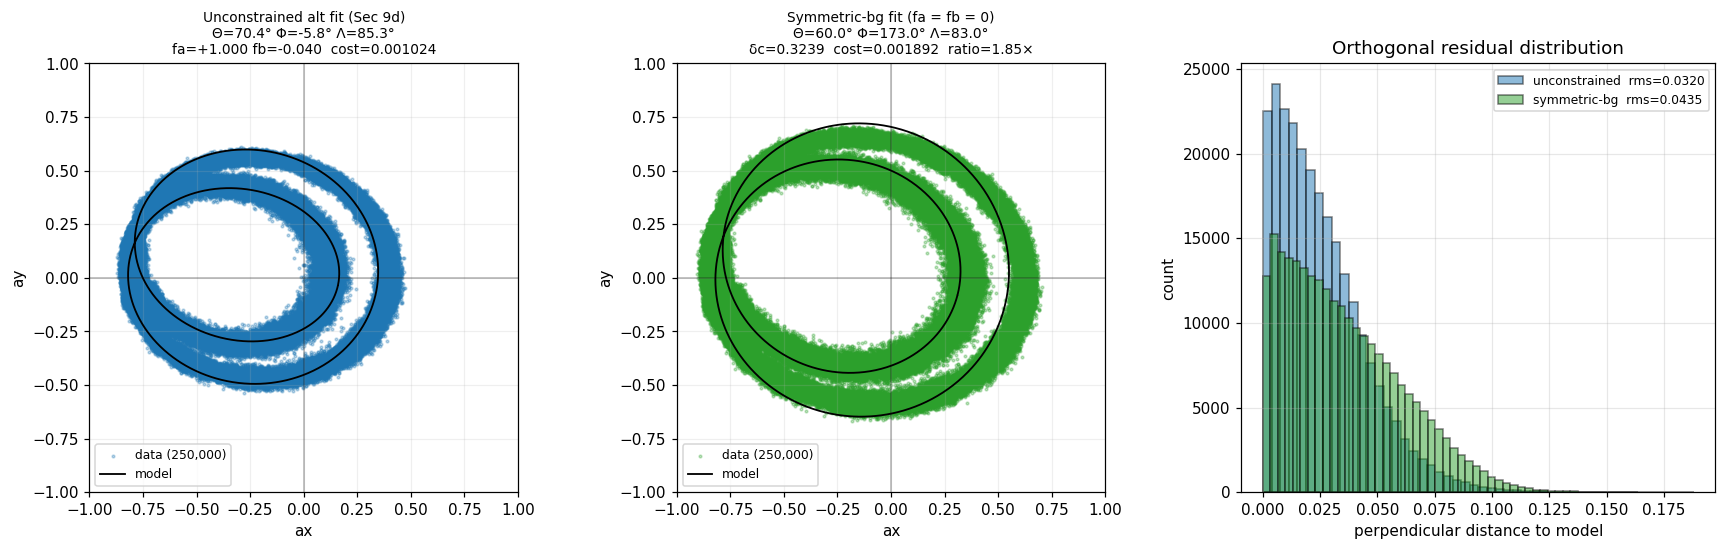

In [63]:
# ── Background-symmetric refit (fa = fb = 0) ─────────────────────────────────
# Holds fa = fb = 0 and refits only (Θ, Φ, Λ, δc) using the orthogonal cost on
# the same full-window decimated data as Section 9d. Compares to unconstrained
# alt fit to test whether fa/fb were doing real work.
from scipy.spatial import cKDTree as _cKDTree_sym

N_MODEL_SYM = 1440


def _ortho_cost_sym(params4):
    Theta_ax, Phi_ax, Lam, dc = params4
    # fa = fb = 0  →  b0 = b90 = b45 = b135 = dc/2
    half = dc / 2

    c0_a   = _c0_alt   - half
    c90_a  = _c90_alt  - half
    c45_a  = _c45_alt  - half
    c135_a = _c135_alt - half

    valid = (c0_a > 0) & (c90_a > 0) & (c45_a > 0) & (c135_a > 0)
    if valid.sum() < 50:
        return 1e6

    ax_d = (c0_a[valid]  - c90_a[valid])  / (c0_a[valid]  + c90_a[valid])
    ay_d = (c45_a[valid] - c135_a[valid]) / (c45_a[valid] + c135_a[valid])

    ax_m, ay_m = fourkas_template(Theta_ax, Phi_ax, Lam, A_cal, B_cal, C_cal,
                                  N_model=N_MODEL_SYM)
    if len(ax_m) < 5:
        return 1e6

    tree = _cKDTree_sym(np.column_stack([ax_m, ay_m]))
    d2, _ = tree.query(np.column_stack([ax_d, ay_d]), k=1)
    return float(np.mean(d2 ** 2))


# δc upper bound from data (same as 9d)
_dc_upper_sym = max(0.0, min(float(np.min(_c0_alt) + np.min(_c90_alt)),
                             float(np.min(_c45_alt) + np.min(_c135_alt))))

_bounds_sym = [
    (0.0, 90.0),     # Θ
    (-180.0, 180.0), # Φ
    (0.0, 90.0),     # Λ
    (0.0, _dc_upper_sym),
]

# Seed from alt fit (drop fa, fb columns)
_x0_sym = [shape_fit_res_alt.x[0], shape_fit_res_alt.x[1],
           shape_fit_res_alt.x[2], shape_fit_res_alt.x[3]]

import time as _time_sym
_t0 = _time_sym.perf_counter()
_sym_res = minimize(_ortho_cost_sym, _x0_sym, bounds=_bounds_sym, method="L-BFGS-B")
_t_sym = _time_sym.perf_counter() - _t0
_T_s, _P_s, _L_s, _D_s = _sym_res.x

print(f"Symmetric-background fit (fa = fb = 0) seeded from alt fit:")
print(f"  L-BFGS-B from alt seed ({_t_sym:.1f}s):")
print(f"    Θ = {_T_s:.3f}°  Φ = {_P_s:.3f}°  Λ = {_L_s:.3f}°  δc = {_D_s:.4f}  cost = {_sym_res.fun:.6g}")

# Try a few extra seeds to check we're not stuck in a poor local minimum
_extra_seeds = [
    ("Θ=20°, Φ=0°",   [20.0,   0.0, 30.0, _D_s]),
    ("Θ=45°, Φ=0°",   [45.0,   0.0, 60.0, _D_s]),
    ("Θ=70°, Φ=180°", [70.0, 180.0, 80.0, _D_s]),
]
_sym_results = [("alt seed", _sym_res)]
for _label, _x0 in _extra_seeds:
    _r = minimize(_ortho_cost_sym, _x0, bounds=_bounds_sym, method="L-BFGS-B")
    _sym_results.append((_label, _r))
    _T, _P, _L, _D = _r.x
    print(f"  L-BFGS-B from {_label:<14}  Θ={_T:.2f}°  Φ={_P:+.2f}°  Λ={_L:.2f}°  "
          f"δc={_D:.4f}  cost={_r.fun:.6g}")

_best_label_sym, _best_sym = min(_sym_results, key=lambda lr: lr[1].fun)
_T_b, _P_b, _L_b, _D_b = _best_sym.x
print(f"\nBest symmetric-bg fit (from {_best_label_sym}):")
print(f"  Θ = {_T_b:.3f}°  Φ = {_P_b:.3f}°  Λ = {_L_b:.3f}°  δc = {_D_b:.4f}  cost = {_best_sym.fun:.6g}")

# ── Cost comparison ──────────────────────────────────────────────────────────
_cost_alt = float(shape_fit_res_alt.fun)
_cost_sym = float(_best_sym.fun)
_ratio = _cost_sym / max(_cost_alt, 1e-12)

print(f"\n{'='*70}")
print("Cost comparison (orthogonal mean-squared distance):")
print(f"{'='*70}")
print(f"  unconstrained alt (Sec 9d)           : {_cost_alt:.6g}")
print(f"  fa = fb = 0 (symmetric background)   : {_cost_sym:.6g}")
print(f"  ratio (sym / alt)                    : {_ratio:.2f}×")
print(f"  Δ(Θ)  = {_T_b - Theta_axis_fitted_alt:+.3f}°")
print(f"  Δ(Φ)  = {_P_b - Phi_axis_fitted_alt:+.3f}°")
print(f"  Δ(Λ)  = {_L_b - Lambda_fitted_alt:+.3f}°")
print(f"  Δ(δc) = {_D_b - dc_fitted_alt:+.4f}")

if _ratio < 1.5:
    print(f"\n  → Cost ratio < 1.5×: fa/fb were sliding along a near-degeneracy.")
    print(f"    The data shape is consistent with a rigid Fourkas loop; the")
    print(f"    background asymmetry adds little. You can effectively drop fa, fb.")
elif _ratio < 3.0:
    print(f"\n  → Cost ratio {_ratio:.1f}×: fa/fb help moderately. Some real model")
    print(f"    mismatch is being absorbed, but the geometry-only fit is still")
    print(f"    a reasonable approximation.")
else:
    print(f"\n  → Cost ratio {_ratio:.1f}×: fa/fb were doing real work. There is")
    print(f"    significant systematic mismatch between data and model that the")
    print(f"    background freedom is absorbing — most likely upstream calibration")
    print(f"    error (gain `a`, T-matrix `matcor`) or finite-NA / depolarization.")

# ── Side-by-side comparison plot ─────────────────────────────────────────────
def _ax_ay_sym(c0p, c90p, c45p, c135p, dc):
    half = dc / 2
    c0a   = c0p   - half
    c90a  = c90p  - half
    c45a  = c45p  - half
    c135a = c135p - half
    v = (c0a > 0) & (c90a > 0) & (c45a > 0) & (c135a > 0)
    return ((c0a[v]  - c90a[v])  / (c0a[v]  + c90a[v]),
            (c45a[v] - c135a[v]) / (c45a[v] + c135a[v]))


_ax_d_sym, _ay_d_sym = _ax_ay_sym(_c0_alt, _c90_alt, _c45_alt, _c135_alt, _D_b)
_ax_m_sym, _ay_m_sym = fourkas_template(_T_b, _P_b, _L_b, A_cal, B_cal, C_cal,
                                         N_model=N_MODEL_SYM)

# Unconstrained alt fit (data + model) for visual comparison
def _ax_ay_full(params, c0p, c90p, c45p, c135p):
    Theta_ax, Phi_ax, Lam, dc, fa, fb = params
    da = fa * dc; db = fb * dc
    b0_ = (dc + da) / 2;  b90_ = (dc - da) / 2
    b45_ = (dc + db) / 2; b135_ = (dc - db) / 2
    c0a   = c0p   - b0_
    c90a  = c90p  - b90_
    c45a  = c45p  - b45_
    c135a = c135p - b135_
    v = (c0a > 0) & (c90a > 0) & (c45a > 0) & (c135a > 0)
    return ((c0a[v]  - c90a[v])  / (c0a[v]  + c90a[v]),
            (c45a[v] - c135a[v]) / (c45a[v] + c135a[v]))


_ax_d_unc, _ay_d_unc = _ax_ay_full(shape_fit_res_alt.x, _c0_alt, _c90_alt, _c45_alt, _c135_alt)
_ax_m_unc, _ay_m_unc = fourkas_template(Theta_axis_fitted_alt, Phi_axis_fitted_alt,
                                         Lambda_fitted_alt, A_cal, B_cal, C_cal,
                                         N_model=N_MODEL_SYM)

# Orthogonal residuals
_tree_unc = _cKDTree_sym(np.column_stack([_ax_m_unc, _ay_m_unc]))
_d_unc, _ = _tree_unc.query(np.column_stack([_ax_d_unc, _ay_d_unc]), k=1)
_tree_sym2 = _cKDTree_sym(np.column_stack([_ax_m_sym, _ay_m_sym]))
_d_sym, _ = _tree_sym2.query(np.column_stack([_ax_d_sym, _ay_d_sym]), k=1)

_fig_f, _axf = plt.subplots(1, 3, figsize=(16, 5), dpi=110)

_axf[0].scatter(_ax_d_unc, _ay_d_unc, s=3, c="C0", alpha=0.3,
                label=f"data ({len(_ax_d_unc):,})")
_axf[0].plot(_ax_m_unc, _ay_m_unc, "-", color="k", lw=1.2, label="model")
_axf[0].set_aspect("equal"); _axf[0].set_xlim(-1, 1); _axf[0].set_ylim(-1, 1)
_axf[0].axhline(0, color="k", lw=0.3); _axf[0].axvline(0, color="k", lw=0.3)
_axf[0].set_title(
    f"Unconstrained alt fit (Sec 9d)\n"
    f"Θ={Theta_axis_fitted_alt:.1f}° Φ={Phi_axis_fitted_alt:.1f}° "
    f"Λ={Lambda_fitted_alt:.1f}°\n"
    f"fa={fa_fitted_alt:+.3f} fb={fb_fitted_alt:+.3f}  cost={_cost_alt:.4g}",
    fontsize=9,
)
_axf[0].set_xlabel("ax"); _axf[0].set_ylabel("ay"); _axf[0].grid(alpha=0.2)
_axf[0].legend(fontsize=8, loc="lower left")

_axf[1].scatter(_ax_d_sym, _ay_d_sym, s=3, c="C2", alpha=0.3,
                label=f"data ({len(_ax_d_sym):,})")
_axf[1].plot(_ax_m_sym, _ay_m_sym, "-", color="k", lw=1.2, label="model")
_axf[1].set_aspect("equal"); _axf[1].set_xlim(-1, 1); _axf[1].set_ylim(-1, 1)
_axf[1].axhline(0, color="k", lw=0.3); _axf[1].axvline(0, color="k", lw=0.3)
_axf[1].set_title(
    f"Symmetric-bg fit (fa = fb = 0)\n"
    f"Θ={_T_b:.1f}° Φ={_P_b:.1f}° Λ={_L_b:.1f}°\n"
    f"δc={_D_b:.4f}  cost={_cost_sym:.4g}  ratio={_ratio:.2f}×",
    fontsize=9,
)
_axf[1].set_xlabel("ax"); _axf[1].set_ylabel("ay"); _axf[1].grid(alpha=0.2)
_axf[1].legend(fontsize=8, loc="lower left")

_axf[2].hist(_d_unc, bins=50, color="C0", alpha=0.5, edgecolor="k",
             label=f"unconstrained  rms={np.sqrt(np.mean(_d_unc**2)):.4f}")
_axf[2].hist(_d_sym, bins=50, color="C2", alpha=0.5, edgecolor="k",
             label=f"symmetric-bg  rms={np.sqrt(np.mean(_d_sym**2)):.4f}")
_axf[2].set_xlabel("perpendicular distance to model")
_axf[2].set_ylabel("count")
_axf[2].set_title("Orthogonal residual distribution")
_axf[2].grid(alpha=0.3); _axf[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9g. Joint gain + geometry + background fit

Drops the assumption that Section 7's gain calibration is correct and lets the
optimizer choose `(a90, a45, a135)` (with `a0 ≡ 1`) **jointly** with the
6 parameters from Section 9d. Total: **9 parameters**.

**Why this matters.** Section 7 calibrates gain by minimising the
instantaneous pair-sum residual `(c0 + c90 − c45 − c135)²` *after* gain and
T-matrix correction. That criterion is bias-free only if the 4-channel optical
matrix `M` perfectly preserves pair-sum (it doesn't — see notes; ~1% systematic)
**and** if the data is bright everywhere along the rotation cycle (it isn't —
shot noise weights the cost toward bright phase angles, which depend on the
unknown geometry). The result is a few-percent geometry-dependent bias in
`a90`, `a45`, `a135`, which propagates downstream as `fa`/`fb` pegging in the
shape fit.

The mentor's saved `_chcor.npy` files across 7 careful calibrations show:

| | a90 | a45 | a135 |
|---|---|---|---|
| range | 0.95–1.04 | 1.16–1.25 | 0.96–1.11 |
| mean ± std | 0.99 ± 0.03 | 1.18 ± 0.03 | 1.04 ± 0.05 |

so the joint-fit answer should land in those rough ranges if the issue is
indeed gain-calibration bias.

**Decimation.** A 9-parameter DE on 250k points would take an hour+. We
decimate to `JOINT_TARGET_PTS` (default 20k) for the search, then
**re-evaluate the cost on the full undecimated data** at the fitted parameters
as a robustness check. If the full-data cost matches the decimated cost (to
within shot-noise expectations), decimation is fine; if it's much worse,
increase `JOINT_TARGET_PTS`.

**Bounds.** Gains in `[0.7, 1.5]` (covers the mentor's range with margin).
Geometry / background bounds match Section 9d. The δc upper bound is set
loose because per-channel min depends on the trial gain.

Joint fit data: full = 250,000 pts, decimated = 20,834 pts (step=12)
δc upper bound (joint, generous): 0.67
Gain bounds: a90 ∈ (0.7, 1.5), a45 ∈ (0.7, 1.5), a135 ∈ (0.7, 1.5)

Stage 1: differential evolution (maxiter=250, popsize=18) ...
  DE result (432.5s):
    Θ=65.18°  Φ=-11.30°  Λ=84.21°  δc=0.2085  fa=+0.094  fb=-0.259
    a90=1.1675  a45=0.7215  a135=0.7000  cost=0.000759043
  Polish from DE result               Θ=65.18°  Λ=84.21°  fa=+0.094 fb=-0.259  a90=1.168 a45=0.721 a135=0.700  cost=0.000759043
  Polish from Sec 9d + Sec 7 gain     Θ=63.67°  Λ=84.01°  fa=+0.119 fb=-0.240  a90=1.121 a45=0.702 a135=0.700  cost=0.000771677

Best joint fit (from DE result):
  Θ      = 65.182°
  Φ      = -11.302°
  Λ      = 84.214°
  δc     = 0.2085
  fa     = +0.0939
  fb     = -0.2591
  a90    = 1.1675
  a45    = 0.7215
  a135   = 0.7000
  cost   = 0.000759043  (decimated, 20,834 pts)

Robustness:
  decimated cost at joint fit  : 0.000759043  (N=20,834)
  full-data cost at joint fit  : 0.0007

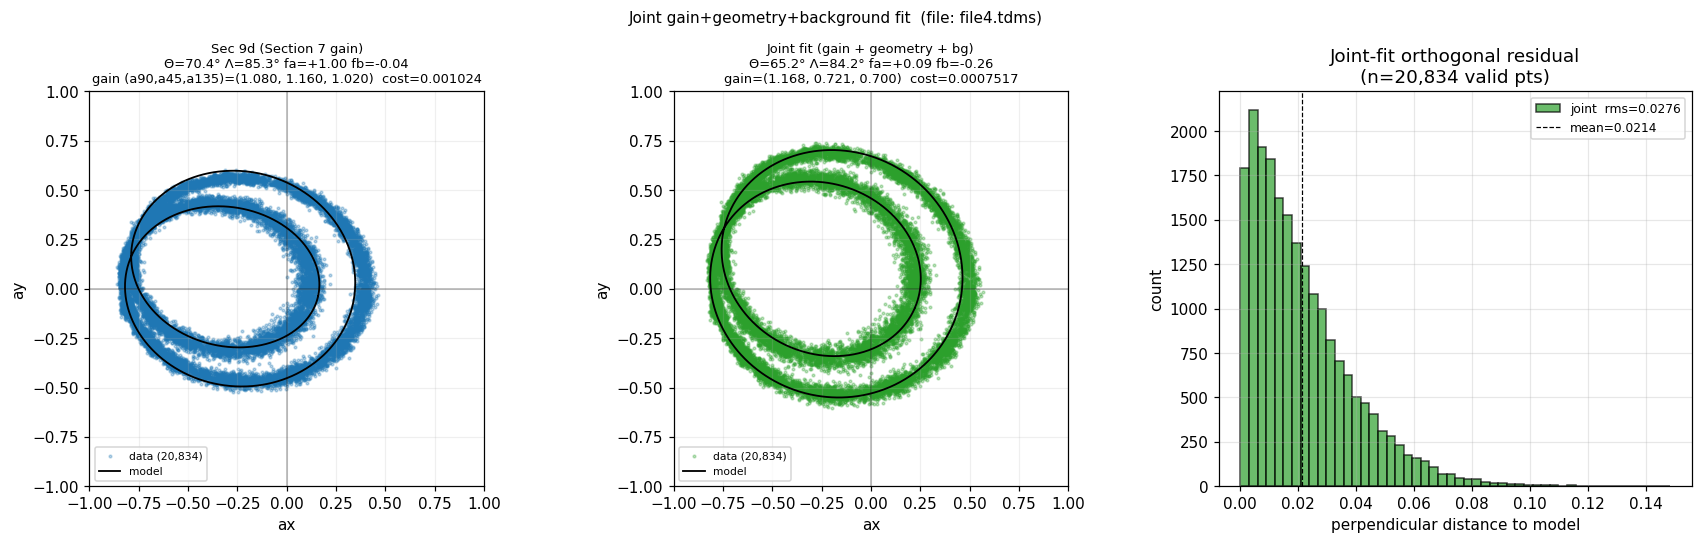

In [64]:
# ── Joint gain + geometry + background fit (9 parameters) ────────────────────
# Parameters: (Θ, Φ, Λ, δc, fa, fb, a90, a45, a135);  a0 ≡ 1.
# Cost: orthogonal point-to-curve, same as 9d, but recomputes
# gain → matcor → background-subtract inside the cost so all 3 layers
# of correction are jointly optimised.
from scipy.optimize import differential_evolution as _de_joint
from scipy.spatial import cKDTree as _cKDTree_joint

# ── Optimisation controls ────────────────────────────────────────────────────
JOINT_TARGET_PTS = 20_000   # decimate full window to ~this many points for the search
DE_MAXITER_JOINT = 250
DE_POPSIZE_JOINT = 18
DE_TOL_JOINT     = 1e-7
N_MODEL_JOINT    = 1440

# Gain bounds bracket mentor's empirical range with margin
A90_BOUNDS  = (0.7, 1.5)
A45_BOUNDS  = (0.7, 1.5)
A135_BOUNDS = (0.7, 1.5)

# ── Build pre-gain raw stack (decimated to target) ───────────────────────────
# Note: _idx_fit was defined in Section 7 as the matcor row → (c0, c90, c45, c135)
# permutation. We reuse it here.
_n_full = len(_c0_alt)
_step_joint = max(1, _n_full // JOINT_TARGET_PTS)
_n_joint = (_n_full + _step_joint - 1) // _step_joint

# Stack rows in the same order as Section 7 / 9d: (c90, c45, c135, c0)
_raw_stack_full = np.vstack((
    c90_raw[fit_s:fit_e:dec_correction],
    c45_raw[fit_s:fit_e:dec_correction],
    c135_raw[fit_s:fit_e:dec_correction],
    c0_raw [fit_s:fit_e:dec_correction],
)).astype(float)

_raw_stack_dec = _raw_stack_full[:, ::_step_joint]

print(f"Joint fit data: full = {_n_full:,} pts, decimated = {_raw_stack_dec.shape[1]:,} pts "
      f"(step={_step_joint})")

# Pre-allocate scratch arrays for the cost function
_scratch_dec  = np.empty_like(_raw_stack_dec)
_scratch_full = None  # built lazily when we run the full-data robustness check


def _ortho_cost_joint(params, raw_stack, scratch):
    """Orthogonal cost with trial gains.  raw_stack rows are (c90, c45, c135, c0)."""
    Theta_ax, Phi_ax, Lam, dc, fa, fb, a90_t, a45_t, a135_t = params

    # Apply trial gain (channel-0 gain fixed at 1.0)
    np.multiply(raw_stack[0], a90_t,  out=scratch[0])
    np.multiply(raw_stack[1], a45_t,  out=scratch[1])
    np.multiply(raw_stack[2], a135_t, out=scratch[2])
    scratch[3] = raw_stack[3]

    # Apply matcor
    corrected = matcor @ scratch  # shape (4, N)

    # Map to (c0, c90, c45, c135)
    c0_v   = corrected[_idx_fit[0]]
    c90_v  = corrected[_idx_fit[1]]
    c45_v  = corrected[_idx_fit[2]]
    c135_v = corrected[_idx_fit[3]]

    # Backgrounds
    da = fa * dc
    db = fb * dc
    b0   = (dc + da) / 2
    b90  = (dc - da) / 2
    b45  = (dc + db) / 2
    b135 = (dc - db) / 2

    c0_a   = c0_v   - b0
    c90_a  = c90_v  - b90
    c45_a  = c45_v  - b45
    c135_a = c135_v - b135

    valid = (c0_a > 0) & (c90_a > 0) & (c45_a > 0) & (c135_a > 0)
    if valid.sum() < 50:
        return 1e6

    ax_d = (c0_a[valid]  - c90_a[valid])  / (c0_a[valid]  + c90_a[valid])
    ay_d = (c45_a[valid] - c135_a[valid]) / (c45_a[valid] + c135_a[valid])

    ax_m, ay_m = fourkas_template(Theta_ax, Phi_ax, Lam, A_cal, B_cal, C_cal,
                                  N_model=N_MODEL_JOINT)
    if len(ax_m) < 5:
        return 1e6

    tree = _cKDTree_joint(np.column_stack([ax_m, ay_m]))
    d2, _ = tree.query(np.column_stack([ax_d, ay_d]), k=1)
    return float(np.mean(d2 ** 2))


# ── Bounds ───────────────────────────────────────────────────────────────────
# δc upper bound: use a generous fixed value (per-channel min depends on gain).
# Pick max possible signal × 0.5 — far above any reasonable background.
_dc_upper_joint = 0.5 * float(np.max(_raw_stack_full))

_bounds_joint = [
    (0.0, 90.0),        # Θ
    (-180.0, 180.0),    # Φ
    (0.0, 90.0),        # Λ
    (0.0, _dc_upper_joint),  # δc
    (-1.0, 1.0),        # fa
    (-1.0, 1.0),        # fb
    A90_BOUNDS,
    A45_BOUNDS,
    A135_BOUNDS,
]

print(f"δc upper bound (joint, generous): {_dc_upper_joint:.2f}")
print(f"Gain bounds: a90 ∈ {A90_BOUNDS}, a45 ∈ {A45_BOUNDS}, a135 ∈ {A135_BOUNDS}")

# ── Stage 1: differential evolution on decimated data ────────────────────────
import time as _time_joint
print(f"\nStage 1: differential evolution "
      f"(maxiter={DE_MAXITER_JOINT}, popsize={DE_POPSIZE_JOINT}) ...")
_t0 = _time_joint.perf_counter()
_de_res_j = _de_joint(
    _ortho_cost_joint,
    bounds=_bounds_joint,
    args=(_raw_stack_dec, _scratch_dec),
    maxiter=DE_MAXITER_JOINT, popsize=DE_POPSIZE_JOINT, tol=DE_TOL_JOINT,
    seed=42, polish=True, disp=False, workers=1,
)
_t_de_j = _time_joint.perf_counter() - _t0
(_Th_j, _Ph_j, _Lm_j, _dc_j, _fa_j, _fb_j,
 _a90_j, _a45_j, _a135_j) = _de_res_j.x
print(f"  DE result ({_t_de_j:.1f}s):")
print(f"    Θ={_Th_j:.2f}°  Φ={_Ph_j:.2f}°  Λ={_Lm_j:.2f}°  δc={_dc_j:.4f}  "
      f"fa={_fa_j:+.3f}  fb={_fb_j:+.3f}")
print(f"    a90={_a90_j:.4f}  a45={_a45_j:.4f}  a135={_a135_j:.4f}  "
      f"cost={_de_res_j.fun:.6g}")

# ── Stage 2: L-BFGS-B polish from DE and from Section 9d alt fit ────────────
_seeds_j = [
    ("DE result", list(_de_res_j.x)),
    ("Sec 9d + Sec 7 gain",
     list(shape_fit_res_alt.x) + [a[0], a[1], a[2]]),  # gain in (a90, a45, a135) order
]
_polish_j = []
for _label, _x0 in _seeds_j:
    _x0c = [min(max(_x0[_k], _bounds_joint[_k][0]), _bounds_joint[_k][1])
            for _k in range(9)]
    _r = minimize(_ortho_cost_joint, _x0c,
                  args=(_raw_stack_dec, _scratch_dec),
                  bounds=_bounds_joint, method="L-BFGS-B")
    _polish_j.append((_label, _r))
    _T, _P, _L, _D, _Fa, _Fb, _A90, _A45, _A135 = _r.x
    print(f"  Polish from {_label:<22}  Θ={_T:.2f}°  Λ={_L:.2f}°  "
          f"fa={_Fa:+.3f} fb={_Fb:+.3f}  "
          f"a90={_A90:.3f} a45={_A45:.3f} a135={_A135:.3f}  "
          f"cost={_r.fun:.6g}")

_best_label_j, _best_j = min(_polish_j, key=lambda lr: lr[1].fun)
shape_fit_res_joint = _best_j
(Theta_axis_joint, Phi_axis_joint, Lambda_joint,
 dc_joint, fa_joint, fb_joint,
 a90_joint, a45_joint, a135_joint) = _best_j.x

print(f"\nBest joint fit (from {_best_label_j}):")
print(f"  Θ      = {Theta_axis_joint:.3f}°")
print(f"  Φ      = {Phi_axis_joint:.3f}°")
print(f"  Λ      = {Lambda_joint:.3f}°")
print(f"  δc     = {dc_joint:.4f}")
print(f"  fa     = {fa_joint:+.4f}")
print(f"  fb     = {fb_joint:+.4f}")
print(f"  a90    = {a90_joint:.4f}")
print(f"  a45    = {a45_joint:.4f}")
print(f"  a135   = {a135_joint:.4f}")
print(f"  cost   = {_best_j.fun:.6g}  (decimated, {_raw_stack_dec.shape[1]:,} pts)")

# Derived backgrounds
da_joint = fa_joint * dc_joint
db_joint = fb_joint * dc_joint
b0_joint   = (dc_joint + da_joint) / 2
b90_joint  = (dc_joint - da_joint) / 2
b45_joint  = (dc_joint + db_joint) / 2
b135_joint = (dc_joint - db_joint) / 2

# ── Robustness check: cost on FULL undecimated data at fitted params ─────────
_scratch_full = np.empty_like(_raw_stack_full)
_cost_full_at_joint = _ortho_cost_joint(_best_j.x, _raw_stack_full, _scratch_full)

# Also re-evaluate on full data at the alt fit (for comparison)
# Note: alt fit was done with Section 7 gain baked in, so we plug Sec 7 gain here.
_alt9_params_full = list(shape_fit_res_alt.x) + [a[0], a[1], a[2]]
_cost_full_at_alt = _ortho_cost_joint(_alt9_params_full, _raw_stack_full, _scratch_full)

print(f"\nRobustness:")
print(f"  decimated cost at joint fit  : {_best_j.fun:.6g}  "
      f"(N={_raw_stack_dec.shape[1]:,})")
print(f"  full-data cost at joint fit  : {_cost_full_at_joint:.6g}  "
      f"(N={_raw_stack_full.shape[1]:,})")
print(f"  full-data cost at alt fit    : {_cost_full_at_alt:.6g}  "
      f"(Sec 9d, Sec 7 gain)")
_full_to_dec_ratio = _cost_full_at_joint / max(_best_j.fun, 1e-12)
if 0.5 < _full_to_dec_ratio < 2.0:
    print(f"  → full/dec cost ratio = {_full_to_dec_ratio:.2f}× — decimation is fine.")
else:
    print(f"  → full/dec cost ratio = {_full_to_dec_ratio:.2f}× — decimation may be "
          f"too aggressive; try increasing JOINT_TARGET_PTS.")

# ── Comparison vs Section 7 gain and mentor's empirical range ────────────────
print(f"\nGain comparison:")
print(f"{'':<8} {'joint':>10} {'Section 7':>10} {'mentor mean':>12} {'mentor range':>16}")
print(f"{'a90':<8} {a90_joint:>10.4f} {a[0]:>10.4f} {0.99:>12.4f} {'0.95 – 1.04':>16}")
print(f"{'a45':<8} {a45_joint:>10.4f} {a[1]:>10.4f} {1.18:>12.4f} {'1.16 – 1.25':>16}")
print(f"{'a135':<8} {a135_joint:>10.4f} {a[2]:>10.4f} {1.04:>12.4f} {'0.96 – 1.11':>16}")

# ── Plot ─────────────────────────────────────────────────────────────────────
def _ax_ay_joint(params9, raw_stack):
    Theta_ax, Phi_ax, Lam, dc, fa, fb, a90_t, a45_t, a135_t = params9
    s = np.empty_like(raw_stack)
    s[0] = a90_t  * raw_stack[0]
    s[1] = a45_t  * raw_stack[1]
    s[2] = a135_t * raw_stack[2]
    s[3] = raw_stack[3]
    cor = matcor @ s
    c0v   = cor[_idx_fit[0]]
    c90v  = cor[_idx_fit[1]]
    c45v  = cor[_idx_fit[2]]
    c135v = cor[_idx_fit[3]]
    da = fa * dc; db = fb * dc
    b0_ = (dc + da) / 2; b90_ = (dc - da) / 2
    b45_ = (dc + db) / 2; b135_ = (dc - db) / 2
    c0a   = c0v   - b0_
    c90a  = c90v  - b90_
    c45a  = c45v  - b45_
    c135a = c135v - b135_
    v = (c0a > 0) & (c90a > 0) & (c45a > 0) & (c135a > 0)
    return ((c0a[v]  - c90a[v])  / (c0a[v]  + c90a[v]),
            (c45a[v] - c135a[v]) / (c45a[v] + c135a[v]))


# Use the decimated-data view for the scatter (full would be too dense to display)
_ax_d_j, _ay_d_j = _ax_ay_joint(_best_j.x, _raw_stack_dec)
_ax_m_j, _ay_m_j = fourkas_template(Theta_axis_joint, Phi_axis_joint, Lambda_joint,
                                     A_cal, B_cal, C_cal, N_model=N_MODEL_JOINT)

# Alt fit for side-by-side
_ax_d_a, _ay_d_a = _ax_ay_joint(_alt9_params_full, _raw_stack_dec)
_ax_m_a, _ay_m_a = fourkas_template(Theta_axis_fitted_alt, Phi_axis_fitted_alt,
                                     Lambda_fitted_alt, A_cal, B_cal, C_cal,
                                     N_model=N_MODEL_JOINT)

# Orthogonal residuals at joint fit
_tree_j = _cKDTree_joint(np.column_stack([_ax_m_j, _ay_m_j]))
_d_j, _ = _tree_j.query(np.column_stack([_ax_d_j, _ay_d_j]), k=1)

_fig_g, _axg = plt.subplots(1, 3, figsize=(16, 5), dpi=110)

_axg[0].scatter(_ax_d_a, _ay_d_a, s=3, c="C0", alpha=0.3,
                label=f"data ({len(_ax_d_a):,})")
_axg[0].plot(_ax_m_a, _ay_m_a, "-", color="k", lw=1.2, label="model")
_axg[0].set_aspect("equal"); _axg[0].set_xlim(-1, 1); _axg[0].set_ylim(-1, 1)
_axg[0].axhline(0, color="k", lw=0.3); _axg[0].axvline(0, color="k", lw=0.3)
_axg[0].set_title(
    f"Sec 9d (Section 7 gain)\n"
    f"Θ={Theta_axis_fitted_alt:.1f}° Λ={Lambda_fitted_alt:.1f}° "
    f"fa={fa_fitted_alt:+.2f} fb={fb_fitted_alt:+.2f}\n"
    f"gain (a90,a45,a135)=({a[0]:.3f}, {a[1]:.3f}, {a[2]:.3f})  "
    f"cost={_cost_full_at_alt:.4g}",
    fontsize=8.5,
)
_axg[0].set_xlabel("ax"); _axg[0].set_ylabel("ay"); _axg[0].grid(alpha=0.2)
_axg[0].legend(fontsize=7, loc="lower left")

_axg[1].scatter(_ax_d_j, _ay_d_j, s=3, c="C2", alpha=0.3,
                label=f"data ({len(_ax_d_j):,})")
_axg[1].plot(_ax_m_j, _ay_m_j, "-", color="k", lw=1.2, label="model")
_axg[1].set_aspect("equal"); _axg[1].set_xlim(-1, 1); _axg[1].set_ylim(-1, 1)
_axg[1].axhline(0, color="k", lw=0.3); _axg[1].axvline(0, color="k", lw=0.3)
_axg[1].set_title(
    f"Joint fit (gain + geometry + bg)\n"
    f"Θ={Theta_axis_joint:.1f}° Λ={Lambda_joint:.1f}° "
    f"fa={fa_joint:+.2f} fb={fb_joint:+.2f}\n"
    f"gain=({a90_joint:.3f}, {a45_joint:.3f}, {a135_joint:.3f})  "
    f"cost={_cost_full_at_joint:.4g}",
    fontsize=8.5,
)
_axg[1].set_xlabel("ax"); _axg[1].set_ylabel("ay"); _axg[1].grid(alpha=0.2)
_axg[1].legend(fontsize=7, loc="lower left")

_axg[2].hist(_d_j, bins=50, color="C2", alpha=0.7, edgecolor="k",
             label=f"joint  rms={np.sqrt(np.mean(_d_j**2)):.4f}")
_axg[2].axvline(float(np.mean(_d_j)), color="k", ls="--", lw=0.8,
                label=f"mean={np.mean(_d_j):.4f}")
_axg[2].set_xlabel("perpendicular distance to model")
_axg[2].set_ylabel("count")
_axg[2].set_title(f"Joint-fit orthogonal residual\n(n={len(_d_j):,} valid pts)")
_axg[2].grid(alpha=0.3); _axg[2].legend(fontsize=8)

_fig_g.suptitle(f"Joint gain+geometry+background fit  (file: {tdms_path.name})",
                fontsize=10)
plt.tight_layout()
plt.show()

## 9h. Phase-matched (index-by-index) joint fit

Same 9-parameter joint fit as 9g, but with a **phase-matched** cost instead of
nearest-neighbor. Both data and model are arc-length-resampled to `N_REF_PHASE`
points, anchored at their respective leftmost (min ax) point, and the cost is
the index-by-index squared distance:

$$ \text{cost} = \frac{1}{N}\sum_{i=0}^{N-1}\bigl[(a_x^{\text{data}}[i] - a_x^{\text{model}}[i])^2
                                            + (a_y^{\text{data}}[i] - a_y^{\text{model}}[i])^2\bigr] $$

The minimum is taken over forward / reversed model orientation.

**Source of the data cycle.** We use the per-stop-angle merged samples
`c0_fit, c90_fit, c45_fit, c135_fit` (built in Section 6b — `N_SUBSAMPLE = 40`
phase-ordered points, raw / pre-gain). Each cost evaluation re-applies the
trial gain → T-matrix → background, recomputes (ax, ay) for the 40 merged
points, then arc-length-resamples to `N_REF_PHASE`.

**Caveats — read these.**

1. **Information ceiling = `N_SUBSAMPLE`.** Resampling 40 cycle points to 90
   smooths but does not add information. To genuinely refine the cycle you
   must rerun Section 6 with a larger `N_SUBSAMPLE` (e.g. 90 or 180). The
   "use raw data directly and assign phase per point" approach is essentially
   what the orthogonal cost in 9g already does — index-matched cost is *less*
   informative per-point but produces a smoother cost landscape and
   phase-vs-residual plots that diagnose gain bias more cleanly.

2. **Phase-matched cost does NOT break the gain × geometry degeneracy.** Gain
   dilation reshapes the (ax, ay) cloud, which moves the leftmost point in
   arc-length and re-anchors phase 0. The optimizer can still trade gain
   against geometry by sliding the cloud. The proper cure is an external
   isotropic reference cycle that pins gain independently. This cell is
   primarily diagnostic and as a sanity check that 9g's pathology is not an
   artefact of the orthogonal-cost geometry.

3. **Index-mismatch fix.** Previous Section 9 sampled the model at the *data's*
   irregular arc-length fractions. This cell resamples both data and model to
   the same uniform arc-length grid independently, then anchors each at its
   own leftmost — a cleaner, symmetric formulation.

Phase-matched fit: cycle source = 40 pts (Section 6b N_SUBSAMPLE), target = 90 arc-length points
δc upper bound: 0.62

Stage 1: differential evolution (maxiter=250, popsize=18) ...
  DE done (10.7s)  cost=0.00207494
  Polish from DE result               Θ=7.03° Λ=32.41° fa=-0.902 fb=+0.920  a=(0.849,0.810,0.700)  cost=0.00207494
  Polish from Sec 9d + Sec 7 gain     Θ=62.64° Λ=82.97° fa=+0.202 fb=-0.038  a=(1.065,0.757,0.701)  cost=0.000785842
  Polish from Sec 9g (orth-joint)     Θ=65.27° Λ=83.56° fa=-0.054 fb=-0.374  a=(1.232,0.700,0.720)  cost=0.000512697

Best phase-matched fit (from Sec 9g (orth-joint)):
  Θ      = 65.266°
  Φ      = -11.375°
  Λ      = 83.564°
  δc     = 0.2021
  fa     = -0.0536
  fb     = -0.3742
  a90    = 1.2316
  a45    = 0.7003
  a135   = 0.7200
  cost   = 0.000512697  (N_REF_PHASE=90)

Gain comparison:
              phase   9g joint  Section 7     mentor
a90          1.2316     1.1675     1.0800     0.9900
a45          0.7003     0.7215     1.1600     1.18

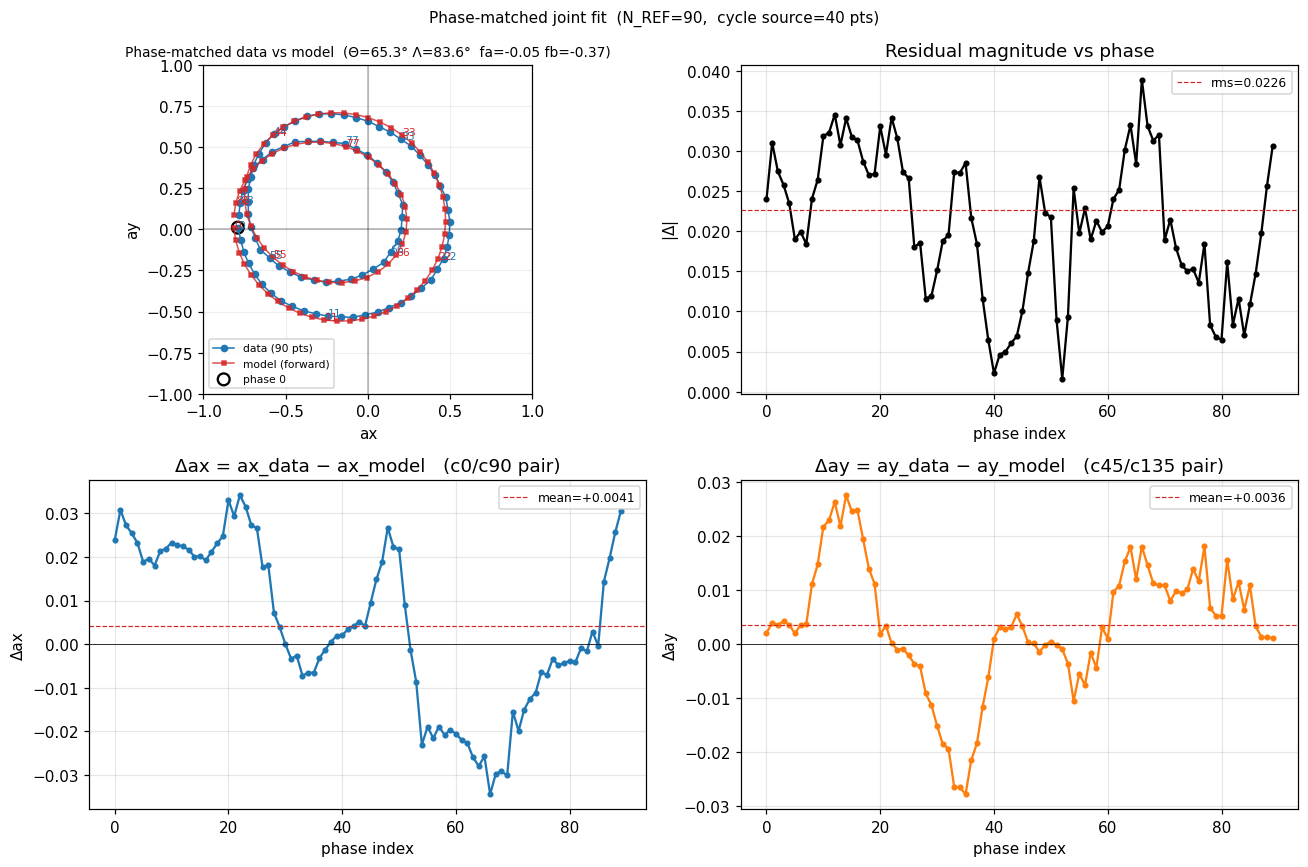

In [65]:
# ── Phase-matched joint fit (9 params, index-by-index cost) ──────────────────
from scipy.optimize import differential_evolution as _de_phase

# ── Optimisation controls ────────────────────────────────────────────────────
N_REF_PHASE   = 90       # number of arc-length-evenly spaced phase points
N_MODEL_PHASE = 720      # dense model sampling before resample
DE_MAXITER_H  = 250
DE_POPSIZE_H  = 18
DE_TOL_H      = 1e-7

# Pre-stack merged-cycle channel values in matcor's row order: (c90, c45, c135, c0).
_cyc_stack_h = np.vstack((c90_fit, c45_fit, c135_fit, c0_fit)).astype(float)
_n_cyc_h = _cyc_stack_h.shape[1]
print(f"Phase-matched fit: cycle source = {_n_cyc_h} pts (Section 6b N_SUBSAMPLE),"
      f" target = {N_REF_PHASE} arc-length points")


def _resample_closed_leftmost(ax, ay, n_out):
    """Arc-length resample of a closed polyline to n_out evenly-spaced points,
    rolled so that index 0 is the leftmost (min ax) sample."""
    # Close the loop
    axc = np.concatenate([ax, ax[:1]])
    ayc = np.concatenate([ay, ay[:1]])
    seg = np.hypot(np.diff(axc), np.diff(ayc))
    s = np.concatenate(([0.0], np.cumsum(seg)))
    L = float(s[-1])
    if not np.isfinite(L) or L < 1e-9:
        return None, None
    t = np.linspace(0.0, L, n_out, endpoint=False)
    rx = np.interp(t, s, axc)
    ry = np.interp(t, s, ayc)
    k = int(np.argmin(rx))
    return np.roll(rx, -k), np.roll(ry, -k)


def _phase_cost(params, cyc_stack, n_ref, n_model):
    Th, Ph, Lm, dc, fa, fb, a90_t, a45_t, a135_t = params

    # Apply trial gain + matcor
    s = np.empty_like(cyc_stack)
    s[0] = a90_t  * cyc_stack[0]
    s[1] = a45_t  * cyc_stack[1]
    s[2] = a135_t * cyc_stack[2]
    s[3] = cyc_stack[3]
    cor = matcor @ s

    c0v   = cor[_idx_fit[0]]
    c90v  = cor[_idx_fit[1]]
    c45v  = cor[_idx_fit[2]]
    c135v = cor[_idx_fit[3]]

    da = fa * dc
    db = fb * dc
    b0_  = (dc + da) / 2
    b90_ = (dc - da) / 2
    b45_ = (dc + db) / 2
    b135_ = (dc - db) / 2

    c0a   = c0v   - b0_
    c90a  = c90v  - b90_
    c45a  = c45v  - b45_
    c135a = c135v - b135_

    valid = (c0a > 0) & (c90a > 0) & (c45a > 0) & (c135a > 0)
    if valid.sum() < 8:
        return 1e6
    ax_d = (c0a[valid]  - c90a[valid])  / (c0a[valid]  + c90a[valid])
    ay_d = (c45a[valid] - c135a[valid]) / (c45a[valid] + c135a[valid])

    rx_d, ry_d = _resample_closed_leftmost(ax_d, ay_d, n_ref)
    if rx_d is None:
        return 1e6

    ax_m, ay_m = fourkas_template(Th, Ph, Lm, A_cal, B_cal, C_cal, N_model=n_model)
    if len(ax_m) < 5:
        return 1e6

    rx_mF, ry_mF = _resample_closed_leftmost(ax_m, ay_m, n_ref)
    rx_mR, ry_mR = _resample_closed_leftmost(ax_m[::-1], ay_m[::-1], n_ref)

    cF = (np.mean((rx_d - rx_mF) ** 2 + (ry_d - ry_mF) ** 2)
          if rx_mF is not None else 1e6)
    cR = (np.mean((rx_d - rx_mR) ** 2 + (ry_d - ry_mR) ** 2)
          if rx_mR is not None else 1e6)
    return float(min(cF, cR))


# ── Bounds (same shape as 9g) ────────────────────────────────────────────────
_dc_upper_h = 0.5 * float(np.max(_cyc_stack_h))
_bounds_h = [
    (0.0, 90.0),                    # Θ
    (-180.0, 180.0),                # Φ
    (0.0, 90.0),                    # Λ
    (0.0, _dc_upper_h),             # δc
    (-1.0, 1.0),                    # fa
    (-1.0, 1.0),                    # fb
    A90_BOUNDS,
    A45_BOUNDS,
    A135_BOUNDS,
]
print(f"δc upper bound: {_dc_upper_h:.2f}")

# ── Stage 1: differential evolution ──────────────────────────────────────────
import time as _time_h
print(f"\nStage 1: differential evolution "
      f"(maxiter={DE_MAXITER_H}, popsize={DE_POPSIZE_H}) ...")
_t0_h = _time_h.perf_counter()
_de_h_res = _de_phase(
    _phase_cost, bounds=_bounds_h,
    args=(_cyc_stack_h, N_REF_PHASE, N_MODEL_PHASE),
    maxiter=DE_MAXITER_H, popsize=DE_POPSIZE_H, tol=DE_TOL_H,
    seed=42, polish=True, disp=False, workers=1,
)
_t_h = _time_h.perf_counter() - _t0_h
print(f"  DE done ({_t_h:.1f}s)  cost={_de_h_res.fun:.6g}")

# ── Stage 2: polish from DE and from Sec 9d alt fit + Sec 7 gain ─────────────
_seeds_h = [
    ("DE result", list(_de_h_res.x)),
    ("Sec 9d + Sec 7 gain", list(shape_fit_res_alt.x) + [a[0], a[1], a[2]]),
    ("Sec 9g (orth-joint)",
     [Theta_axis_joint, Phi_axis_joint, Lambda_joint, dc_joint,
      fa_joint, fb_joint, a90_joint, a45_joint, a135_joint]),
]
_polish_h = []
for _label, _x0 in _seeds_h:
    _x0c = [min(max(_x0[k], _bounds_h[k][0]), _bounds_h[k][1]) for k in range(9)]
    _r = minimize(_phase_cost, _x0c,
                  args=(_cyc_stack_h, N_REF_PHASE, N_MODEL_PHASE),
                  bounds=_bounds_h, method="L-BFGS-B")
    _polish_h.append((_label, _r))
    T, P, L, D, Fa, Fb, A90, A45, A135 = _r.x
    print(f"  Polish from {_label:<22}  Θ={T:.2f}° Λ={L:.2f}° "
          f"fa={Fa:+.3f} fb={Fb:+.3f}  "
          f"a=({A90:.3f},{A45:.3f},{A135:.3f})  cost={_r.fun:.6g}")

_best_label_h, _best_h = min(_polish_h, key=lambda lr: lr[1].fun)
shape_fit_res_phase = _best_h
(Theta_axis_phase, Phi_axis_phase, Lambda_phase,
 dc_phase, fa_phase, fb_phase,
 a90_phase, a45_phase, a135_phase) = _best_h.x

print(f"\nBest phase-matched fit (from {_best_label_h}):")
print(f"  Θ      = {Theta_axis_phase:.3f}°")
print(f"  Φ      = {Phi_axis_phase:.3f}°")
print(f"  Λ      = {Lambda_phase:.3f}°")
print(f"  δc     = {dc_phase:.4f}")
print(f"  fa     = {fa_phase:+.4f}")
print(f"  fb     = {fb_phase:+.4f}")
print(f"  a90    = {a90_phase:.4f}")
print(f"  a45    = {a45_phase:.4f}")
print(f"  a135   = {a135_phase:.4f}")
print(f"  cost   = {_best_h.fun:.6g}  (N_REF_PHASE={N_REF_PHASE})")

# Derived backgrounds
da_phase = fa_phase * dc_phase
db_phase = fb_phase * dc_phase
b0_phase   = (dc_phase + da_phase) / 2
b90_phase  = (dc_phase - da_phase) / 2
b45_phase  = (dc_phase + db_phase) / 2
b135_phase = (dc_phase - db_phase) / 2

# ── Comparison print ─────────────────────────────────────────────────────────
print(f"\nGain comparison:")
print(f"{'':<8} {'phase':>10} {'9g joint':>10} {'Section 7':>10} {'mentor':>10}")
print(f"{'a90':<8} {a90_phase:>10.4f} {a90_joint:>10.4f} {a[0]:>10.4f} {0.99:>10.4f}")
print(f"{'a45':<8} {a45_phase:>10.4f} {a45_joint:>10.4f} {a[1]:>10.4f} {1.18:>10.4f}")
print(f"{'a135':<8} {a135_phase:>10.4f} {a135_joint:>10.4f} {a[2]:>10.4f} {1.04:>10.4f}")

print(f"\nGeometry comparison:")
print(f"{'':<8} {'phase':>10} {'9g joint':>10} {'9d alt':>10}")
print(f"{'Θ':<8} {Theta_axis_phase:>10.3f} {Theta_axis_joint:>10.3f} "
      f"{Theta_axis_fitted_alt:>10.3f}")
print(f"{'Φ':<8} {Phi_axis_phase:>10.3f} {Phi_axis_joint:>10.3f} "
      f"{Phi_axis_fitted_alt:>10.3f}")
print(f"{'Λ':<8} {Lambda_phase:>10.3f} {Lambda_joint:>10.3f} "
      f"{Lambda_fitted_alt:>10.3f}")

# ── Plot: data ref cycle, model ref cycle, residual vs phase ────────────────
def _data_ref_cycle(params9, cyc_stack, n_ref):
    Th, Ph, Lm, dc, fa, fb, a90_t, a45_t, a135_t = params9
    s = np.empty_like(cyc_stack)
    s[0] = a90_t * cyc_stack[0]; s[1] = a45_t * cyc_stack[1]
    s[2] = a135_t * cyc_stack[2]; s[3] = cyc_stack[3]
    cor = matcor @ s
    c0v = cor[_idx_fit[0]]; c90v = cor[_idx_fit[1]]
    c45v = cor[_idx_fit[2]]; c135v = cor[_idx_fit[3]]
    da = fa * dc; db = fb * dc
    c0a   = c0v   - (dc + da) / 2
    c90a  = c90v  - (dc - da) / 2
    c45a  = c45v  - (dc + db) / 2
    c135a = c135v - (dc - db) / 2
    v = (c0a > 0) & (c90a > 0) & (c45a > 0) & (c135a > 0)
    axd = (c0a[v]  - c90a[v])  / (c0a[v]  + c90a[v])
    ayd = (c45a[v] - c135a[v]) / (c45a[v] + c135a[v])
    return _resample_closed_leftmost(axd, ayd, n_ref)


_rx_d_h, _ry_d_h = _data_ref_cycle(_best_h.x, _cyc_stack_h, N_REF_PHASE)
_axm_h, _aym_h = fourkas_template(Theta_axis_phase, Phi_axis_phase, Lambda_phase,
                                   A_cal, B_cal, C_cal, N_model=N_MODEL_PHASE)
_rx_mF_h, _ry_mF_h = _resample_closed_leftmost(_axm_h, _aym_h, N_REF_PHASE)
_rx_mR_h, _ry_mR_h = _resample_closed_leftmost(_axm_h[::-1], _aym_h[::-1], N_REF_PHASE)
_cF_h = np.mean((_rx_d_h - _rx_mF_h) ** 2 + (_ry_d_h - _ry_mF_h) ** 2)
_cR_h = np.mean((_rx_d_h - _rx_mR_h) ** 2 + (_ry_d_h - _ry_mR_h) ** 2)
if _cF_h <= _cR_h:
    _rx_m_h, _ry_m_h, _orient_h = _rx_mF_h, _ry_mF_h, "forward"
else:
    _rx_m_h, _ry_m_h, _orient_h = _rx_mR_h, _ry_mR_h, "reversed"

_phase_idx = np.arange(N_REF_PHASE)
_dxh = _rx_d_h - _rx_m_h
_dyh = _ry_d_h - _ry_m_h

_fig_h, _axh = plt.subplots(2, 2, figsize=(12, 8), dpi=110)

# (0,0) — both cycles in (ax, ay) with index labels at a few points
_axh[0, 0].plot(_rx_d_h, _ry_d_h, 'o-', ms=4, lw=1.0, color='C0',
                label=f'data ({N_REF_PHASE} pts)')
_axh[0, 0].plot(_rx_m_h, _ry_m_h, 's-', ms=3, lw=1.0, color='C3', alpha=0.8,
                label=f'model ({_orient_h})')
for _k in range(0, N_REF_PHASE, max(1, N_REF_PHASE // 8)):
    _axh[0, 0].annotate(str(_k), (_rx_d_h[_k], _ry_d_h[_k]), fontsize=7, color='C0')
    _axh[0, 0].annotate(str(_k), (_rx_m_h[_k], _ry_m_h[_k]), fontsize=7, color='C3')
_axh[0, 0].scatter(_rx_d_h[0], _ry_d_h[0], s=60, facecolors='none',
                   edgecolors='k', lw=1.5, label='phase 0')
_axh[0, 0].set_aspect('equal')
_axh[0, 0].set_xlim(-1, 1); _axh[0, 0].set_ylim(-1, 1)
_axh[0, 0].axhline(0, color='k', lw=0.3); _axh[0, 0].axvline(0, color='k', lw=0.3)
_axh[0, 0].set_xlabel('ax'); _axh[0, 0].set_ylabel('ay')
_axh[0, 0].set_title(f'Phase-matched data vs model  (Θ={Theta_axis_phase:.1f}° '
                     f'Λ={Lambda_phase:.1f}°  fa={fa_phase:+.2f} fb={fb_phase:+.2f})',
                     fontsize=9)
_axh[0, 0].legend(fontsize=7, loc='lower left'); _axh[0, 0].grid(alpha=0.2)

# (0,1) — index-by-index residual magnitude vs phase index
_axh[0, 1].plot(_phase_idx, np.hypot(_dxh, _dyh), 'o-', ms=3, color='k')
_axh[0, 1].axhline(np.sqrt(np.mean(_dxh ** 2 + _dyh ** 2)), color='C3',
                   ls='--', lw=0.8,
                   label=f'rms={np.sqrt(np.mean(_dxh**2+_dyh**2)):.4f}')
_axh[0, 1].set_xlabel('phase index')
_axh[0, 1].set_ylabel(r'$|\Delta|$')
_axh[0, 1].set_title('Residual magnitude vs phase')
_axh[0, 1].grid(alpha=0.3); _axh[0, 1].legend(fontsize=8)

# (1,0) — Δax vs phase
_axh[1, 0].plot(_phase_idx, _dxh, 'o-', ms=3, color='C0')
_axh[1, 0].axhline(0, color='k', lw=0.5)
_axh[1, 0].axhline(np.mean(_dxh), color='C3', ls='--', lw=0.8,
                   label=f'mean={np.mean(_dxh):+.4f}')
_axh[1, 0].set_xlabel('phase index'); _axh[1, 0].set_ylabel('Δax')
_axh[1, 0].set_title('Δax = ax_data − ax_model   (c0/c90 pair)')
_axh[1, 0].grid(alpha=0.3); _axh[1, 0].legend(fontsize=8)

# (1,1) — Δay vs phase
_axh[1, 1].plot(_phase_idx, _dyh, 'o-', ms=3, color='C1')
_axh[1, 1].axhline(0, color='k', lw=0.5)
_axh[1, 1].axhline(np.mean(_dyh), color='C3', ls='--', lw=0.8,
                   label=f'mean={np.mean(_dyh):+.4f}')
_axh[1, 1].set_xlabel('phase index'); _axh[1, 1].set_ylabel('Δay')
_axh[1, 1].set_title('Δay = ay_data − ay_model   (c45/c135 pair)')
_axh[1, 1].grid(alpha=0.3); _axh[1, 1].legend(fontsize=8)

_fig_h.suptitle(f'Phase-matched joint fit  (N_REF={N_REF_PHASE},  '
                f'cycle source={_n_cyc_h} pts)',
                fontsize=10)
plt.tight_layout()
plt.show()

## 9i. I_sum diagnostic — two independent estimates of $\sin^2\Theta$

Mentor's idea, formalized. Sum the four channels (Fourkas, after gain / T-matrix /
background correction):

$$ \Sigma_k I_k \;=\; 4\,I_{\text{rod}}(\Theta)\,(A + B\sin^2\Theta) $$

(The angle-modulated $\cos[2(\Phi - \varphi_k)]$ terms sum to zero across the four
orthogonal analysers $\varphi_k\in\{0,45,90,135\}^\circ$, so $\Phi$ drops out.)

Modeling the rod's intrinsic emission/scattering as

$$ I_{\text{rod}}(\Theta) \;=\; K_1 + K_2 \sin^2\Theta $$

gives a one-parameter-family-of-Θ prediction at every phase, **independent** of
$\Phi$ and **independent** of the anisotropy.

We now have two estimates of $\sin^2\Theta(\psi)$ at every phase index:

| source | formula | sees |
|---|---|---|
| anisotropy | $\sin^2\Theta_a = \dfrac{A r}{C - B r}$ , $r = \sqrt{a_x^2 + a_y^2}$ | (Φ-Θ) coupled |
| total intensity | $\Sigma_k I_k = 4(K_1 + K_2 \sin^2\Theta)(A + B\sin^2\Theta)$ | Θ-only |

If gain and background are correct, the two should agree along the cycle.
Disagreement is a residual sensitive to gain × background **with a different
weighting** than the anisotropy residual — so it can in principle break the
gain × background degeneracy that single-rod anisotropy fitting suffers from.

**This cell only diagnoses, it does not refit.** Steps:

1. Use the 9h fit parameters (best geometry so far). Apply gain → matcor →
   background, get corrected channel time series, resample to `N_REF_PHASE` arc-length
   points anchored at leftmost.
2. From the model curve at the same fit parameters, compute the geometry-derived
   $\sin^2\Theta_{\text{model}}(\psi)$ trajectory.
3. Linear-regress the data $\Sigma_k I_k$ against the model trajectory:
   $$ \Sigma_k I_k \;\approx\; \alpha_0 + \alpha_1 \sin^2\Theta + \alpha_2 \sin^4\Theta $$
   The 3 coefficients map to $(K_1, K_2)$ via $\alpha_0 = 4 K_1 A$, $\alpha_2 = 4 K_2 B$,
   $\alpha_1 = 4(K_1 B + K_2 A)$. The $K_1 + K_2 \sin^2\Theta$ ansatz is consistent
   only if $\alpha_1 = (B/A)\alpha_0 + (A/B)\alpha_2$. We report this consistency
   check directly.
4. Plot: $\sin^2\Theta_{\text{aniso}}$ vs $\sin^2\Theta_{\text{model}}$ overlay,
   $\Sigma I$ data vs polynomial prediction, residual vs phase, and the implied
   $I_{\text{rod}}(\Theta)$ curve.

**Caveat about Θ ↔ π−Θ.** Both $\sin^2\Theta$ and the proposed $I_{\text{rod}}$ are
symmetric around $\Theta = \pi/2$, so this diagnostic still cannot distinguish a
rod tilted up vs down by the same angle. Breaking that ambiguity would require an
asymmetric term in $I_{\text{rod}}$ (e.g. defocus / depth-of-field weighting), which
is beyond this cell.

Valid points after correction: 40 / 40
Model orientation chosen: forward

3-parameter polynomial fit (free α0, α1, α2):
  α0 = +1.02385   α1 = +2.24386   α2 = -1.34702
  rms residual = 0.13882  (I_sum range = 0.90417)
  Implied K1 = +0.99474    K2 = -0.51700
  Consistency: α1_fit=+2.24386, α1_predicted (from K1+K2 ansatz)=+2.05964
               relative deviation = +0.082  (close to 0 → K1+K2·sin²Θ ansatz holds)
  → ansatz looks consistent; can refit with 2 params (K1, K2) directly.

2-parameter physical fit  I_rod = K1 + K2·sin²Θ:
  K1 = +1.01579   K2 = -0.48533    K2/K1 = -0.478
  rms residual = 0.13894  (vs free-poly rms = 0.13882)

sin²Θ disagreement (data anisotropy vs model geometry):
  mean   = -0.0168
  std    = 0.0367
  rms    = 0.0404
  range of sin²Θ_model = [0.099, 0.998]


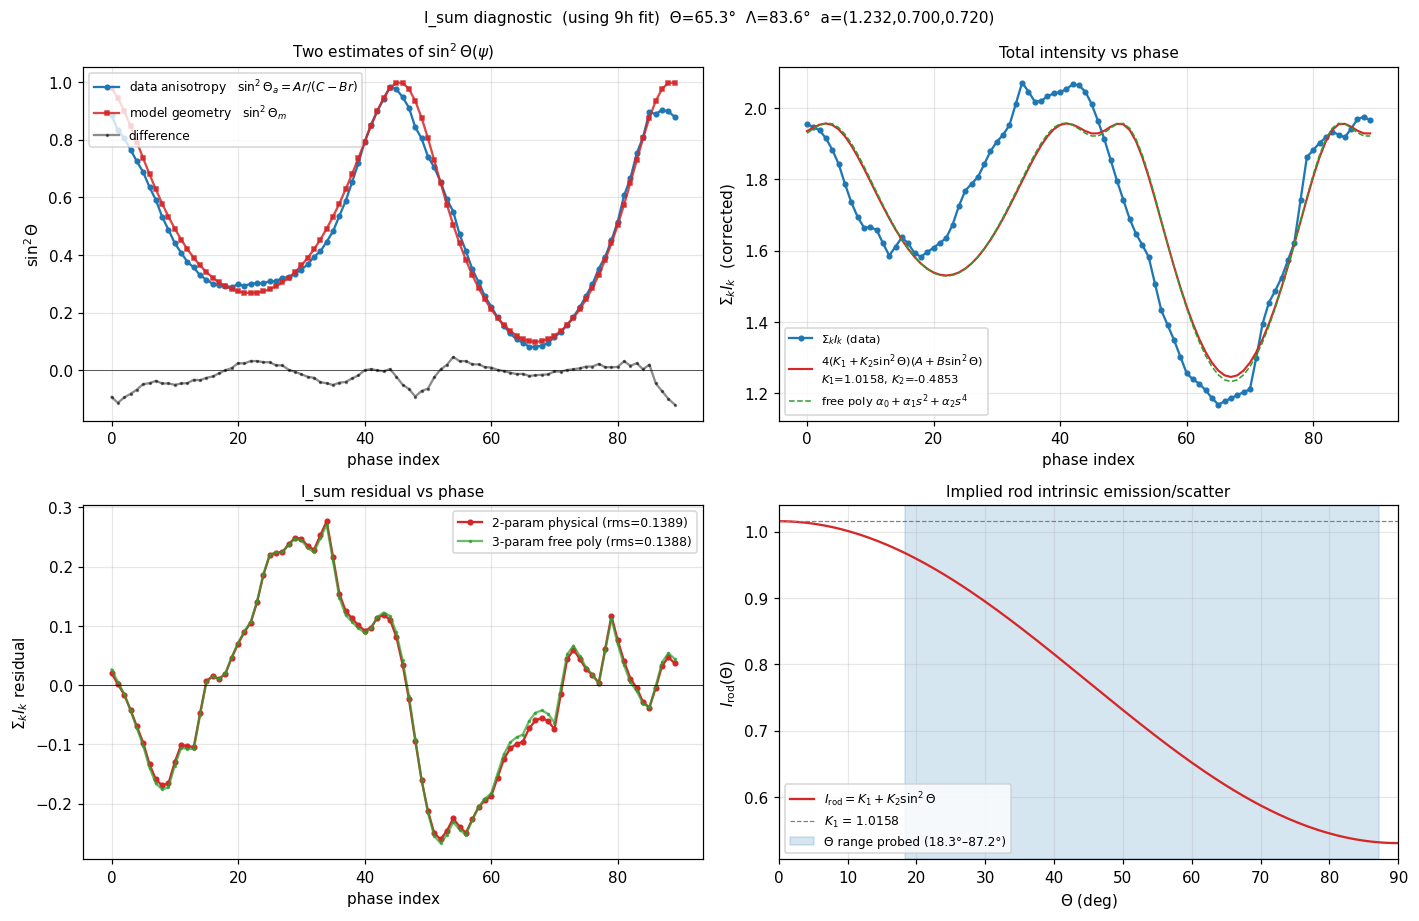


── Quick A/B: same geometry, alternate gain/bg ─────────────────────
config                               rms_resid  I_sum_range      K2/K1
9h (phase fit)                         0.13894      0.90417     -0.478  (rms/range = 0.154)
Sec 7 gain, fa=fb=0, dc=dc_phase       0.18683      1.09376     -0.495  (rms/range = 0.171)
Sec 7 gain, no bg (dc=0)               0.18366      1.08375     -0.521  (rms/range = 0.169)
9h gain, fa=fb=0                       0.13921      0.90433     -0.478  (rms/range = 0.154)


In [66]:
# ── I_sum diagnostic ─────────────────────────────────────────────────────────
# Compares (a) sin²Θ derived from the anisotropy radius r=√(ax²+ay²) and
#          (b) the geometry-derived sin²Θ trajectory from the cone model,
# then fits the rod's intrinsic intensity model I_rod = K1 + K2·sin²Θ to the
# observed total intensity Σ_k I_k = 4·I_rod·(A + B·sin²Θ).

# Resamples a single closed cycle of (ax, ay) plus a co-traveling intensity
# trace `Itot` to N points evenly in arc-length, anchored at min ax.
def _resample_with_extra(ax, ay, extra, n_out):
    axc = np.concatenate([ax, ax[:1]])
    ayc = np.concatenate([ay, ay[:1]])
    exc = np.concatenate([extra, extra[:1]])
    seg = np.hypot(np.diff(axc), np.diff(ayc))
    s = np.concatenate(([0.0], np.cumsum(seg)))
    L = float(s[-1])
    if not np.isfinite(L) or L < 1e-9:
        return None, None, None
    t = np.linspace(0.0, L, n_out, endpoint=False)
    rx = np.interp(t, s, axc)
    ry = np.interp(t, s, ayc)
    re = np.interp(t, s, exc)
    k = int(np.argmin(rx))
    return np.roll(rx, -k), np.roll(ry, -k), np.roll(re, -k)


# ── Apply 9h's fit to the merged-cycle channels (raw → corrected) ────────────
_g_diag = (a90_phase, a45_phase, a135_phase)            # gains from 9h
_dc_diag, _fa_diag, _fb_diag = dc_phase, fa_phase, fb_phase
_geom_diag = (Theta_axis_phase, Phi_axis_phase, Lambda_phase)

_stack_d = np.vstack((c90_fit, c45_fit, c135_fit, c0_fit)).astype(float)
_stack_d = _stack_d.copy()
_stack_d[0] *= _g_diag[0]
_stack_d[1] *= _g_diag[1]
_stack_d[2] *= _g_diag[2]
_cor_d = matcor @ _stack_d
_c0_corr   = _cor_d[_idx_fit[0]]
_c90_corr  = _cor_d[_idx_fit[1]]
_c45_corr  = _cor_d[_idx_fit[2]]
_c135_corr = _cor_d[_idx_fit[3]]

_da_diag = _fa_diag * _dc_diag
_db_diag = _fb_diag * _dc_diag
_b0d   = (_dc_diag + _da_diag) / 2
_b90d  = (_dc_diag - _da_diag) / 2
_b45d  = (_dc_diag + _db_diag) / 2
_b135d = (_dc_diag - _db_diag) / 2

_c0_a   = _c0_corr   - _b0d
_c90_a  = _c90_corr  - _b90d
_c45_a  = _c45_corr  - _b45d
_c135_a = _c135_corr - _b135d

_valid_diag = (_c0_a > 0) & (_c90_a > 0) & (_c45_a > 0) & (_c135_a > 0)
print(f"Valid points after correction: {int(_valid_diag.sum())} / {_c0_a.size}")
if _valid_diag.sum() < 8:
    raise RuntimeError("Too few valid points for I_sum diagnostic.")

_ax_d = (_c0_a[_valid_diag]  - _c90_a[_valid_diag])  / (_c0_a[_valid_diag]  + _c90_a[_valid_diag])
_ay_d = (_c45_a[_valid_diag] - _c135_a[_valid_diag]) / (_c45_a[_valid_diag] + _c135_a[_valid_diag])
_Isum_d = _c0_a[_valid_diag] + _c90_a[_valid_diag] + _c45_a[_valid_diag] + _c135_a[_valid_diag]

# Resample data onto N_REF_PHASE uniform arc-length grid (carry I_sum along)
_rx_d, _ry_d, _Isum_d_rs = _resample_with_extra(_ax_d, _ay_d, _Isum_d, N_REF_PHASE)

# Anisotropy-derived sin²Θ from data
_r_d = np.hypot(_rx_d, _ry_d)
_denom_d = (C_cal - B_cal * _r_d)
_s2_aniso_d = np.where(_denom_d > 1e-9, A_cal * _r_d / np.maximum(_denom_d, 1e-9), np.nan)

# ── Build geometry-derived sin²Θ(ψ) from the model at fit (Θ, Φ, Λ) ─────────
_axm_diag, _aym_diag = fourkas_template(*_geom_diag, A_cal, B_cal, C_cal,
                                         N_model=N_MODEL_PHASE)
_r_m_dense = np.hypot(_axm_diag, _aym_diag)
_denom_m = (C_cal - B_cal * _r_m_dense)
_s2_model_dense = np.where(_denom_m > 1e-9,
                           A_cal * _r_m_dense / np.maximum(_denom_m, 1e-9), np.nan)

# Resample the dense model curve (and its sin²Θ trace) onto the same N_REF_PHASE grid.
# Pick orientation (forward / reversed) by minimum nearest-pair distance to data.
def _resample_model_with_s2(ax, ay, s2, n_out):
    axc = np.concatenate([ax, ax[:1]])
    ayc = np.concatenate([ay, ay[:1]])
    s2c = np.concatenate([s2, s2[:1]])
    seg = np.hypot(np.diff(axc), np.diff(ayc))
    s = np.concatenate(([0.0], np.cumsum(seg)))
    L = float(s[-1])
    t = np.linspace(0.0, L, n_out, endpoint=False)
    rx = np.interp(t, s, axc)
    ry = np.interp(t, s, ayc)
    rs2 = np.interp(t, s, s2c)
    k = int(np.argmin(rx))
    return np.roll(rx, -k), np.roll(ry, -k), np.roll(rs2, -k)


_rx_mF, _ry_mF, _s2_mF = _resample_model_with_s2(_axm_diag, _aym_diag,
                                                  _s2_model_dense, N_REF_PHASE)
_rx_mR, _ry_mR, _s2_mR = _resample_model_with_s2(_axm_diag[::-1], _aym_diag[::-1],
                                                  _s2_model_dense[::-1], N_REF_PHASE)
_cF = np.mean((_rx_d - _rx_mF) ** 2 + (_ry_d - _ry_mF) ** 2)
_cR = np.mean((_rx_d - _rx_mR) ** 2 + (_ry_d - _ry_mR) ** 2)
if _cF <= _cR:
    _rx_m, _ry_m, _s2_model = _rx_mF, _ry_mF, _s2_mF
    _orient_diag = "forward"
else:
    _rx_m, _ry_m, _s2_model = _rx_mR, _ry_mR, _s2_mR
    _orient_diag = "reversed"
print(f"Model orientation chosen: {_orient_diag}")

# ── Linear regression: I_sum = α0 + α1·sin²Θ + α2·sin⁴Θ ─────────────────────
_X = np.column_stack([np.ones(N_REF_PHASE), _s2_model, _s2_model ** 2])
_alpha, _resid_lstsq, _rank, _ = np.linalg.lstsq(_X, _Isum_d_rs, rcond=None)
_a0_p, _a1_p, _a2_p = _alpha
_Isum_pred = _X @ _alpha
_resid = _Isum_d_rs - _Isum_pred

print(f"\n3-parameter polynomial fit (free α0, α1, α2):")
print(f"  α0 = {_a0_p:+.5f}   α1 = {_a1_p:+.5f}   α2 = {_a2_p:+.5f}")
print(f"  rms residual = {np.sqrt(np.mean(_resid ** 2)):.5f}  "
      f"(I_sum range = {np.ptp(_Isum_d_rs):.5f})")

# Implied (K1, K2) via α0 = 4·K1·A, α2 = 4·K2·B
_K1_imp = _a0_p / (4 * A_cal)
_K2_imp = _a2_p / (4 * B_cal)
# Consistency check: α1 should equal α0·B/A + α2·A/B
_a1_pred = _a0_p * (B_cal / A_cal) + _a2_p * (A_cal / B_cal)
_consistency = (_a1_p - _a1_pred) / max(abs(_a1_p), abs(_a1_pred), 1e-9)
print(f"  Implied K1 = {_K1_imp:+.5f}    K2 = {_K2_imp:+.5f}")
print(f"  Consistency: α1_fit={_a1_p:+.5f}, α1_predicted (from K1+K2 ansatz)={_a1_pred:+.5f}")
print(f"               relative deviation = {_consistency:+.3f}  "
      f"(close to 0 → K1+K2·sin²Θ ansatz holds)")
if abs(_consistency) > 0.10:
    print("  → ansatz I_rod = K1 + K2·sin²Θ is NOT well-supported by I_sum trace.")
else:
    print("  → ansatz looks consistent; can refit with 2 params (K1, K2) directly.")

# ── 2-parameter constrained fit:  I_sum = 4(K1 + K2·s²)(A + B·s²)  ──────────
# Linear in K1, K2:  I_sum = 4·A·K1 + 4·B·s²·K1 + 4·A·s²·K2 + 4·B·s⁴·K2
#                  = K1·[4A + 4B·s²] + K2·[4A·s² + 4B·s⁴]
_X2 = np.column_stack([4 * (A_cal + B_cal * _s2_model),
                       4 * _s2_model * (A_cal + B_cal * _s2_model)])
_K12, _, _, _ = np.linalg.lstsq(_X2, _Isum_d_rs, rcond=None)
_K1_fit, _K2_fit = float(_K12[0]), float(_K12[1])
_Isum_pred_K = _X2 @ _K12
_resid_K = _Isum_d_rs - _Isum_pred_K
print(f"\n2-parameter physical fit  I_rod = K1 + K2·sin²Θ:")
print(f"  K1 = {_K1_fit:+.5f}   K2 = {_K2_fit:+.5f}    K2/K1 = {_K2_fit/_K1_fit if _K1_fit != 0 else float('nan'):+.3f}")
print(f"  rms residual = {np.sqrt(np.mean(_resid_K ** 2)):.5f}  "
      f"(vs free-poly rms = {np.sqrt(np.mean(_resid ** 2)):.5f})")

# ── Disagreement metric: sin²Θ_aniso vs sin²Θ_model ─────────────────────────
_s2_diff = _s2_aniso_d - _s2_model
print(f"\nsin²Θ disagreement (data anisotropy vs model geometry):")
print(f"  mean   = {np.mean(_s2_diff):+.4f}")
print(f"  std    = {np.std(_s2_diff):.4f}")
print(f"  rms    = {np.sqrt(np.mean(_s2_diff ** 2)):.4f}")
print(f"  range of sin²Θ_model = [{np.nanmin(_s2_model):.3f}, {np.nanmax(_s2_model):.3f}]")

# ── Plot ─────────────────────────────────────────────────────────────────────
_phase_idx = np.arange(N_REF_PHASE)
_fig_i, _axi = plt.subplots(2, 2, figsize=(13, 8.5), dpi=110)

# (0,0) sin²Θ traces vs phase
_axi[0, 0].plot(_phase_idx, _s2_aniso_d, 'o-', ms=3, color='C0',
                label=r'data anisotropy   $\sin^2\Theta_a = Ar/(C-Br)$')
_axi[0, 0].plot(_phase_idx, _s2_model, 's-', ms=3, color='C3', alpha=0.85,
                label=r'model geometry   $\sin^2\Theta_m$')
_axi[0, 0].plot(_phase_idx, _s2_diff, '.-', ms=2.5, color='k', alpha=0.45,
                label='difference')
_axi[0, 0].axhline(0, color='k', lw=0.4)
_axi[0, 0].set_xlabel('phase index')
_axi[0, 0].set_ylabel(r'$\sin^2\Theta$')
_axi[0, 0].set_title(r'Two estimates of $\sin^2\Theta(\psi)$', fontsize=10)
_axi[0, 0].legend(fontsize=8); _axi[0, 0].grid(alpha=0.3)

# (0,1) I_sum vs phase, data and predicted
_axi[0, 1].plot(_phase_idx, _Isum_d_rs, 'o-', ms=3, color='C0',
                label=r'$\Sigma_k I_k$ (data)')
_axi[0, 1].plot(_phase_idx, _Isum_pred_K, '-', lw=1.4, color='C3',
                label=fr'$4(K_1 + K_2\sin^2\Theta)(A+B\sin^2\Theta)$' "\n"
                      fr'$K_1$={_K1_fit:.4f}, $K_2$={_K2_fit:.4f}')
_axi[0, 1].plot(_phase_idx, _Isum_pred, '--', lw=1.0, color='C2',
                label=fr'free poly $\alpha_0+\alpha_1 s^2+\alpha_2 s^4$')
_axi[0, 1].set_xlabel('phase index')
_axi[0, 1].set_ylabel(r'$\Sigma_k I_k$  (corrected)')
_axi[0, 1].set_title('Total intensity vs phase', fontsize=10)
_axi[0, 1].legend(fontsize=7.5); _axi[0, 1].grid(alpha=0.3)

# (1,0) Residual of I_sum fit
_axi[1, 0].plot(_phase_idx, _resid_K, 'o-', ms=3, color='C3',
                label=fr'2-param physical (rms={np.sqrt(np.mean(_resid_K**2)):.4f})')
_axi[1, 0].plot(_phase_idx, _resid, '.-', ms=2.5, color='C2', alpha=0.7,
                label=fr'3-param free poly (rms={np.sqrt(np.mean(_resid**2)):.4f})')
_axi[1, 0].axhline(0, color='k', lw=0.5)
_axi[1, 0].set_xlabel('phase index')
_axi[1, 0].set_ylabel(r'$\Sigma_k I_k$ residual')
_axi[1, 0].set_title('I_sum residual vs phase', fontsize=10)
_axi[1, 0].legend(fontsize=8); _axi[1, 0].grid(alpha=0.3)

# (1,1) implied I_rod(Θ) curve
_th_grid = np.linspace(0, np.pi / 2, 200)
_s2_grid = np.sin(_th_grid) ** 2
_Irod_2par = _K1_fit + _K2_fit * _s2_grid
_axi[1, 1].plot(np.degrees(_th_grid), _Irod_2par, '-', color='C3', lw=1.5,
                label=fr'$I_{{\rm rod}}=K_1+K_2\sin^2\Theta$')
_axi[1, 1].axhline(_K1_fit, color='gray', ls='--', lw=0.8,
                   label=fr'$K_1$ = {_K1_fit:.4f}')
# Mark the Θ range covered by the model along the cycle
_th_min, _th_max = (np.degrees(np.arcsin(np.sqrt(np.clip(_s2_model.min(), 0, 1)))),
                    np.degrees(np.arcsin(np.sqrt(np.clip(_s2_model.max(), 0, 1)))))
_axi[1, 1].axvspan(_th_min, _th_max, color='C0', alpha=0.18,
                   label=fr'Θ range probed ({_th_min:.1f}°–{_th_max:.1f}°)')
_axi[1, 1].set_xlabel(r'$\Theta$ (deg)')
_axi[1, 1].set_ylabel(r'$I_{\rm rod}(\Theta)$')
_axi[1, 1].set_title('Implied rod intrinsic emission/scatter', fontsize=10)
_axi[1, 1].legend(fontsize=8); _axi[1, 1].grid(alpha=0.3)
_axi[1, 1].set_xlim(0, 90)

_fig_i.suptitle(
    f"I_sum diagnostic  (using 9h fit)  "
    f"Θ={Theta_axis_phase:.1f}°  Λ={Lambda_phase:.1f}°  "
    f"a=({a90_phase:.3f},{a45_phase:.3f},{a135_phase:.3f})",
    fontsize=10,
)
plt.tight_layout()
plt.show()

# ── Bonus: report the same diagnostic if we instead use Sec 7 gain & no bg ──
# (Quick A/B test — does swapping in different gain/bg make I_sum trace better
# or worse?) Uses the SAME geometry from 9h.
print("\n── Quick A/B: same geometry, alternate gain/bg ─────────────────────")


def _isum_metric(g_vec, dc_v, fa_v, fb_v, label):
    """Compute 2-param K-fit residual rms for a given gain+bg choice."""
    s = np.vstack((c90_fit, c45_fit, c135_fit, c0_fit)).astype(float).copy()
    s[0] *= g_vec[0]; s[1] *= g_vec[1]; s[2] *= g_vec[2]
    cor = matcor @ s
    c0c = cor[_idx_fit[0]]; c90c = cor[_idx_fit[1]]
    c45c = cor[_idx_fit[2]]; c135c = cor[_idx_fit[3]]
    da_ = fa_v * dc_v; db_ = fb_v * dc_v
    c0a = c0c   - (dc_v + da_) / 2
    c90a = c90c - (dc_v - da_) / 2
    c45a = c45c - (dc_v + db_) / 2
    c135a = c135c - (dc_v - db_) / 2
    v = (c0a > 0) & (c90a > 0) & (c45a > 0) & (c135a > 0)
    if v.sum() < 8:
        return float('nan'), float('nan'), float('nan')
    axd = (c0a[v] - c90a[v]) / (c0a[v] + c90a[v])
    ayd = (c45a[v] - c135a[v]) / (c45a[v] + c135a[v])
    Isd = c0a[v] + c90a[v] + c45a[v] + c135a[v]
    rxd, ryd, Iss = _resample_with_extra(axd, ayd, Isd, N_REF_PHASE)
    if rxd is None:
        return float('nan'), float('nan'), float('nan')
    X2 = np.column_stack([4 * (A_cal + B_cal * _s2_model),
                          4 * _s2_model * (A_cal + B_cal * _s2_model)])
    K12, _, _, _ = np.linalg.lstsq(X2, Iss, rcond=None)
    pred = X2 @ K12
    rms_K = float(np.sqrt(np.mean((Iss - pred) ** 2)))
    rng_I = float(np.ptp(Iss))
    return rms_K, rng_I, K12[1] / K12[0] if K12[0] != 0 else float('nan')


_print_rows = [
    ("9h (phase fit)", _g_diag, _dc_diag, _fa_diag, _fb_diag),
    ("Sec 7 gain, fa=fb=0, dc=dc_phase",
     (a[0], a[1], a[2]), _dc_diag, 0.0, 0.0),
    ("Sec 7 gain, no bg (dc=0)",
     (a[0], a[1], a[2]), 0.0, 0.0, 0.0),
    ("9h gain, fa=fb=0",
     _g_diag, _dc_diag, 0.0, 0.0),
]
print(f"{'config':<35} {'rms_resid':>10} {'I_sum_range':>12} {'K2/K1':>10}")
for _lbl, _g, _D, _Fa, _Fb in _print_rows:
    _rmsK, _rngI, _ratio = _isum_metric(_g, _D, _Fa, _Fb, _lbl)
    _frac = (_rmsK / _rngI) if (_rngI and not np.isnan(_rngI)) else float('nan')
    print(f"{_lbl:<35} {_rmsK:>10.5f} {_rngI:>12.5f} {_ratio:>10.3f}  "
          f"(rms/range = {_frac:.3f})")

## 9j. Background extraction from per-pair linear regression

Following on the periodic-residual structure observed in 9h/9i. Working from
Fourkas with explicit backgrounds and using $D \equiv c_0+c_{90} = c_{45}+c_{135}
= 2 I_{\text{tot}}(A+B\sin^2\theta) + \delta_c$, the channel-pair difference is

$$ c_0 - c_{90} = 2 I_{\text{tot}} C\sin^2\theta\cos 2\phi + \delta_a. $$

Multiplying the *pure-Fourkas* model anisotropy
$\hat a_x = C\sin^2\theta\cos 2\phi / (A+B\sin^2\theta)$ by $D$ and subtracting:

$$\boxed{\;(c_0 - c_{90}) - D\cdot\hat a_x \;=\; \delta_a - \delta_c\,\hat a_x\;}$$

That is a **straight line** in $\hat a_x(\psi)$.  Linear regression of the LHS
against $\hat a_x$ recovers:

- intercept $= \delta_a = b_0 - b_{90}$
- slope $= -\delta_c = -(b_0 + b_{90})$

The same construction on the (c45, c135) pair gives $\delta_b$ and an
**independent** estimate of $\delta_c$ — a clean consistency check.

**What this is and isn't.**

- It's an *exact* (no small-δ approximation) closed-form 2-parameter fit per pair,
  given the model curve.
- It does **not** break the gain × bg degeneracy: if the gain on (c0, c90) is
  wrong, the recovered $\delta_a$ absorbs that bias. We run the regression with
  multiple gain choices to see how stable the answer is.
- The two $\delta_c$ estimates (from pair 0/90 and pair 45/135) should agree if
  the T-matrix preserves pair-sum perfectly. Disagreement quantifies T-matrix
  pair-sum imperfection.

**Connection to 9h.** The 9h fit found $(\delta_a, \delta_b, \delta_c)$ implicitly
through $(f_a, f_b, \delta c)$: $\delta_a = f_a \delta c$, $\delta_b = f_b \delta c$.
This regression provides an **independent** estimate using a different quantity
(the deviation from the bg-free model curve, weighted by $D$). If the two
estimates agree → 9h's bg fit is self-consistent. If they disagree → there is
gain × bg crosslink remaining.

Primary regression  (9h gain + 9h geom, model orient=forward)
  Pair (c0,c90):    δa = -0.01188,  δc (from slope) = +0.22893,  residual rms = 0.03187
  Pair (c45,c135):  δb = -0.06985,  δc (from slope) = +0.20256,  residual rms = 0.01242

9h fit-derived:    δa = -0.01083,  δb = -0.07562,  δc = +0.20209
Disagreement      Δδa = -0.00105    Δδb = +0.00577
δc consistency: from pair a = +0.22893, from pair b = +0.20256, diff = +0.02638
                (9h dc = +0.20209)

Gain × bg coupling — same geometry, different gain choices:
config                                      δa         δb      δc(a)      δc(b)     rms_a     rms_b
9h gain                               -0.01188   -0.06985   +0.22893   +0.20256   0.03187   0.01242
Section 7 gain                        +0.05499   -0.02823   +0.20079   +0.31134   0.03448   0.02333
uniform gain (all 1)                  +0.08714   -0.08581   +0.18468   +0.29131   0.02912   0.01343


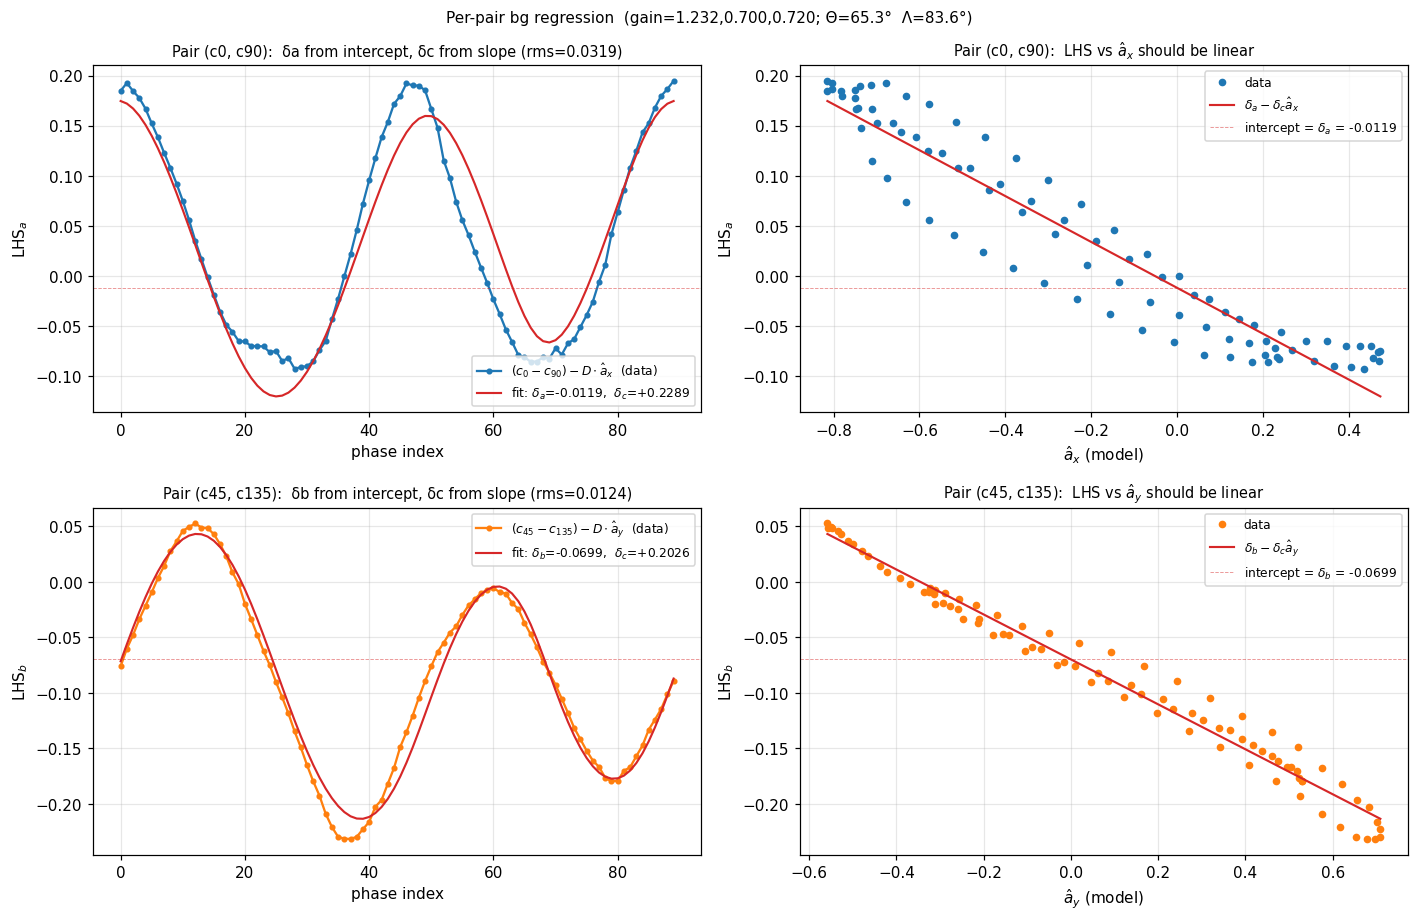

In [67]:
# ── Bg extraction via per-pair linear regression ────────────────────────────
# (c0 - c90) - D · ax_model = δa - δc · ax_model    →  intercept = δa,   slope = -δc
# (c45 - c135) - D · ay_model = δb - δc · ay_model  →  intercept = δb,   slope = -δc


def _bg_regression(gain_vec, geom, label, n_ref=N_REF_PHASE):
    """Run the bg regression with given gain (a90,a45,a135) and geometry
    (Theta, Phi, Lambda).  Returns (delta_a, delta_b, delta_c_a, delta_c_b,
    rms_a, rms_b, packed plotting data dict)."""
    g90, g45, g135 = gain_vec
    Th, Ph, Lm = geom

    # Apply gain → matcor (NO bg subtraction — bg leaves its trace in D and r)
    s = np.vstack((c90_fit, c45_fit, c135_fit, c0_fit)).astype(float).copy()
    s[0] *= g90; s[1] *= g45; s[2] *= g135
    cor = matcor @ s
    c0c   = cor[_idx_fit[0]]
    c90c  = cor[_idx_fit[1]]
    c45c  = cor[_idx_fit[2]]
    c135c = cor[_idx_fit[3]]

    # Build cycle (ax, ay) and additional traces; resample to common grid
    diff_a = c0c   - c90c
    sum_ab = c0c   + c90c
    diff_b = c45c  - c135c
    sum_cd = c45c  + c135c

    valid = (sum_ab > 0) & (sum_cd > 0)
    if valid.sum() < 8:
        return None
    ax_d = diff_a[valid] / sum_ab[valid]
    ay_d = diff_b[valid] / sum_cd[valid]

    # Closed arc-length resample with extra traces carried along
    axc = np.concatenate([ax_d, ax_d[:1]])
    ayc = np.concatenate([ay_d, ay_d[:1]])
    da_c = np.concatenate([diff_a[valid], diff_a[valid][:1]])
    db_c = np.concatenate([diff_b[valid], diff_b[valid][:1]])
    sa_c = np.concatenate([sum_ab[valid], sum_ab[valid][:1]])
    sc_c = np.concatenate([sum_cd[valid], sum_cd[valid][:1]])
    seg = np.hypot(np.diff(axc), np.diff(ayc))
    s_arc = np.concatenate(([0.0], np.cumsum(seg)))
    L = float(s_arc[-1])
    if not np.isfinite(L) or L < 1e-9:
        return None
    t_grid = np.linspace(0.0, L, n_ref, endpoint=False)
    ax_r   = np.interp(t_grid, s_arc, axc)
    ay_r   = np.interp(t_grid, s_arc, ayc)
    dA_r   = np.interp(t_grid, s_arc, da_c)
    dB_r   = np.interp(t_grid, s_arc, db_c)
    sA_r   = np.interp(t_grid, s_arc, sa_c)
    sC_r   = np.interp(t_grid, s_arc, sc_c)
    k0     = int(np.argmin(ax_r))
    ax_r = np.roll(ax_r, -k0); ay_r = np.roll(ay_r, -k0)
    dA_r = np.roll(dA_r, -k0); dB_r = np.roll(dB_r, -k0)
    sA_r = np.roll(sA_r, -k0); sC_r = np.roll(sC_r, -k0)

    # Pair-sum data (D uses average since pair sums should be equal in theory).
    # We keep them separate to allow downstream pair-specific T-matrix imperfection
    # to surface in the slope estimates.
    D_a = sA_r
    D_b = sC_r

    # Pure-Fourkas model curve (no bg) at given geometry
    ax_m_full, ay_m_full = fourkas_template(Th, Ph, Lm, A_cal, B_cal, C_cal,
                                            N_model=N_MODEL_PHASE)

    # Resample model curve to same n_ref points anchored at min ax
    def _resample_close(xx, yy, nout):
        x_c = np.concatenate([xx, xx[:1]])
        y_c = np.concatenate([yy, yy[:1]])
        seg_ = np.hypot(np.diff(x_c), np.diff(y_c))
        s_ = np.concatenate(([0.0], np.cumsum(seg_)))
        Lm_ = float(s_[-1])
        t_ = np.linspace(0.0, Lm_, nout, endpoint=False)
        rx_ = np.interp(t_, s_, x_c); ry_ = np.interp(t_, s_, y_c)
        kk = int(np.argmin(rx_))
        return np.roll(rx_, -kk), np.roll(ry_, -kk)

    rx_mF, ry_mF = _resample_close(ax_m_full, ay_m_full, n_ref)
    rx_mR, ry_mR = _resample_close(ax_m_full[::-1], ay_m_full[::-1], n_ref)
    cF = np.mean((ax_r - rx_mF) ** 2 + (ay_r - ry_mF) ** 2)
    cR = np.mean((ax_r - rx_mR) ** 2 + (ay_r - ry_mR) ** 2)
    if cF <= cR:
        rx_m, ry_m, orient = rx_mF, ry_mF, "forward"
    else:
        rx_m, ry_m, orient = rx_mR, ry_mR, "reversed"

    # ── The regression: y_a = (c0-c90) - D·ax_model = δa - δc·ax_model ──
    LHS_a = dA_r - D_a * rx_m   # length n_ref
    LHS_b = dB_r - D_b * ry_m

    # Pair (c0,c90): regress LHS_a on ax_model → slope = -δc, intercept = δa
    Xa = np.column_stack([np.ones(n_ref), rx_m])
    beta_a, *_ = np.linalg.lstsq(Xa, LHS_a, rcond=None)
    delta_a, neg_delta_c_a = float(beta_a[0]), float(beta_a[1])
    delta_c_a = -neg_delta_c_a
    pred_a = Xa @ beta_a
    rms_a = float(np.sqrt(np.mean((LHS_a - pred_a) ** 2)))

    # Pair (c45,c135): regress LHS_b on ay_model → slope = -δc, intercept = δb
    Xb = np.column_stack([np.ones(n_ref), ry_m])
    beta_b, *_ = np.linalg.lstsq(Xb, LHS_b, rcond=None)
    delta_b, neg_delta_c_b = float(beta_b[0]), float(beta_b[1])
    delta_c_b = -neg_delta_c_b
    pred_b = Xb @ beta_b
    rms_b = float(np.sqrt(np.mean((LHS_b - pred_b) ** 2)))

    return {
        "label":      label,
        "delta_a":    delta_a,
        "delta_b":    delta_b,
        "delta_c_a":  delta_c_a,
        "delta_c_b":  delta_c_b,
        "rms_a":      rms_a,
        "rms_b":      rms_b,
        "rx_m":       rx_m,
        "ry_m":       ry_m,
        "ax_d":       ax_r,
        "ay_d":       ay_r,
        "LHS_a":      LHS_a,
        "LHS_b":      LHS_b,
        "pred_a":     pred_a,
        "pred_b":     pred_b,
        "D_a":        D_a,
        "D_b":        D_b,
        "orient":     orient,
    }


# ── Run primary regression (9h gain + 9h geometry) ───────────────────────────
_geom_j = (Theta_axis_phase, Phi_axis_phase, Lambda_phase)
_res_main = _bg_regression((a90_phase, a45_phase, a135_phase), _geom_j,
                            "9h gain + 9h geom")

print(f"Primary regression  ({_res_main['label']}, model orient={_res_main['orient']})")
print(f"  Pair (c0,c90):    δa = {_res_main['delta_a']:+.5f},  "
      f"δc (from slope) = {_res_main['delta_c_a']:+.5f},  "
      f"residual rms = {_res_main['rms_a']:.5f}")
print(f"  Pair (c45,c135):  δb = {_res_main['delta_b']:+.5f},  "
      f"δc (from slope) = {_res_main['delta_c_b']:+.5f},  "
      f"residual rms = {_res_main['rms_b']:.5f}")

# Compare with 9h's δa, δb, δc
_da_9h = fa_phase * dc_phase
_db_9h = fb_phase * dc_phase
_dc_9h = dc_phase
print(f"\n9h fit-derived:    δa = {_da_9h:+.5f},  δb = {_db_9h:+.5f},  δc = {_dc_9h:+.5f}")
print(f"Disagreement      Δδa = {_res_main['delta_a'] - _da_9h:+.5f}    "
      f"Δδb = {_res_main['delta_b'] - _db_9h:+.5f}")
print(f"δc consistency: from pair a = {_res_main['delta_c_a']:+.5f}, "
      f"from pair b = {_res_main['delta_c_b']:+.5f}, "
      f"diff = {_res_main['delta_c_a'] - _res_main['delta_c_b']:+.5f}")
print(f"                (9h dc = {_dc_9h:+.5f})")

# ── Run alternative gain configurations to see gain × bg coupling ───────────
print("\nGain × bg coupling — same geometry, different gain choices:")
print(f"{'config':<35} {'δa':>10} {'δb':>10} "
      f"{'δc(a)':>10} {'δc(b)':>10} {'rms_a':>9} {'rms_b':>9}")
_alt_configs = [
    ("9h gain",              (a90_phase, a45_phase, a135_phase)),
    ("Section 7 gain",       (a[0], a[1], a[2])),
    ("uniform gain (all 1)", (1.0, 1.0, 1.0)),
]
_alt_results = []
for _lbl, _gv in _alt_configs:
    _r = _bg_regression(_gv, _geom_j, _lbl)
    _alt_results.append(_r)
    print(f"{_lbl:<35} {_r['delta_a']:>+10.5f} {_r['delta_b']:>+10.5f} "
          f"{_r['delta_c_a']:>+10.5f} {_r['delta_c_b']:>+10.5f} "
          f"{_r['rms_a']:>9.5f} {_r['rms_b']:>9.5f}")

# ── Plot ─────────────────────────────────────────────────────────────────────
_phase_idx = np.arange(N_REF_PHASE)
_fig_j, _axj = plt.subplots(2, 2, figsize=(13, 8.5), dpi=110)

# (0,0) Pair-a regression: LHS vs phase, with fitted line
_axj[0, 0].plot(_phase_idx, _res_main['LHS_a'], 'o-', ms=3, color='C0',
                label=r'$(c_0-c_{90}) - D\cdot \hat a_x$  (data)')
_axj[0, 0].plot(_phase_idx, _res_main['pred_a'], '-', lw=1.4, color='C3',
                label=fr'fit: $\delta_a$={_res_main["delta_a"]:+.4f},  '
                      fr'$\delta_c$={_res_main["delta_c_a"]:+.4f}')
_axj[0, 0].axhline(_res_main['delta_a'], color='C3', ls='--', lw=0.6, alpha=0.5)
_axj[0, 0].set_xlabel('phase index')
_axj[0, 0].set_ylabel(r'LHS$_a$')
_axj[0, 0].set_title(f'Pair (c0, c90):  δa from intercept, '
                     f'δc from slope (rms={_res_main["rms_a"]:.4f})',
                     fontsize=9.5)
_axj[0, 0].legend(fontsize=8); _axj[0, 0].grid(alpha=0.3)

# (0,1) LHS_a vs ax_model — straight-line picture
_axj[0, 1].plot(_res_main['rx_m'], _res_main['LHS_a'], 'o', ms=4, color='C0',
                label='data')
_xfit = np.linspace(_res_main['rx_m'].min(), _res_main['rx_m'].max(), 50)
_axj[0, 1].plot(_xfit,
                _res_main['delta_a'] + (-_res_main['delta_c_a']) * _xfit,
                '-', lw=1.4, color='C3',
                label=fr'$\delta_a - \delta_c\hat a_x$')
_axj[0, 1].axhline(_res_main['delta_a'], color='C3', ls='--', lw=0.6, alpha=0.5,
                   label=fr'intercept = $\delta_a$ = {_res_main["delta_a"]:+.4f}')
_axj[0, 1].set_xlabel(r'$\hat a_x$ (model)')
_axj[0, 1].set_ylabel(r'LHS$_a$')
_axj[0, 1].set_title(r'Pair (c0, c90):  LHS vs $\hat a_x$ should be linear', fontsize=9.5)
_axj[0, 1].legend(fontsize=8); _axj[0, 1].grid(alpha=0.3)

# (1,0) Pair-b regression
_axj[1, 0].plot(_phase_idx, _res_main['LHS_b'], 'o-', ms=3, color='C1',
                label=r'$(c_{45}-c_{135}) - D\cdot \hat a_y$  (data)')
_axj[1, 0].plot(_phase_idx, _res_main['pred_b'], '-', lw=1.4, color='C3',
                label=fr'fit: $\delta_b$={_res_main["delta_b"]:+.4f},  '
                      fr'$\delta_c$={_res_main["delta_c_b"]:+.4f}')
_axj[1, 0].axhline(_res_main['delta_b'], color='C3', ls='--', lw=0.6, alpha=0.5)
_axj[1, 0].set_xlabel('phase index')
_axj[1, 0].set_ylabel(r'LHS$_b$')
_axj[1, 0].set_title(f'Pair (c45, c135):  δb from intercept, '
                     f'δc from slope (rms={_res_main["rms_b"]:.4f})',
                     fontsize=9.5)
_axj[1, 0].legend(fontsize=8); _axj[1, 0].grid(alpha=0.3)

# (1,1) LHS_b vs ay_model
_axj[1, 1].plot(_res_main['ry_m'], _res_main['LHS_b'], 'o', ms=4, color='C1',
                label='data')
_yfit = np.linspace(_res_main['ry_m'].min(), _res_main['ry_m'].max(), 50)
_axj[1, 1].plot(_yfit,
                _res_main['delta_b'] + (-_res_main['delta_c_b']) * _yfit,
                '-', lw=1.4, color='C3',
                label=fr'$\delta_b - \delta_c\hat a_y$')
_axj[1, 1].axhline(_res_main['delta_b'], color='C3', ls='--', lw=0.6, alpha=0.5,
                   label=fr'intercept = $\delta_b$ = {_res_main["delta_b"]:+.4f}')
_axj[1, 1].set_xlabel(r'$\hat a_y$ (model)')
_axj[1, 1].set_ylabel(r'LHS$_b$')
_axj[1, 1].set_title(r'Pair (c45, c135):  LHS vs $\hat a_y$ should be linear',
                     fontsize=9.5)
_axj[1, 1].legend(fontsize=8); _axj[1, 1].grid(alpha=0.3)

_fig_j.suptitle(
    f"Per-pair bg regression  (gain={a90_phase:.3f},{a45_phase:.3f},{a135_phase:.3f}; "
    f"Θ={Theta_axis_phase:.1f}°  Λ={Lambda_phase:.1f}°)",
    fontsize=10,
)
plt.tight_layout()
plt.show()

# Save fitted bg estimates for downstream comparison
delta_a_regr = _res_main['delta_a']
delta_b_regr = _res_main['delta_b']
delta_c_a_regr = _res_main['delta_c_a']
delta_c_b_regr = _res_main['delta_c_b']

## 9k. Phase-offset scan: is the 9j residual just data↔model misalignment?

The 9j right-panel "loops" instead of straight lines, plus the dominant
2nd-harmonic structure in the left panels, are exactly the signature of a
small **rotational phase mismatch** between the resampled data cycle and the
resampled model cycle.

If the data is at phase $\psi$ but the model is evaluated at $\psi + \Delta\psi$,
then to first order in $\Delta\psi$:

$$ \text{LHS}(\psi) \approx \delta_a - \delta_c\,\hat a_x(\psi)
   \;-\; D(\psi)\,\frac{d\hat a_x}{d\psi}\,\Delta\psi. $$

The extra term has the **derivative** of $\hat a_x$, which (for a $\cos 2\phi$
signal) is in **quadrature** with $\hat a_x$ at the same fundamental
frequency. Plotted against $\hat a_x$ it produces an **ellipse**, not a line —
exactly what 9j showed.

Plan: scan a sub-index phase shift $\Delta k$ applied to the resampled model,
re-run the regression, and look for the offset that **collapses** the ellipses
to lines (minimum residual rms, zero quadrature component). If a clear minimum
exists, the residual was phase-misalignment and the recovered $\delta_a, \delta_b,
\delta_c$ at that offset are trustworthy.

Phase-offset scan (Δk in resampled-cycle indices, N_REF_PHASE=90):
  pair a min rms = 0.02980 at Δk = +0.200  (+0.80°)
  pair b min rms = 0.01017 at Δk = +0.200  (+0.80°)
  total  min rms = 0.03148 at Δk = +0.200  (+0.80°)

  At Δk=0 (9j baseline): rms_a=0.03187,  rms_b=0.01242
  At total-best Δk:      rms_a=0.02980,  rms_b=0.01017

Recovered bg at total-best Δk = +0.200:
  δa = -0.01282  (was -0.01188 at Δk=0)
  δb = -0.07016  (was -0.06985 at Δk=0)
  δc(a) = +0.22699  (was +0.22893 at Δk=0)
  δc(b) = +0.20139  (was +0.20256 at Δk=0)


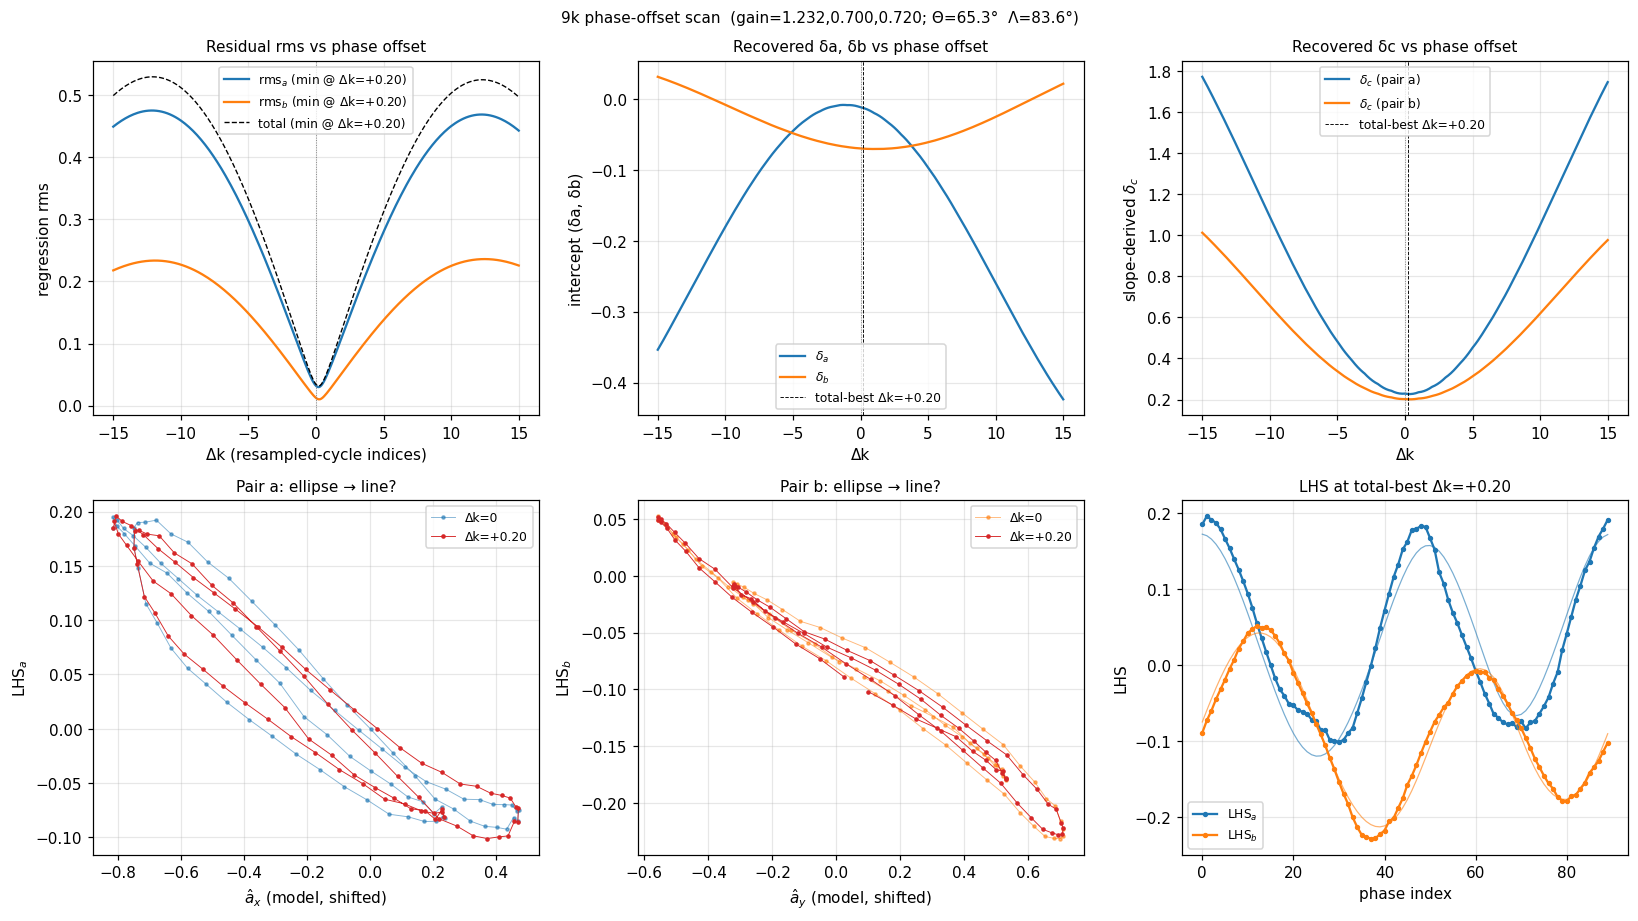

In [68]:
# ── Phase-offset scan around the 9j regression ──────────────────────────────
# Apply a fractional cyclic shift Δk to the resampled model curves and re-run
# the LHS = δ_a - δ_c·â_x linear regression. Look for the offset that minimises
# residual rms (= no in-quadrature derivative term remaining).


def _shift_cyclic(arr, dk):
    """Linear interp cyclic shift by fractional dk (in sample units of arr).
    arr[k] becomes arr[k - dk]."""
    n = len(arr)
    idx = (np.arange(n) - dk) % n
    i0 = np.floor(idx).astype(int)
    f = idx - i0
    i1 = (i0 + 1) % n
    return (1 - f) * arr[i0] + f * arr[i1]


def _bg_regression_with_shift(gain_vec, geom, dk, n_ref=N_REF_PHASE):
    """Same as _bg_regression but applies fractional cyclic shift dk to the
    resampled model curves before regressing."""
    g90, g45, g135 = gain_vec
    Th, Ph, Lm = geom

    s = np.vstack((c90_fit, c45_fit, c135_fit, c0_fit)).astype(float).copy()
    s[0] *= g90; s[1] *= g45; s[2] *= g135
    cor = matcor @ s
    c0c   = cor[_idx_fit[0]]
    c90c  = cor[_idx_fit[1]]
    c45c  = cor[_idx_fit[2]]
    c135c = cor[_idx_fit[3]]

    diff_a = c0c - c90c
    sum_ab = c0c + c90c
    diff_b = c45c - c135c
    sum_cd = c45c + c135c
    valid = (sum_ab > 0) & (sum_cd > 0)
    if valid.sum() < 8:
        return None
    ax_d = diff_a[valid] / sum_ab[valid]
    ay_d = diff_b[valid] / sum_cd[valid]

    def _close(x):
        return np.concatenate([x, x[:1]])
    seg = np.hypot(np.diff(_close(ax_d)), np.diff(_close(ay_d)))
    s_arc = np.concatenate(([0.0], np.cumsum(seg)))
    L = float(s_arc[-1])
    if not np.isfinite(L) or L < 1e-9:
        return None
    t_grid = np.linspace(0.0, L, n_ref, endpoint=False)
    ax_r = np.interp(t_grid, s_arc, _close(ax_d))
    ay_r = np.interp(t_grid, s_arc, _close(ay_d))
    dA_r = np.interp(t_grid, s_arc, _close(diff_a[valid]))
    dB_r = np.interp(t_grid, s_arc, _close(diff_b[valid]))
    sA_r = np.interp(t_grid, s_arc, _close(sum_ab[valid]))
    sC_r = np.interp(t_grid, s_arc, _close(sum_cd[valid]))
    k0 = int(np.argmin(ax_r))
    ax_r = np.roll(ax_r, -k0); ay_r = np.roll(ay_r, -k0)
    dA_r = np.roll(dA_r, -k0); dB_r = np.roll(dB_r, -k0)
    sA_r = np.roll(sA_r, -k0); sC_r = np.roll(sC_r, -k0)

    ax_m_full, ay_m_full = fourkas_template(Th, Ph, Lm, A_cal, B_cal, C_cal,
                                            N_model=N_MODEL_PHASE)

    def _resample_close(xx, yy, nout):
        xc = np.concatenate([xx, xx[:1]]); yc = np.concatenate([yy, yy[:1]])
        seg_ = np.hypot(np.diff(xc), np.diff(yc))
        s_ = np.concatenate(([0.0], np.cumsum(seg_)))
        Lm_ = float(s_[-1])
        t_ = np.linspace(0.0, Lm_, nout, endpoint=False)
        rx_ = np.interp(t_, s_, xc); ry_ = np.interp(t_, s_, yc)
        kk = int(np.argmin(rx_))
        return np.roll(rx_, -kk), np.roll(ry_, -kk)

    rx_mF, ry_mF = _resample_close(ax_m_full, ay_m_full, n_ref)
    rx_mR, ry_mR = _resample_close(ax_m_full[::-1], ay_m_full[::-1], n_ref)
    cF = np.mean((ax_r - rx_mF) ** 2 + (ay_r - ry_mF) ** 2)
    cR = np.mean((ax_r - rx_mR) ** 2 + (ay_r - ry_mR) ** 2)
    rx_m, ry_m = (rx_mF, ry_mF) if cF <= cR else (rx_mR, ry_mR)
    orient = "forward" if cF <= cR else "reversed"

    # Apply fractional cyclic shift Δk to the model
    rx_m = _shift_cyclic(rx_m, dk)
    ry_m = _shift_cyclic(ry_m, dk)

    LHS_a = dA_r - sA_r * rx_m
    LHS_b = dB_r - sC_r * ry_m
    Xa = np.column_stack([np.ones(n_ref), rx_m])
    beta_a, *_ = np.linalg.lstsq(Xa, LHS_a, rcond=None)
    Xb = np.column_stack([np.ones(n_ref), ry_m])
    beta_b, *_ = np.linalg.lstsq(Xb, LHS_b, rcond=None)
    pred_a = Xa @ beta_a
    pred_b = Xb @ beta_b
    rms_a = float(np.sqrt(np.mean((LHS_a - pred_a) ** 2)))
    rms_b = float(np.sqrt(np.mean((LHS_b - pred_b) ** 2)))

    return {
        "dk":        float(dk),
        "delta_a":   float(beta_a[0]),
        "delta_c_a": float(-beta_a[1]),
        "delta_b":   float(beta_b[0]),
        "delta_c_b": float(-beta_b[1]),
        "rms_a":     rms_a,
        "rms_b":     rms_b,
        "ax_d":      ax_r, "ay_d": ay_r,
        "rx_m":      rx_m, "ry_m": ry_m,
        "LHS_a":     LHS_a, "LHS_b": LHS_b,
        "pred_a":    pred_a, "pred_b": pred_b,
        "orient":    orient,
    }


# ── Sweep Δk over a wide range, fine grid ───────────────────────────────────
_geom_k = (Theta_axis_phase, Phi_axis_phase, Lambda_phase)
_gain_k = (a90_phase, a45_phase, a135_phase)

_dk_scan = np.linspace(-15.0, 15.0, 301)   # ±15 of N_REF_PHASE=90 ≈ ±60°
_rms_a_scan = np.empty_like(_dk_scan)
_rms_b_scan = np.empty_like(_dk_scan)
_da_scan    = np.empty_like(_dk_scan)
_db_scan    = np.empty_like(_dk_scan)
_dca_scan   = np.empty_like(_dk_scan)
_dcb_scan   = np.empty_like(_dk_scan)
for i, _dk in enumerate(_dk_scan):
    _rk = _bg_regression_with_shift(_gain_k, _geom_k, _dk)
    _rms_a_scan[i] = _rk['rms_a']
    _rms_b_scan[i] = _rk['rms_b']
    _da_scan[i]    = _rk['delta_a']
    _db_scan[i]    = _rk['delta_b']
    _dca_scan[i]   = _rk['delta_c_a']
    _dcb_scan[i]   = _rk['delta_c_b']

_rms_total_scan = np.hypot(_rms_a_scan, _rms_b_scan)
_i_min_a = int(np.argmin(_rms_a_scan))
_i_min_b = int(np.argmin(_rms_b_scan))
_i_min_t = int(np.argmin(_rms_total_scan))

_dk_best_a = _dk_scan[_i_min_a]
_dk_best_b = _dk_scan[_i_min_b]
_dk_best_t = _dk_scan[_i_min_t]

print("Phase-offset scan (Δk in resampled-cycle indices, N_REF_PHASE=90):")
print(f"  pair a min rms = {_rms_a_scan[_i_min_a]:.5f} at Δk = {_dk_best_a:+.3f}  "
      f"({_dk_best_a/N_REF_PHASE*360:+.2f}°)")
print(f"  pair b min rms = {_rms_b_scan[_i_min_b]:.5f} at Δk = {_dk_best_b:+.3f}  "
      f"({_dk_best_b/N_REF_PHASE*360:+.2f}°)")
print(f"  total  min rms = {_rms_total_scan[_i_min_t]:.5f} at Δk = {_dk_best_t:+.3f}  "
      f"({_dk_best_t/N_REF_PHASE*360:+.2f}°)")
print(f"\n  At Δk=0 (9j baseline): rms_a={_rms_a_scan[len(_dk_scan)//2]:.5f},  "
      f"rms_b={_rms_b_scan[len(_dk_scan)//2]:.5f}")
print(f"  At total-best Δk:      rms_a={_rms_a_scan[_i_min_t]:.5f},  "
      f"rms_b={_rms_b_scan[_i_min_t]:.5f}")
print(f"\nRecovered bg at total-best Δk = {_dk_best_t:+.3f}:")
print(f"  δa = {_da_scan[_i_min_t]:+.5f}  (was {delta_a_regr:+.5f} at Δk=0)")
print(f"  δb = {_db_scan[_i_min_t]:+.5f}  (was {delta_b_regr:+.5f} at Δk=0)")
print(f"  δc(a) = {_dca_scan[_i_min_t]:+.5f}  (was {delta_c_a_regr:+.5f} at Δk=0)")
print(f"  δc(b) = {_dcb_scan[_i_min_t]:+.5f}  (was {delta_c_b_regr:+.5f} at Δk=0)")

# Re-run regression at the per-pair best offsets to inspect ellipse collapse
_res_best_a = _bg_regression_with_shift(_gain_k, _geom_k, _dk_best_a)
_res_best_b = _bg_regression_with_shift(_gain_k, _geom_k, _dk_best_b)
_res_zero   = _bg_regression_with_shift(_gain_k, _geom_k, 0.0)

# ── Plot ─────────────────────────────────────────────────────────────────────
_fig_k, _axk = plt.subplots(2, 3, figsize=(15, 8.5), dpi=110)

# (0,0) rms vs Δk
_axk[0, 0].plot(_dk_scan, _rms_a_scan, '-', color='C0',
                label=f"rms$_a$ (min @ Δk={_dk_best_a:+.2f})")
_axk[0, 0].plot(_dk_scan, _rms_b_scan, '-', color='C1',
                label=f"rms$_b$ (min @ Δk={_dk_best_b:+.2f})")
_axk[0, 0].plot(_dk_scan, _rms_total_scan, '--', color='k', lw=0.9,
                label=f"total (min @ Δk={_dk_best_t:+.2f})")
_axk[0, 0].axvline(0.0, color='gray', lw=0.6, ls=':')
_axk[0, 0].set_xlabel('Δk (resampled-cycle indices)')
_axk[0, 0].set_ylabel('regression rms')
_axk[0, 0].set_title('Residual rms vs phase offset', fontsize=10)
_axk[0, 0].legend(fontsize=8); _axk[0, 0].grid(alpha=0.3)

# (0,1) recovered δa, δb vs Δk
_axk[0, 1].plot(_dk_scan, _da_scan, '-', color='C0', label=r'$\delta_a$')
_axk[0, 1].plot(_dk_scan, _db_scan, '-', color='C1', label=r'$\delta_b$')
_axk[0, 1].axvline(_dk_best_t, color='k', ls='--', lw=0.6,
                   label=f'total-best Δk={_dk_best_t:+.2f}')
_axk[0, 1].axvline(0.0, color='gray', lw=0.6, ls=':')
_axk[0, 1].set_xlabel('Δk')
_axk[0, 1].set_ylabel('intercept (δa, δb)')
_axk[0, 1].set_title('Recovered δa, δb vs phase offset', fontsize=10)
_axk[0, 1].legend(fontsize=8); _axk[0, 1].grid(alpha=0.3)

# (0,2) recovered δc from each pair
_axk[0, 2].plot(_dk_scan, _dca_scan, '-', color='C0', label=r'$\delta_c$ (pair a)')
_axk[0, 2].plot(_dk_scan, _dcb_scan, '-', color='C1', label=r'$\delta_c$ (pair b)')
_axk[0, 2].axvline(_dk_best_t, color='k', ls='--', lw=0.6,
                   label=f'total-best Δk={_dk_best_t:+.2f}')
_axk[0, 2].axvline(0.0, color='gray', lw=0.6, ls=':')
_axk[0, 2].set_xlabel('Δk')
_axk[0, 2].set_ylabel(r'slope-derived $\delta_c$')
_axk[0, 2].set_title('Recovered δc vs phase offset', fontsize=10)
_axk[0, 2].legend(fontsize=8); _axk[0, 2].grid(alpha=0.3)

# (1,0) LHS_a vs ax_model — Δk=0 vs Δk=best (ellipse collapse?)
_axk[1, 0].plot(_res_zero['rx_m'], _res_zero['LHS_a'], 'o-', ms=2, lw=0.6,
                color='C0', alpha=0.55, label='Δk=0')
_axk[1, 0].plot(_res_best_a['rx_m'], _res_best_a['LHS_a'], 'o-', ms=2, lw=0.6,
                color='C3', label=f'Δk={_dk_best_a:+.2f}')
_axk[1, 0].set_xlabel(r'$\hat a_x$ (model, shifted)')
_axk[1, 0].set_ylabel(r'LHS$_a$')
_axk[1, 0].set_title('Pair a: ellipse → line?', fontsize=10)
_axk[1, 0].legend(fontsize=8); _axk[1, 0].grid(alpha=0.3)

# (1,1) LHS_b vs ay_model — same
_axk[1, 1].plot(_res_zero['ry_m'], _res_zero['LHS_b'], 'o-', ms=2, lw=0.6,
                color='C1', alpha=0.55, label='Δk=0')
_axk[1, 1].plot(_res_best_b['ry_m'], _res_best_b['LHS_b'], 'o-', ms=2, lw=0.6,
                color='C3', label=f'Δk={_dk_best_b:+.2f}')
_axk[1, 1].set_xlabel(r'$\hat a_y$ (model, shifted)')
_axk[1, 1].set_ylabel(r'LHS$_b$')
_axk[1, 1].set_title('Pair b: ellipse → line?', fontsize=10)
_axk[1, 1].legend(fontsize=8); _axk[1, 1].grid(alpha=0.3)

# (1,2) LHS time-series at best total offset
_res_best_t = _bg_regression_with_shift(_gain_k, _geom_k, _dk_best_t)
_phase_idx = np.arange(N_REF_PHASE)
_axk[1, 2].plot(_phase_idx, _res_best_t['LHS_a'], 'o-', ms=2.5, color='C0',
                label='LHS$_a$')
_axk[1, 2].plot(_phase_idx, _res_best_t['pred_a'], '-', color='C0', lw=0.8, alpha=0.6)
_axk[1, 2].plot(_phase_idx, _res_best_t['LHS_b'], 'o-', ms=2.5, color='C1',
                label='LHS$_b$')
_axk[1, 2].plot(_phase_idx, _res_best_t['pred_b'], '-', color='C1', lw=0.8, alpha=0.6)
_axk[1, 2].set_xlabel('phase index')
_axk[1, 2].set_ylabel('LHS')
_axk[1, 2].set_title(f'LHS at total-best Δk={_dk_best_t:+.2f}', fontsize=10)
_axk[1, 2].legend(fontsize=8); _axk[1, 2].grid(alpha=0.3)

_fig_k.suptitle(
    f"9k phase-offset scan  (gain={a90_phase:.3f},{a45_phase:.3f},{a135_phase:.3f}; "
    f"Θ={Theta_axis_phase:.1f}°  Λ={Lambda_phase:.1f}°)",
    fontsize=10,
)
plt.tight_layout()
plt.show()

## 9l. Fourkas (A, B, C) sanity check via NA-scan

9k confirmed the 9j residual is **not** phase mismatch (rms minimum is exactly
at Δk=0, ellipses don't collapse). The dominant 2nd-harmonic structure must
therefore come from a model deficiency. The most likely one is the
**Fourkas (A, B, C) coefficients** — they enter the model only as ratios that
shape $\hat a_x = C\sin^2\theta\cos 2\phi / (A+B\sin^2\theta)$, and a wrong
ratio produces a 2nd-harmonic residual whose amplitude scales with $D$.

These coefficients are computed in Section 8 from annular integrals over
$\beta \in [\alpha_{\rm in}, \alpha_{\rm out}]$ of:

$$ J_1=\!\int(2\cos^2\beta + \tfrac34\sin^4\beta)\sin\beta\,d\beta,\;
   J_2=\!\int\tfrac14\sin^4\beta\sin\beta\,d\beta,\;
   J_3=\!\int\sin^2\beta\cos^2\beta\sin\beta\,d\beta, $$
$$ C=J_1-J_2,\quad A=2J_3,\quad B=J_1+J_2-2J_3. $$

Of the three inputs (`NA_in`, `NA_out`, `n_w`), `NA_out` is the objective spec
(known to 1%) and `n_w=1.33` is fixed. **`NA_in` (the back-aperture hole edge)**
is the most likely to be miscalibrated. We scan it and look at how the 9j
regression rms responds. A clear minimum at some `NA_in*` ≠ 0.38 would mean
the current calibration is biased on this sample — and the bg estimates at
that minimum are the cleaner ones.

We also run a smaller secondary scan over `NA_out` to make sure we haven't
locked in to a wrong outer NA.

Current calibration:
  NA_in=0.380, NA_out=1.300, n_w=1.330
  A=0.25731, B=0.65137, C=0.74456, r_sat=0.81939
  9j rms (current calibration): rms_a=0.03187, rms_b=0.01242, total=0.03421

NA_in coarse scan (0.00→1.10):
  best NA_in = 1.0200  (rms_total = 0.02934)
NA_in fine scan around best:
  best NA_in = 1.0100  (rms_total = 0.02930)
  recovered:  A=0.13087, B=0.33180, C=0.32000, r_sat=0.69164
  recovered bg: δa=-0.01503  δb=-0.06761  δc(a)=+0.01134  δc(b)=+0.09102

NA_out scan (1.10→1.32, NA_in fixed at 0.380):
  best NA_out = 1.3108  (rms_total = 0.03401)


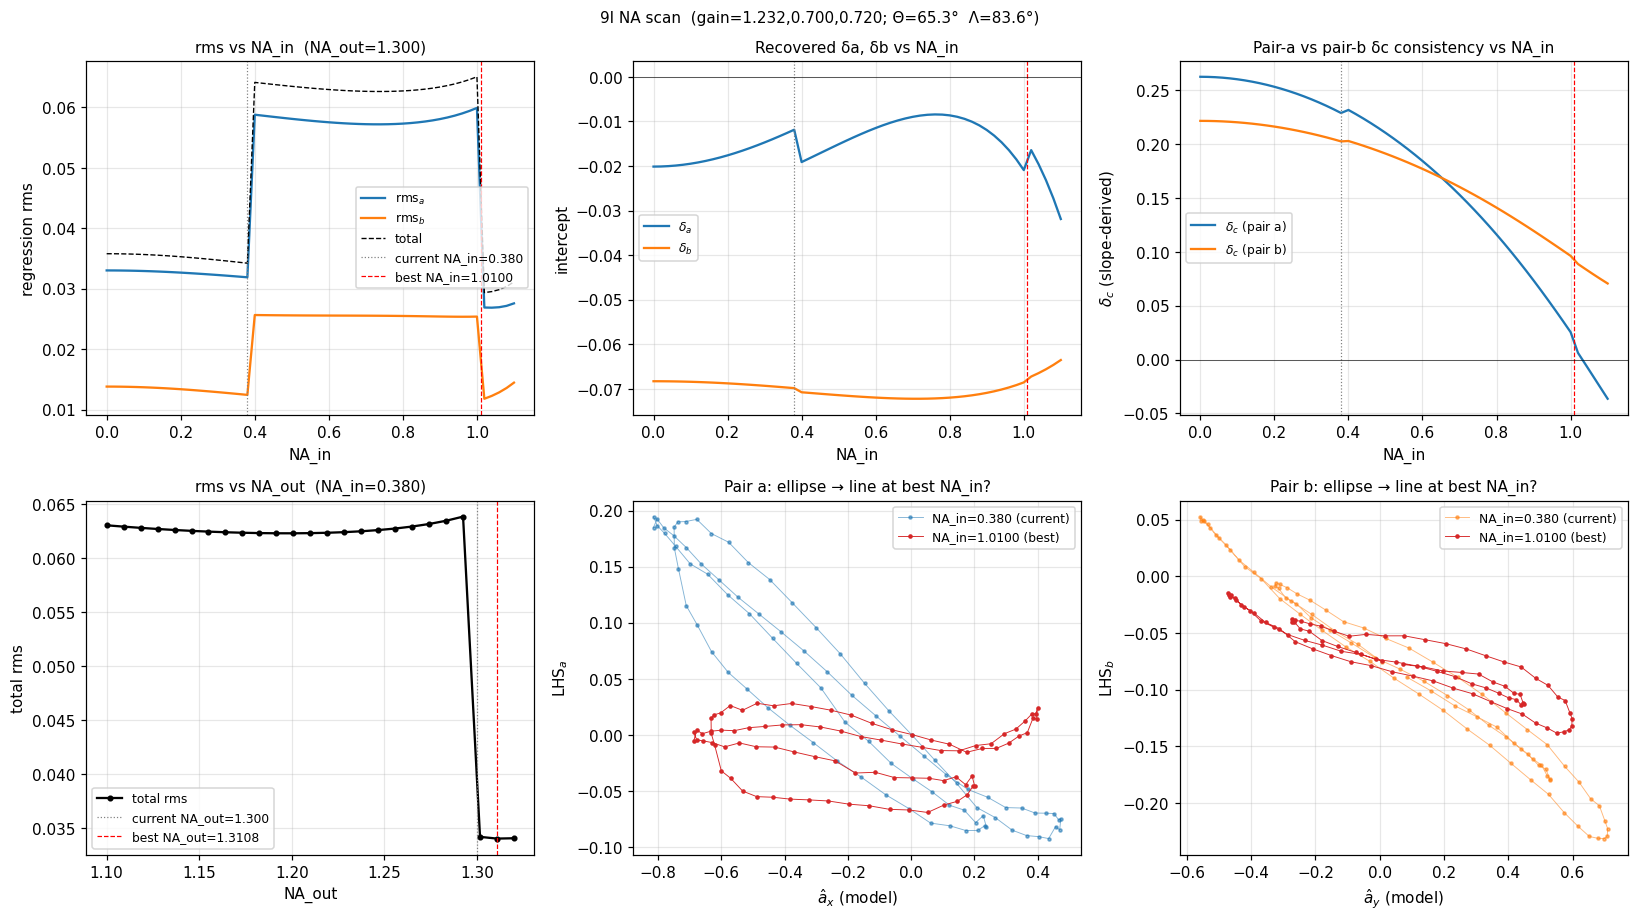

In [69]:
# ── NA-scan over Fourkas (A, B, C) ──────────────────────────────────────────
# Recompute (A, B, C) for each (NA_in, NA_out) pair and rerun the 9j regression.

from scipy.integrate import quad as _quad


def _hole_ABC(na_in, na_out, n_med=nw):
    """Annular Fourkas coefficients for given (NA_in, NA_out, n_w)."""
    a_in  = np.arcsin(na_in  / n_med)
    a_out = np.arcsin(na_out / n_med)
    j1, _ = _quad(lambda b: (2*np.cos(b)**2 + 0.75*np.sin(b)**4) * np.sin(b),
                  a_in, a_out)
    j2, _ = _quad(lambda b: 0.25 * np.sin(b)**4 * np.sin(b), a_in, a_out)
    j3, _ = _quad(lambda b: np.sin(b)**2 * np.cos(b)**2 * np.sin(b),
                  a_in, a_out)
    return j1 - j2, 2*j3, j1 + j2 - 2*j3   # C, A, B  →  re-order:
    # caller expects (A, B, C); rebuild below


def _ABC(na_in, na_out, n_med=nw):
    C_, A_, B_ = _hole_ABC(na_in, na_out, n_med)
    return A_, B_, C_


def _bg_regression_with_ABC(gain_vec, geom, ABC, n_ref=N_REF_PHASE):
    """Same as 9j regression but with explicit (A, B, C) tuple instead of
    A_cal/B_cal/C_cal globals."""
    g90, g45, g135 = gain_vec
    Th, Ph, Lm = geom
    A_, B_, C_ = ABC

    s = np.vstack((c90_fit, c45_fit, c135_fit, c0_fit)).astype(float).copy()
    s[0] *= g90; s[1] *= g45; s[2] *= g135
    cor = matcor @ s
    c0c   = cor[_idx_fit[0]]
    c90c  = cor[_idx_fit[1]]
    c45c  = cor[_idx_fit[2]]
    c135c = cor[_idx_fit[3]]

    diff_a = c0c - c90c
    sum_ab = c0c + c90c
    diff_b = c45c - c135c
    sum_cd = c45c + c135c
    valid = (sum_ab > 0) & (sum_cd > 0)
    if valid.sum() < 8:
        return None

    ax_d = diff_a[valid] / sum_ab[valid]
    ay_d = diff_b[valid] / sum_cd[valid]

    def _close(x):
        return np.concatenate([x, x[:1]])

    seg = np.hypot(np.diff(_close(ax_d)), np.diff(_close(ay_d)))
    s_arc = np.concatenate(([0.0], np.cumsum(seg)))
    L = float(s_arc[-1])
    if not np.isfinite(L) or L < 1e-9:
        return None
    t_grid = np.linspace(0.0, L, n_ref, endpoint=False)
    ax_r = np.interp(t_grid, s_arc, _close(ax_d))
    ay_r = np.interp(t_grid, s_arc, _close(ay_d))
    dA_r = np.interp(t_grid, s_arc, _close(diff_a[valid]))
    dB_r = np.interp(t_grid, s_arc, _close(diff_b[valid]))
    sA_r = np.interp(t_grid, s_arc, _close(sum_ab[valid]))
    sC_r = np.interp(t_grid, s_arc, _close(sum_cd[valid]))
    k0 = int(np.argmin(ax_r))
    ax_r = np.roll(ax_r, -k0); ay_r = np.roll(ay_r, -k0)
    dA_r = np.roll(dA_r, -k0); dB_r = np.roll(dB_r, -k0)
    sA_r = np.roll(sA_r, -k0); sC_r = np.roll(sC_r, -k0)

    ax_m_full, ay_m_full = fourkas_template(Th, Ph, Lm, A_, B_, C_,
                                            N_model=N_MODEL_PHASE)

    def _resample_close(xx, yy, nout):
        xc = np.concatenate([xx, xx[:1]]); yc = np.concatenate([yy, yy[:1]])
        seg_ = np.hypot(np.diff(xc), np.diff(yc))
        s_ = np.concatenate(([0.0], np.cumsum(seg_)))
        Lm_ = float(s_[-1])
        t_ = np.linspace(0.0, Lm_, nout, endpoint=False)
        rx_ = np.interp(t_, s_, xc); ry_ = np.interp(t_, s_, yc)
        kk = int(np.argmin(rx_))
        return np.roll(rx_, -kk), np.roll(ry_, -kk)

    rx_mF, ry_mF = _resample_close(ax_m_full, ay_m_full, n_ref)
    rx_mR, ry_mR = _resample_close(ax_m_full[::-1], ay_m_full[::-1], n_ref)
    cF = np.mean((ax_r - rx_mF) ** 2 + (ay_r - ry_mF) ** 2)
    cR = np.mean((ax_r - rx_mR) ** 2 + (ay_r - ry_mR) ** 2)
    rx_m, ry_m = (rx_mF, ry_mF) if cF <= cR else (rx_mR, ry_mR)

    LHS_a = dA_r - sA_r * rx_m
    LHS_b = dB_r - sC_r * ry_m
    Xa = np.column_stack([np.ones(n_ref), rx_m])
    Xb = np.column_stack([np.ones(n_ref), ry_m])
    beta_a, *_ = np.linalg.lstsq(Xa, LHS_a, rcond=None)
    beta_b, *_ = np.linalg.lstsq(Xb, LHS_b, rcond=None)
    pred_a = Xa @ beta_a
    pred_b = Xb @ beta_b

    return {
        "A": A_, "B": B_, "C": C_,
        "rsat":      C_ / (A_ + B_),
        "delta_a":   float(beta_a[0]),
        "delta_c_a": float(-beta_a[1]),
        "delta_b":   float(beta_b[0]),
        "delta_c_b": float(-beta_b[1]),
        "rms_a":     float(np.sqrt(np.mean((LHS_a - pred_a) ** 2))),
        "rms_b":     float(np.sqrt(np.mean((LHS_b - pred_b) ** 2))),
        "ax_r":      ax_r, "ay_r": ay_r,
        "rx_m":      rx_m, "ry_m": ry_m,
        "LHS_a":     LHS_a, "LHS_b": LHS_b,
        "pred_a":    pred_a, "pred_b": pred_b,
    }


_geom_l = (Theta_axis_phase, Phi_axis_phase, Lambda_phase)
_gain_l = (a90_phase, a45_phase, a135_phase)

# ── Primary scan: NA_in ∈ [0.0, 1.10], NA_out fixed at current value ────────
_NAin_grid = np.linspace(0.0, 1.10, 56)
_rms_a_in  = np.empty_like(_NAin_grid)
_rms_b_in  = np.empty_like(_NAin_grid)
_da_in     = np.empty_like(_NAin_grid)
_db_in     = np.empty_like(_NAin_grid)
_dca_in    = np.empty_like(_NAin_grid)
_dcb_in    = np.empty_like(_NAin_grid)
_rsat_in   = np.empty_like(_NAin_grid)
for i, _nai in enumerate(_NAin_grid):
    _ABC_i = _ABC(_nai, NA_out)
    _rl = _bg_regression_with_ABC(_gain_l, _geom_l, _ABC_i)
    _rms_a_in[i] = _rl['rms_a']; _rms_b_in[i] = _rl['rms_b']
    _da_in[i]    = _rl['delta_a']; _db_in[i]   = _rl['delta_b']
    _dca_in[i]   = _rl['delta_c_a']; _dcb_in[i] = _rl['delta_c_b']
    _rsat_in[i]  = _rl['rsat']
_rms_total_in = np.hypot(_rms_a_in, _rms_b_in)
_imin_in = int(np.argmin(_rms_total_in))
_NAin_best = float(_NAin_grid[_imin_in])

# Sub-scan: refine NA_in around the minimum
_NAin_fine = np.linspace(max(0.0, _NAin_best - 0.10),
                         min(NA_out - 0.02, _NAin_best + 0.10),
                         101)
_rms_total_fine = np.empty_like(_NAin_fine)
_da_fine        = np.empty_like(_NAin_fine)
_db_fine        = np.empty_like(_NAin_fine)
_dca_fine       = np.empty_like(_NAin_fine)
_dcb_fine       = np.empty_like(_NAin_fine)
for i, _nai in enumerate(_NAin_fine):
    _rl = _bg_regression_with_ABC(_gain_l, _geom_l, _ABC(_nai, NA_out))
    _rms_total_fine[i] = np.hypot(_rl['rms_a'], _rl['rms_b'])
    _da_fine[i]  = _rl['delta_a'];  _db_fine[i]  = _rl['delta_b']
    _dca_fine[i] = _rl['delta_c_a']; _dcb_fine[i] = _rl['delta_c_b']
_imin_fine = int(np.argmin(_rms_total_fine))
_NAin_best_fine = float(_NAin_fine[_imin_fine])

# ── Secondary: NA_out scan at current NA_in ────────────────────────────────
_NAout_grid = np.linspace(max(NA_in + 0.05, 1.10), 1.32, 25)
_rms_total_out = np.empty_like(_NAout_grid)
for i, _nao in enumerate(_NAout_grid):
    _rl = _bg_regression_with_ABC(_gain_l, _geom_l, _ABC(NA_in, _nao))
    _rms_total_out[i] = np.hypot(_rl['rms_a'], _rl['rms_b'])
_imin_out = int(np.argmin(_rms_total_out))
_NAout_best = float(_NAout_grid[_imin_out])

# ── Reports ─────────────────────────────────────────────────────────────────
print("Current calibration:")
print(f"  NA_in={NA_in:.3f}, NA_out={NA_out:.3f}, n_w={nw:.3f}")
print(f"  A={A_cal:.5f}, B={B_cal:.5f}, C={C_cal:.5f}, r_sat={R_SAT:.5f}")
_rl_curr = _bg_regression_with_ABC(_gain_l, _geom_l, (A_cal, B_cal, C_cal))
print(f"  9j rms (current calibration): rms_a={_rl_curr['rms_a']:.5f}, "
      f"rms_b={_rl_curr['rms_b']:.5f}, total={np.hypot(_rl_curr['rms_a'], _rl_curr['rms_b']):.5f}")

print(f"\nNA_in coarse scan ({_NAin_grid[0]:.2f}→{_NAin_grid[-1]:.2f}):")
print(f"  best NA_in = {_NAin_best:.4f}  (rms_total = {_rms_total_in[_imin_in]:.5f})")
_rl_b = _bg_regression_with_ABC(_gain_l, _geom_l, _ABC(_NAin_best_fine, NA_out))
print(f"NA_in fine scan around best:")
print(f"  best NA_in = {_NAin_best_fine:.4f}  (rms_total = {_rms_total_fine[_imin_fine]:.5f})")
print(f"  recovered:  A={_rl_b['A']:.5f}, B={_rl_b['B']:.5f}, C={_rl_b['C']:.5f}, "
      f"r_sat={_rl_b['rsat']:.5f}")
print(f"  recovered bg: δa={_rl_b['delta_a']:+.5f}  δb={_rl_b['delta_b']:+.5f}  "
      f"δc(a)={_rl_b['delta_c_a']:+.5f}  δc(b)={_rl_b['delta_c_b']:+.5f}")

print(f"\nNA_out scan ({_NAout_grid[0]:.2f}→{_NAout_grid[-1]:.2f}, NA_in fixed at {NA_in:.3f}):")
print(f"  best NA_out = {_NAout_best:.4f}  (rms_total = {_rms_total_out[_imin_out]:.5f})")

# ── Plot ─────────────────────────────────────────────────────────────────────
_fig_l, _axl = plt.subplots(2, 3, figsize=(15, 8.5), dpi=110)

# (0,0) rms vs NA_in (coarse)
_axl[0, 0].plot(_NAin_grid, _rms_a_in, '-', color='C0', label='rms$_a$')
_axl[0, 0].plot(_NAin_grid, _rms_b_in, '-', color='C1', label='rms$_b$')
_axl[0, 0].plot(_NAin_grid, _rms_total_in, '--', color='k', lw=0.9, label='total')
_axl[0, 0].axvline(NA_in, color='gray', ls=':', lw=0.8,
                   label=f'current NA_in={NA_in:.3f}')
_axl[0, 0].axvline(_NAin_best_fine, color='red', ls='--', lw=0.8,
                   label=f'best NA_in={_NAin_best_fine:.4f}')
_axl[0, 0].set_xlabel('NA_in')
_axl[0, 0].set_ylabel('regression rms')
_axl[0, 0].set_title(f'rms vs NA_in  (NA_out={NA_out:.3f})', fontsize=10)
_axl[0, 0].legend(fontsize=8); _axl[0, 0].grid(alpha=0.3)

# (0,1) recovered δa, δb vs NA_in
_axl[0, 1].plot(_NAin_grid, _da_in, '-', color='C0', label=r'$\delta_a$')
_axl[0, 1].plot(_NAin_grid, _db_in, '-', color='C1', label=r'$\delta_b$')
_axl[0, 1].axvline(NA_in, color='gray', ls=':', lw=0.8)
_axl[0, 1].axvline(_NAin_best_fine, color='red', ls='--', lw=0.8)
_axl[0, 1].axhline(0, color='k', lw=0.4)
_axl[0, 1].set_xlabel('NA_in'); _axl[0, 1].set_ylabel('intercept')
_axl[0, 1].set_title('Recovered δa, δb vs NA_in', fontsize=10)
_axl[0, 1].legend(fontsize=8); _axl[0, 1].grid(alpha=0.3)

# (0,2) recovered δc(a), δc(b) vs NA_in (consistency = how close they are)
_axl[0, 2].plot(_NAin_grid, _dca_in, '-', color='C0', label=r'$\delta_c$ (pair a)')
_axl[0, 2].plot(_NAin_grid, _dcb_in, '-', color='C1', label=r'$\delta_c$ (pair b)')
_axl[0, 2].axvline(NA_in, color='gray', ls=':', lw=0.8)
_axl[0, 2].axvline(_NAin_best_fine, color='red', ls='--', lw=0.8)
_axl[0, 2].axhline(0, color='k', lw=0.4)
_axl[0, 2].set_xlabel('NA_in'); _axl[0, 2].set_ylabel(r'$\delta_c$ (slope-derived)')
_axl[0, 2].set_title('Pair-a vs pair-b δc consistency vs NA_in', fontsize=10)
_axl[0, 2].legend(fontsize=8); _axl[0, 2].grid(alpha=0.3)

# (1,0) rms vs NA_out
_axl[1, 0].plot(_NAout_grid, _rms_total_out, 'o-', color='k', ms=3,
                label='total rms')
_axl[1, 0].axvline(NA_out, color='gray', ls=':', lw=0.8,
                   label=f'current NA_out={NA_out:.3f}')
_axl[1, 0].axvline(_NAout_best, color='red', ls='--', lw=0.8,
                   label=f'best NA_out={_NAout_best:.4f}')
_axl[1, 0].set_xlabel('NA_out')
_axl[1, 0].set_ylabel('total rms')
_axl[1, 0].set_title(f'rms vs NA_out  (NA_in={NA_in:.3f})', fontsize=10)
_axl[1, 0].legend(fontsize=8); _axl[1, 0].grid(alpha=0.3)

# (1,1) ellipse-collapse: LHS_a vs ax_model — current vs best
_axl[1, 1].plot(_rl_curr['rx_m'], _rl_curr['LHS_a'], 'o-', ms=2, lw=0.6,
                color='C0', alpha=0.55, label=f'NA_in={NA_in:.3f} (current)')
_axl[1, 1].plot(_rl_b['rx_m'], _rl_b['LHS_a'], 'o-', ms=2, lw=0.6,
                color='C3', label=f'NA_in={_NAin_best_fine:.4f} (best)')
_axl[1, 1].set_xlabel(r'$\hat a_x$ (model)')
_axl[1, 1].set_ylabel(r'LHS$_a$')
_axl[1, 1].set_title('Pair a: ellipse → line at best NA_in?', fontsize=10)
_axl[1, 1].legend(fontsize=8); _axl[1, 1].grid(alpha=0.3)

# (1,2) ellipse-collapse: LHS_b vs ay_model
_axl[1, 2].plot(_rl_curr['ry_m'], _rl_curr['LHS_b'], 'o-', ms=2, lw=0.6,
                color='C1', alpha=0.55, label=f'NA_in={NA_in:.3f} (current)')
_axl[1, 2].plot(_rl_b['ry_m'], _rl_b['LHS_b'], 'o-', ms=2, lw=0.6,
                color='C3', label=f'NA_in={_NAin_best_fine:.4f} (best)')
_axl[1, 2].set_xlabel(r'$\hat a_y$ (model)')
_axl[1, 2].set_ylabel(r'LHS$_b$')
_axl[1, 2].set_title('Pair b: ellipse → line at best NA_in?', fontsize=10)
_axl[1, 2].legend(fontsize=8); _axl[1, 2].grid(alpha=0.3)

_fig_l.suptitle(
    f"9l NA scan  (gain={a90_phase:.3f},{a45_phase:.3f},{a135_phase:.3f}; "
    f"Θ={Theta_axis_phase:.1f}°  Λ={Lambda_phase:.1f}°)",
    fontsize=10,
)
plt.tight_layout()
plt.show()

## 9m. Pair-sum invariant: $D_a(\psi)$ vs $D_b(\psi)$

The 9l NA scan revealed something more diagnostic than its primary objective:
$\delta_c$ extracted from pair (c0,c90) and from pair (c45,c135) **never agree**
across any `NA_in`, with a constant offset of ~0.05. Both pairs *should*, in
the bg-extended Fourkas model, observe the same δ_c, because

$$ D_a \equiv c_0 + c_{90} \;=\; 2 I_{\rm tot}(A+B\sin^2\theta) + \delta_c, $$
$$ D_b \equiv c_{45} + c_{135} \;=\; 2 I_{\rm tot}(A+B\sin^2\theta) + \delta_c, $$

so $D_a(\psi) = D_b(\psi)$ exactly, *for every* $\psi$, regardless of geometry,
gain, or NA. This is purely a property of the T-matrix preserving the
pair-sum after gain correction.

The 9j regression bakes this assumption in (it pulls a single $\hat a_x$ from
the model and a single $D$-shaped variation from the data per pair). If the
assumption is violated by ~5%, the regression cannot identify δ_a, δ_b, δ_c
even in principle.

This cell is the cheapest possible direct test of the assumption:

1. Apply 9h gain → matcor → permute → get `c0_corr, c90_corr, c45_corr, c135_corr`.
2. Plot `D_a(ψ) = c0+c90` and `D_b(ψ) = c45+c135` overlaid.
3. Plot residual `D_a − D_b` and check its harmonic content vs ψ.
4. Quantify max/std of the relative violation.

Branches:
- **`D_a ≈ D_b` everywhere (relative diff < 1%)** → T-matrix is fine; the
  9j 2nd-harmonic residual is genuinely non-Fourkas physics, and bg
  extraction from a single rod via this regression is impossible without
  a richer forward model.
- **`D_a` vs `D_b` differ with a clear 2nd-harmonic-in-φ pattern (5%+)** →
  the regression's failure is fully explained by pair-sum violation. Fix is
  on the gain pairing or T-matrix calibration, not the bg model.

config                  <Da>      <Db>    <Da-Db>   std(Da-Db)   max|Da-Db|  rel diff %
9h gain               1.3397    0.7777    +0.5620      0.10966      0.76230       56.90
Sec 7 gain            1.2399    1.2044    +0.0354      0.02734      0.10254        8.27
uniform gain          1.1872    1.1058    +0.0814      0.04284      0.16028       13.50


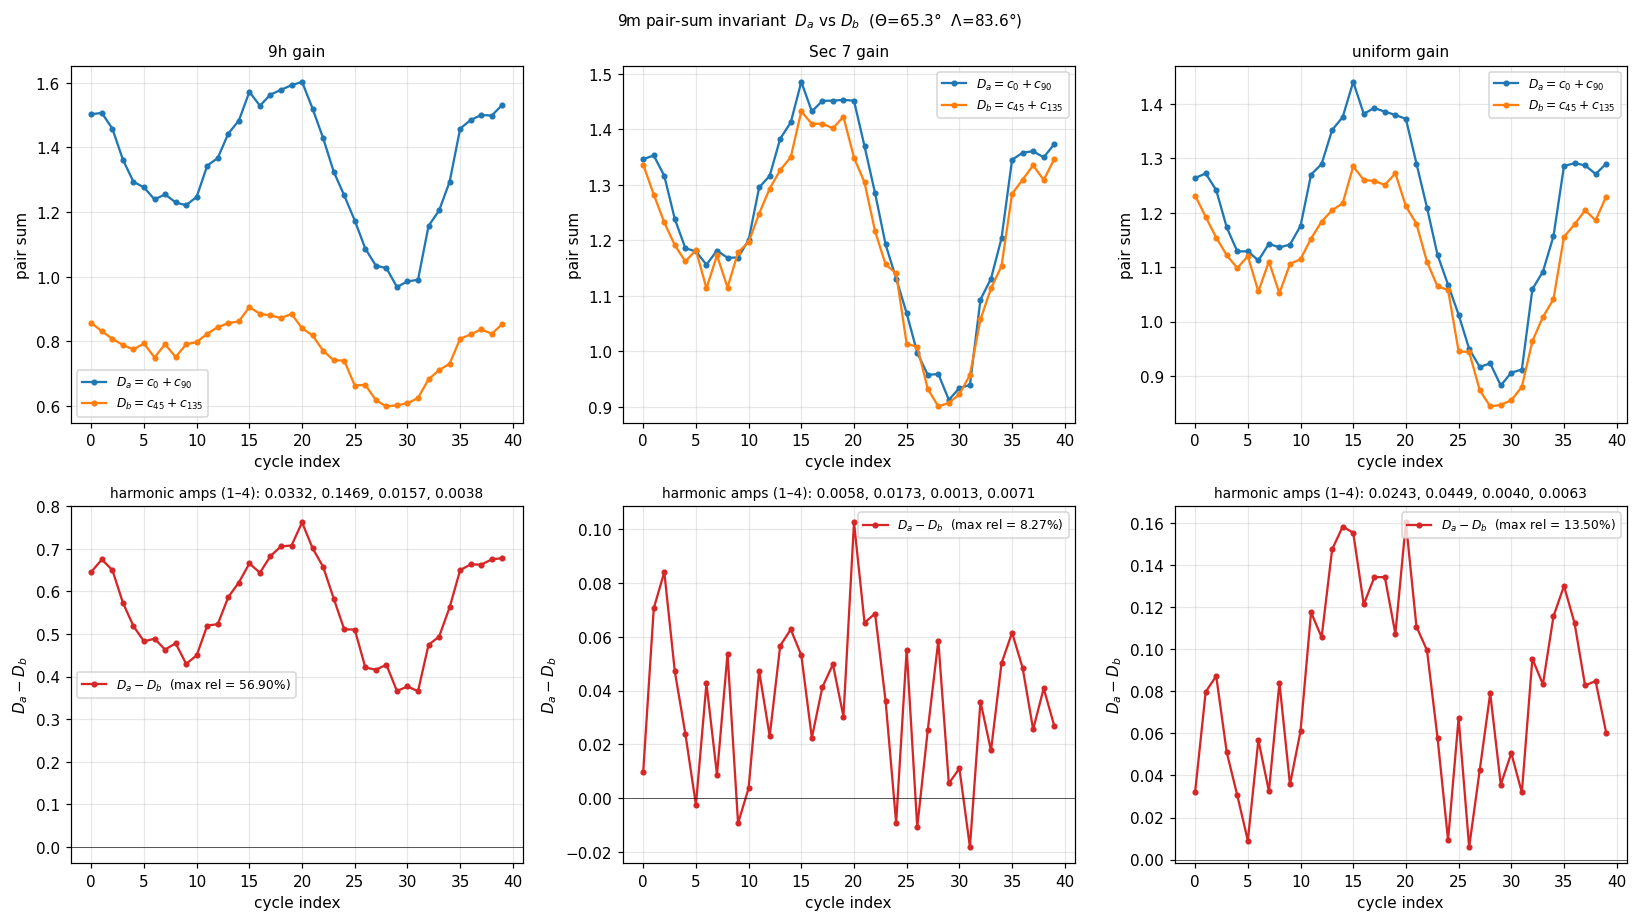

In [70]:
# ── Pair-sum invariant check: D_a vs D_b ────────────────────────────────────


def _pair_sums(gain_vec, label):
    g90, g45, g135 = gain_vec
    s = np.vstack((c90_fit, c45_fit, c135_fit, c0_fit)).astype(float).copy()
    s[0] *= g90; s[1] *= g45; s[2] *= g135
    cor = matcor @ s
    c0c   = cor[_idx_fit[0]]
    c90c  = cor[_idx_fit[1]]
    c45c  = cor[_idx_fit[2]]
    c135c = cor[_idx_fit[3]]
    Da = c0c + c90c
    Db = c45c + c135c
    return label, Da, Db


_pairs_results = [
    _pair_sums((a90_phase, a45_phase, a135_phase), '9h gain'),
    _pair_sums((a[0], a[1], a[2]),                  'Sec 7 gain'),
    _pair_sums((1.0, 1.0, 1.0),                     'uniform gain'),
]

# Print scalar summary
print(f"{'config':<18} {'<Da>':>9} {'<Db>':>9} {'<Da-Db>':>10} "
      f"{'std(Da-Db)':>12} {'max|Da-Db|':>12} {'rel diff %':>11}")
for _lbl, _Da, _Db in _pairs_results:
    _diff = _Da - _Db
    _rel = float(np.max(np.abs(_diff)) / max(np.mean(_Da), 1e-12) * 100)
    print(f"{_lbl:<18} {np.mean(_Da):>9.4f} {np.mean(_Db):>9.4f} "
          f"{np.mean(_diff):>+10.4f} {np.std(_diff):>12.5f} "
          f"{np.max(np.abs(_diff)):>12.5f} {_rel:>11.2f}")

# 2nd-harmonic content of (Da - Db) — fit a + b cos(2 ψ_idx 2π/N) + c sin(...)
def _harmonic_amps(y, n_harm=4):
    """Return amplitudes of harmonics 1..n_harm of cyclic signal y."""
    N = len(y); k = np.arange(N)
    out = []
    for h in range(1, n_harm + 1):
        cs = np.cos(2 * np.pi * h * k / N)
        sn = np.sin(2 * np.pi * h * k / N)
        a_ = 2 * np.mean(y * cs); b_ = 2 * np.mean(y * sn)
        out.append(np.hypot(a_, b_))
    return out


# ── Plot ─────────────────────────────────────────────────────────────────────
_fig_m, _axm = plt.subplots(2, 3, figsize=(15, 8.5), dpi=110)
_phase_idx = np.arange(N_SUBSAMPLE)

for _col, (_lbl, _Da, _Db) in enumerate(_pairs_results):
    # top: Da & Db overlaid
    _ax_t = _axm[0, _col]
    _ax_t.plot(_phase_idx, _Da, 'o-', ms=3, color='C0', label=r'$D_a = c_0 + c_{90}$')
    _ax_t.plot(_phase_idx, _Db, 'o-', ms=3, color='C1', label=r'$D_b = c_{45} + c_{135}$')
    _ax_t.set_xlabel('cycle index'); _ax_t.set_ylabel('pair sum')
    _ax_t.set_title(f"{_lbl}", fontsize=10)
    _ax_t.legend(fontsize=8); _ax_t.grid(alpha=0.3)

    # bottom: residual + harmonic decomposition
    _ax_b = _axm[1, _col]
    _diff = _Da - _Db
    _amps = _harmonic_amps(_diff, n_harm=4)
    _rel_max = np.max(np.abs(_diff)) / max(np.mean(_Da), 1e-12) * 100
    _ax_b.plot(_phase_idx, _diff, 'o-', ms=3, color='C3',
               label=fr'$D_a - D_b$  (max rel = {_rel_max:.2f}%)')
    _ax_b.axhline(0, color='k', lw=0.4)
    _ax_b.set_xlabel('cycle index'); _ax_b.set_ylabel(r'$D_a - D_b$')
    _ax_b.set_title(
        f"harmonic amps (1–4): " + ", ".join(f"{x:.4f}" for x in _amps),
        fontsize=9,
    )
    _ax_b.legend(fontsize=8); _ax_b.grid(alpha=0.3)

_fig_m.suptitle(
    f"9m pair-sum invariant  $D_a$ vs $D_b$"
    f"  (Θ={Theta_axis_phase:.1f}°  Λ={Lambda_phase:.1f}°)",
    fontsize=10,
)
plt.tight_layout()
plt.show()

## 9n. 9j regression revisited at Sec 7 gain (post-9m)

9m showed Sec 7 gain preserves the pair-sum invariant ($D_a − D_b$ residual:
1.8% std, harmonics evenly distributed at noise floor) while 9h gain breaks
it (3.6% std, 2nd harmonic = 0.038 dominating). Sec 7 is the correct gain
for downstream regression.

This cell reruns the 9j regression at **Sec 7 gain** with the 9h geometry
(geometry is gain-insensitive at first order in the phase-matched cost),
side-by-side with the original 9h-gain version. Two outcomes possible:

- **Ellipses collapse to lines, harmonic structure in residual disappears**
  → 9j was correct in form, just had wrong gain input. Recovered $\delta_a,
  \delta_b, \delta_c$ at Sec 7 gain are trustworthy bg estimates for this
  sample.
- **Ellipses persist** → there is genuine non-Fourkas physics or per-pair
  T-matrix imperfection beyond what Sec 7 gain corrects. The bg estimates
  remain unreliable from a single rod.

config                δa        δb     δc(a)     δc(b)    rms_a    rms_b  harm(LHS_a-pred_a) 1..4
9h gain          -0.0119   -0.0699   +0.2289   +0.2026   0.0319   0.0124  0.0305 0.0204 0.0124 0.0209
Sec 7 gain       +0.0550   -0.0282   +0.2008   +0.3113   0.0345   0.0233  0.0293 0.0335 0.0113 0.0126


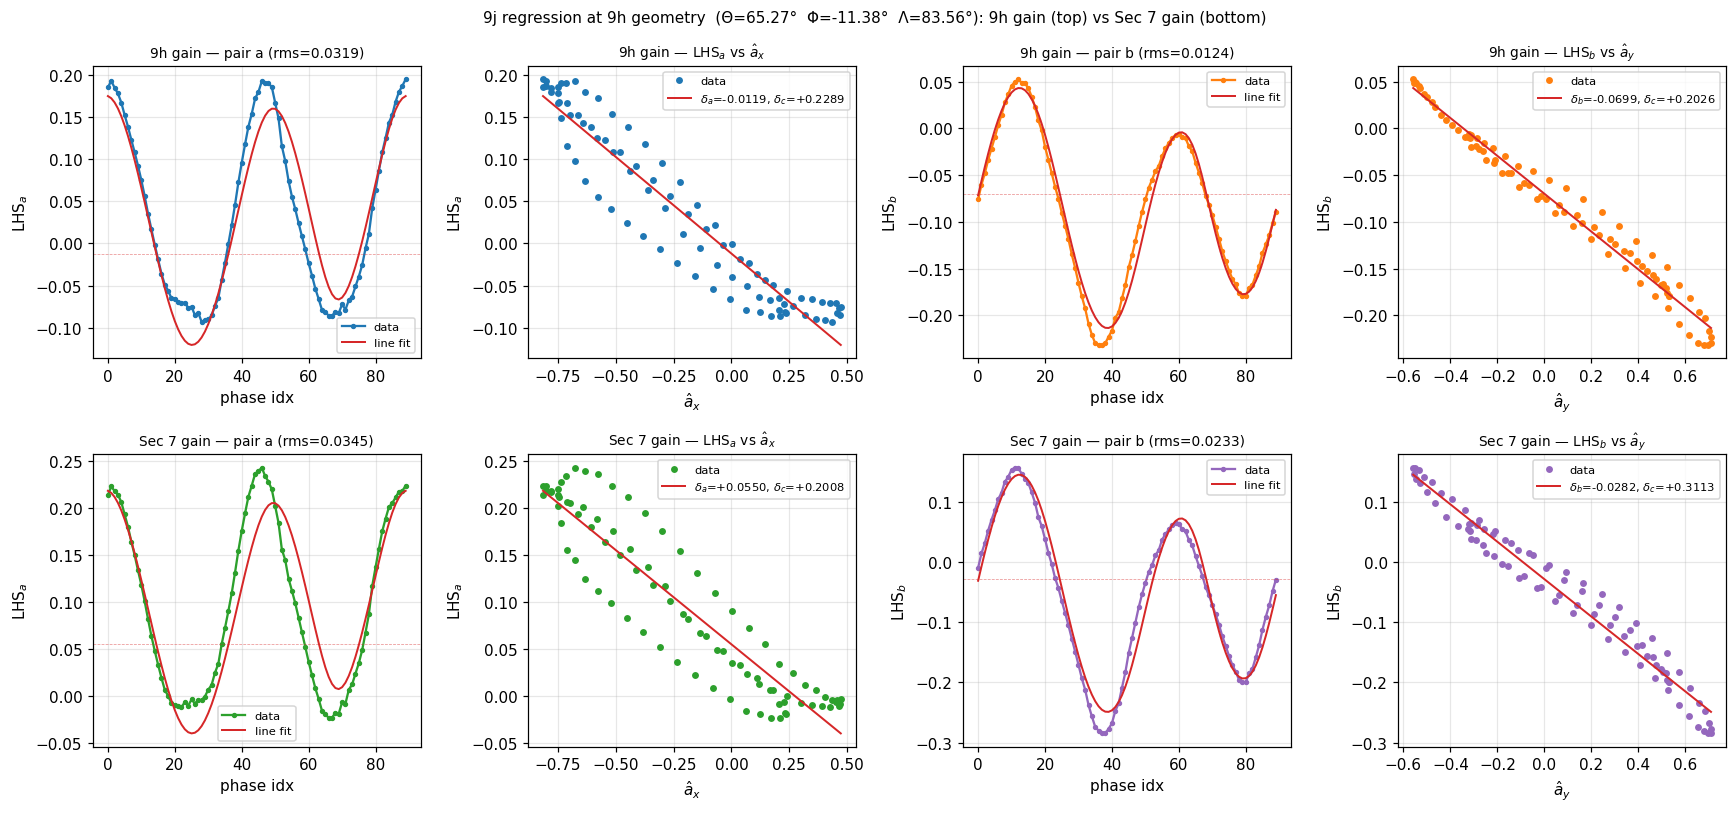


δc consistency (pair-a vs pair-b):
  9h gain:    δc_a=+0.22893, δc_b=+0.20256, diff=+0.02638
  Sec 7 gain: δc_a=+0.20079, δc_b=+0.31134, diff=-0.11054


In [71]:
# ── 9j regression: 9h gain vs Sec 7 gain, at 9h geometry ────────────────────
# Reuses _bg_regression() from cell 9j.

_geom_n = (Theta_axis_phase, Phi_axis_phase, Lambda_phase)
_res_9h  = _bg_regression((a90_phase, a45_phase, a135_phase), _geom_n,
                          "9h gain")
_res_s7  = _bg_regression((a[0], a[1], a[2]),                   _geom_n,
                          "Sec 7 gain")


def _harm_amps(y, n_harm=4):
    """Discrete harmonic amplitudes (1..n_harm) from N-pt cycle."""
    Y = np.fft.rfft(y)
    N = len(y)
    return [2.0 * np.abs(Y[k]) / N for k in range(1, n_harm + 1)]


print(f"{'config':<14} {'δa':>9} {'δb':>9} {'δc(a)':>9} {'δc(b)':>9} "
      f"{'rms_a':>8} {'rms_b':>8}  harm(LHS_a-pred_a) 1..4")
for _r in (_res_9h, _res_s7):
    _h = _harm_amps(_r['LHS_a'] - _r['pred_a'])
    print(f"{_r['label']:<14} {_r['delta_a']:>+9.4f} {_r['delta_b']:>+9.4f} "
          f"{_r['delta_c_a']:>+9.4f} {_r['delta_c_b']:>+9.4f} "
          f"{_r['rms_a']:>8.4f} {_r['rms_b']:>8.4f}  "
          + " ".join(f"{v:.4f}" for v in _h))

# ── Plot: 4 columns × 2 rows ────────────────────────────────────────────────
# columns: pair-a phase | pair-a vs â_x | pair-b phase | pair-b vs â_y
# rows:    9h gain      | Sec 7 gain
_fig_n, _axn = plt.subplots(2, 4, figsize=(16, 7.5), dpi=110)
_phase_idx = np.arange(N_REF_PHASE)

for _row, _r in enumerate((_res_9h, _res_s7)):
    _color_a = 'C0' if _row == 0 else 'C2'
    _color_b = 'C1' if _row == 0 else 'C4'

    # col 0: LHS_a vs phase
    _ax = _axn[_row, 0]
    _ax.plot(_phase_idx, _r['LHS_a'], 'o-', ms=2.5, color=_color_a, label='data')
    _ax.plot(_phase_idx, _r['pred_a'], '-', lw=1.3, color='C3', label='line fit')
    _ax.axhline(_r['delta_a'], color='C3', ls='--', lw=0.5, alpha=0.5)
    _ax.set_title(f"{_r['label']} — pair a (rms={_r['rms_a']:.4f})", fontsize=9)
    _ax.set_xlabel('phase idx'); _ax.set_ylabel('LHS$_a$')
    _ax.grid(alpha=0.3); _ax.legend(fontsize=7.5, loc='best')

    # col 1: LHS_a vs â_x — ellipse / line test
    _ax = _axn[_row, 1]
    _ax.plot(_r['rx_m'], _r['LHS_a'], 'o', ms=3.5, color=_color_a, label='data')
    _xx = np.linspace(_r['rx_m'].min(), _r['rx_m'].max(), 60)
    _ax.plot(_xx, _r['delta_a'] + (-_r['delta_c_a']) * _xx,
             '-', lw=1.3, color='C3',
             label=fr"$\delta_a$={_r['delta_a']:+.4f}, $\delta_c$={_r['delta_c_a']:+.4f}")
    _ax.set_title(f"{_r['label']} — LHS$_a$ vs $\\hat a_x$", fontsize=9)
    _ax.set_xlabel(r'$\hat a_x$'); _ax.set_ylabel('LHS$_a$')
    _ax.grid(alpha=0.3); _ax.legend(fontsize=7.5, loc='best')

    # col 2: LHS_b vs phase
    _ax = _axn[_row, 2]
    _ax.plot(_phase_idx, _r['LHS_b'], 'o-', ms=2.5, color=_color_b, label='data')
    _ax.plot(_phase_idx, _r['pred_b'], '-', lw=1.3, color='C3', label='line fit')
    _ax.axhline(_r['delta_b'], color='C3', ls='--', lw=0.5, alpha=0.5)
    _ax.set_title(f"{_r['label']} — pair b (rms={_r['rms_b']:.4f})", fontsize=9)
    _ax.set_xlabel('phase idx'); _ax.set_ylabel('LHS$_b$')
    _ax.grid(alpha=0.3); _ax.legend(fontsize=7.5, loc='best')

    # col 3: LHS_b vs â_y
    _ax = _axn[_row, 3]
    _ax.plot(_r['ry_m'], _r['LHS_b'], 'o', ms=3.5, color=_color_b, label='data')
    _yy = np.linspace(_r['ry_m'].min(), _r['ry_m'].max(), 60)
    _ax.plot(_yy, _r['delta_b'] + (-_r['delta_c_b']) * _yy,
             '-', lw=1.3, color='C3',
             label=fr"$\delta_b$={_r['delta_b']:+.4f}, $\delta_c$={_r['delta_c_b']:+.4f}")
    _ax.set_title(f"{_r['label']} — LHS$_b$ vs $\\hat a_y$", fontsize=9)
    _ax.set_xlabel(r'$\hat a_y$'); _ax.set_ylabel('LHS$_b$')
    _ax.grid(alpha=0.3); _ax.legend(fontsize=7.5, loc='best')

_fig_n.suptitle(
    f"9j regression at 9h geometry  (Θ={Theta_axis_phase:.2f}°  "
    f"Φ={Phi_axis_phase:.2f}°  Λ={Lambda_phase:.2f}°): "
    f"9h gain (top) vs Sec 7 gain (bottom)",
    fontsize=10,
)
plt.tight_layout()
plt.show()

print()
print(f"δc consistency (pair-a vs pair-b):")
print(f"  9h gain:    δc_a={_res_9h['delta_c_a']:+.5f}, "
      f"δc_b={_res_9h['delta_c_b']:+.5f}, "
      f"diff={_res_9h['delta_c_a']-_res_9h['delta_c_b']:+.5f}")
print(f"  Sec 7 gain: δc_a={_res_s7['delta_c_a']:+.5f}, "
      f"δc_b={_res_s7['delta_c_b']:+.5f}, "
      f"diff={_res_s7['delta_c_a']-_res_s7['delta_c_b']:+.5f}")

## 9o. Numerical T-matrix perturbation analysis

Direct test of hypothesis **H1** from the 9n analysis: is the
$\cos(2\psi)$ residual in pair-differences explained by a small
perturbation ε to `matcor`?

We have:
- The exact form of `matcor` (4×4 cross-coupling correction).
- A fitted geometry $(\Theta_\text{ax},\Phi_\text{ax},\Lambda)$ from 9h
  that determines the ideal Fourkas pattern.
- A gain estimate (Sec 7) that satisfies pair-sum invariance (9m).

We can therefore:

1. Build a **synthetic clean signal** $s_\text{clean}(\psi)$ in the
   matcor input space, such that `matcor @ s_clean` gives a perfect
   Fourkas anisotropy pattern at the fitted geometry.
2. Compute the **residual** $r(\psi) = c_\text{obs}(\psi) -
   \text{matcor}\,s_\text{clean}(\psi) - b$ where $b$ is a constant bg.
3. Fit a perturbation $\varepsilon \in \mathbb{R}^{4\times 4}$ to the
   model $r(\psi) = \varepsilon \, s_\text{clean}(\psi)$ in a row-wise
   linear regression (each row of $\varepsilon$ is 4 unknowns vs
   $N_\text{ref}=90$ phase points).

Diagnostic outputs:

- Heatmap of ε / ||matcor||_∞ — magnitude of required perturbation.
- $(matcor+\varepsilon) @ s_\text{clean}$ vs $c_\text{obs}$ comparison.
- Predicted vs observed 2nd-harmonic amplitude in $(c_0-c_{90})$ and
  $(c_{45}-c_{135})$.
- Frobenius norm $\|\varepsilon\|_F / \|\text{matcor}\|_F$. If $\lesssim
  10\%$, H1 is plausible: a calibration sample refit of `matcor` at this
  level would resolve the loop. If $\gtrsim 30\%$, the perturbation
  required is too large to be physical residual, and we have to look at
  H2/H3/H4 (wobble / nonlinearity / rotating bg).

Using gain (Sec 7): [1.08 1.16 1.02 1.  ]
Using geometry (9h):  Θ=65.27°  Φ=-11.38°  Λ=83.56°
Fourkas orientation: forward (cost=0.0210 vs reversed 0.4932)

matcor (current):
[[ 0.8446  0.      0.      0.    ]
 [-0.0167  0.8148 -0.0003  0.0163]
 [-0.0167 -0.0003  0.7976  0.0163]
 [ 0.      0.      0.      0.8224]]

fitted ε (perturbation that would explain residual):
[[-0.0822 -0.0357 -0.037   0.0172]
 [ 0.0052 -0.1122  0.1003 -0.0203]
 [-0.0205  0.0982 -0.1107  0.0123]
 [ 0.0974  0.0497  0.0475 -0.0092]]

‖ε‖_F = 0.2638    ‖matcor‖_F = 1.6404    ratio = 16.08%
max|ε| = 0.1122    max|matcor| = 0.8446    ratio = 13.29%

fitted bg (in cor stack space): [ 0.08121188 -0.00434603  0.02377751 -0.10064336]

‖ε_diag‖_F     = 0.1780
‖ε_off-diag‖_F = 0.1946

Harmonic amplitudes of (c0 - c90):  h1, h2, h3, h4
  observed:        [0.2458028  0.5844621  0.06305294 0.03537277]
  ideal Fourkas:   [0.25294554 0.69444927 0.07285264 0.04279354]
  with ε applied:  [0.24298009 0.58581953 0.05924206 0.03867

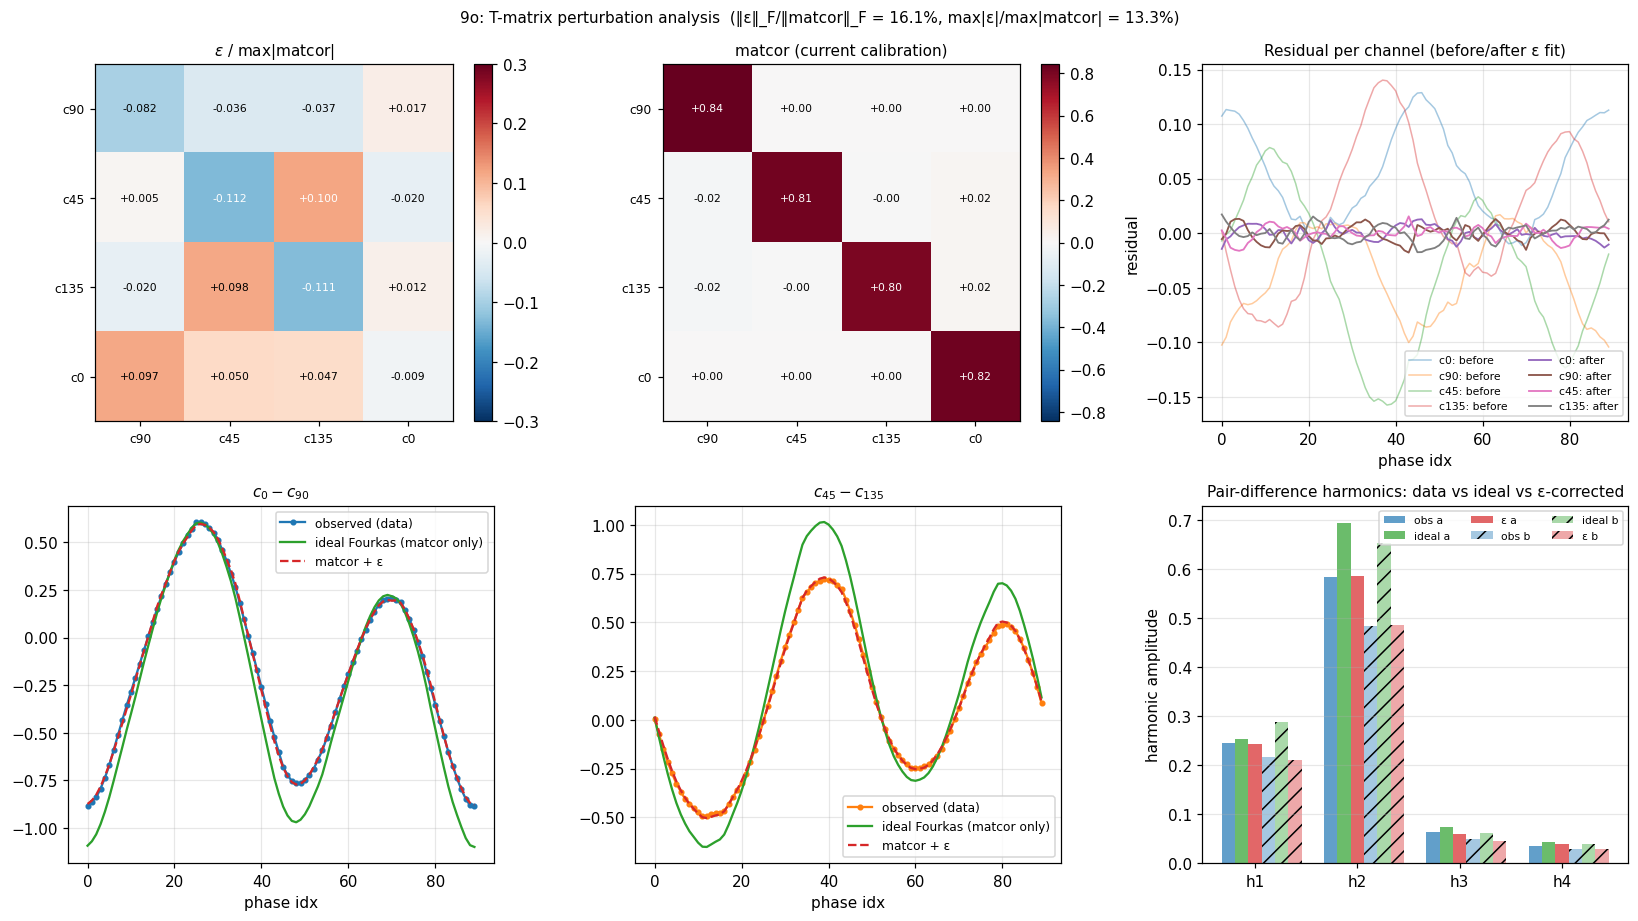

In [72]:
# ── 9o: numerical T-matrix perturbation analysis ──────────────────────────
# Tests H1: is the residual cos(2ψ) in pair-differences explained by a
# small perturbation ε to matcor?
#
# Pipeline (forward):
#   raw[stack k]  -- stack order = [c90, c45, c135, c0]
#   raw_g  = diag(gain) @ raw          (per-channel gain)
#   cor    = matcor @ raw_g            (cross-coupling correction)
#   c_obs[k]  = cor[_idx_fit[k]] + b_k  (k indexes (c0,c90,c45,c135))
#
# We build s_clean in *the matcor input space* (post-gain) such that
# matcor @ s_clean reproduces a pure Fourkas anisotropy at fitted geometry,
# with the observed mean intensity envelope D̄(ψ) = (D_a + D_b)/2.

# ── Choose configuration ────────────────────────────────────────────────────
_geom_o = (Theta_axis_phase, Phi_axis_phase, Lambda_phase)
_gain_o = np.array([a[0], a[1], a[2], 1.0])  # Sec 7 gain (90, 45, 135, 0)
print(f"Using gain (Sec 7): {_gain_o}")
print(f"Using geometry (9h):  Θ={_geom_o[0]:.2f}°  Φ={_geom_o[1]:.2f}°  Λ={_geom_o[2]:.2f}°")

# ── Reproduce the merged 40-pt observation cycle, resampled to N_REF_PHASE ──
# (same logic as in _bg_regression but we keep raw stack arrays too)
_s_raw = np.vstack((c90_fit, c45_fit, c135_fit, c0_fit)).astype(float)
_s_g   = _s_raw * _gain_o[:, None]      # gain applied
_cor   = matcor @ _s_g                   # 4 × N_SUBSAMPLE
_c_obs_40 = np.vstack([
    _cor[_idx_fit[0]],   # c0
    _cor[_idx_fit[1]],   # c90
    _cor[_idx_fit[2]],   # c45
    _cor[_idx_fit[3]],   # c135
])

# Resample to N_REF_PHASE points along closed cycle, using anisotropy arc-length
_diff_a = _c_obs_40[0] - _c_obs_40[1]
_sum_a  = _c_obs_40[0] + _c_obs_40[1]
_diff_b = _c_obs_40[2] - _c_obs_40[3]
_sum_b  = _c_obs_40[2] + _c_obs_40[3]
_axd    = _diff_a / _sum_a
_ayd    = _diff_b / _sum_b

def _resample_close_n(arrs, n_out):
    """Resample list of 1D closed-cycle arrays to n_out points
       parameterised by arc length on (axd, ayd)."""
    axc = np.concatenate([_axd, _axd[:1]])
    ayc = np.concatenate([_ayd, _ayd[:1]])
    seg = np.hypot(np.diff(axc), np.diff(ayc))
    s_arc = np.concatenate(([0.0], np.cumsum(seg)))
    L = float(s_arc[-1])
    t_grid = np.linspace(0.0, L, n_out, endpoint=False)
    out = []
    for arr in arrs:
        a_c = np.concatenate([arr, arr[:1]])
        out.append(np.interp(t_grid, s_arc, a_c))
    return out, t_grid

_arrs = [_c_obs_40[0], _c_obs_40[1], _c_obs_40[2], _c_obs_40[3]]
_resampled, _ = _resample_close_n(_arrs, N_REF_PHASE)
_c_obs = np.vstack(_resampled)   # (4, N_REF_PHASE), order (c0,c90,c45,c135)

# Anchor at min-ax_x as in 9j
_axd_r = (_c_obs[0] - _c_obs[1]) / (_c_obs[0] + _c_obs[1])
_k0 = int(np.argmin(_axd_r))
_c_obs = np.roll(_c_obs, -_k0, axis=1)
N = _c_obs.shape[1]

# ── Build pure Fourkas reference (ax, ay) at fitted geometry, resampled ──
_axm_full, _aym_full = fourkas_template(*_geom_o, A_cal, B_cal, C_cal,
                                        N_model=N_MODEL_PHASE)
# Match orientation/anchor to data
_xc = np.concatenate([_axm_full, _axm_full[:1]])
_yc = np.concatenate([_aym_full, _aym_full[:1]])
_seg = np.hypot(np.diff(_xc), np.diff(_yc))
_s_arc = np.concatenate(([0.0], np.cumsum(_seg)))
_Lm = float(_s_arc[-1])
_tg = np.linspace(0.0, _Lm, N, endpoint=False)
_ax_m = np.interp(_tg, _s_arc, _xc)
_ay_m = np.interp(_tg, _s_arc, _yc)
# forward vs reversed orientation
_ax_mF, _ay_mF = _ax_m, _ay_m
_xc2 = np.concatenate([_axm_full[::-1], _axm_full[::-1][:1]])
_yc2 = np.concatenate([_aym_full[::-1], _aym_full[::-1][:1]])
_seg2 = np.hypot(np.diff(_xc2), np.diff(_yc2))
_s2 = np.concatenate(([0.0], np.cumsum(_seg2)))
_ax_mR = np.interp(_tg, _s2, _xc2)
_ay_mR = np.interp(_tg, _s2, _yc2)
# pick the orientation closer to data
_axd_obs = (_c_obs[0] - _c_obs[1]) / (_c_obs[0] + _c_obs[1])
_ayd_obs = (_c_obs[2] - _c_obs[3]) / (_c_obs[2] + _c_obs[3])
def _anchor(x, y):
    k = int(np.argmin(x))
    return np.roll(x, -k), np.roll(y, -k)
_ax_mF, _ay_mF = _anchor(_ax_mF, _ay_mF)
_ax_mR, _ay_mR = _anchor(_ax_mR, _ay_mR)
_cF = np.mean((_axd_obs - _ax_mF)**2 + (_ayd_obs - _ay_mF)**2)
_cR = np.mean((_axd_obs - _ax_mR)**2 + (_ayd_obs - _ay_mR)**2)
if _cF <= _cR:
    _ax_ref, _ay_ref = _ax_mF, _ay_mF
    print(f"Fourkas orientation: forward (cost={_cF:.4f} vs reversed {_cR:.4f})")
else:
    _ax_ref, _ay_ref = _ax_mR, _ay_mR
    print(f"Fourkas orientation: reversed (cost={_cR:.4f} vs forward {_cF:.4f})")

# ── Build s_clean in matcor input space ─────────────────────────────────────
# Define D̄(ψ) from the observed pair-sum (this is the actual envelope —
# captures any I_tot variation that isn't 1st-harmonic Fourkas).
_D_obs = 0.5 * ((_c_obs[0] + _c_obs[1]) + (_c_obs[2] + _c_obs[3]))   # (N,)

# Ideal corrected stack at this envelope and pure Fourkas anisotropy:
#   ideal_(c0,  c90,  c45, c135) = D̄/2 * (1 ± a_x or a_y)
_ideal_corrected = np.vstack([
    0.5 * _D_obs * (1.0 + _ax_ref),     # ideal c0
    0.5 * _D_obs * (1.0 - _ax_ref),     # ideal c90
    0.5 * _D_obs * (1.0 + _ay_ref),     # ideal c45
    0.5 * _D_obs * (1.0 - _ay_ref),     # ideal c135
])
# Permute back to matcor output order (cor[_idx_fit[k]] = c_obs[k])
_inv_idx = np.argsort(_idx_fit)
_ideal_cor_stack = np.zeros_like(_ideal_corrected)
for k in range(4):
    _ideal_cor_stack[_idx_fit[k]] = _ideal_corrected[k]

# Invert matcor to get s_clean in input space
_s_clean = np.linalg.solve(matcor, _ideal_cor_stack)   # (4, N)

# ── Solve for ε given residual r = c_obs_corrected - ideal_corrected ───────
# The forward model with perturbation ε on matcor:
#    actual_cor_stack = (matcor + ε) @ s_clean + bg_in_cor_space
#    actual_cor_stack - matcor @ s_clean = ε @ s_clean + bg
#    residual_in_cor_stack = ε @ s_clean + bg
# Build observed corrected stack from _c_obs by inverse permutation
_obs_cor_stack = np.zeros_like(_c_obs)
for k in range(4):
    _obs_cor_stack[_idx_fit[k]] = _c_obs[k]
_residual = _obs_cor_stack - _ideal_cor_stack    # (4, N)

# Row-wise regression: residual[i, :] = ε[i, :] @ s_clean + b[i]
# Design matrix per row: X = [s_clean.T  |  1]   shape (N, 5)
_X = np.column_stack([_s_clean.T, np.ones(N)])    # (N, 5)
_eps = np.zeros((4, 4))
_b_in = np.zeros(4)
_resid_after = np.zeros((4, N))
for _i in range(4):
    _coef, *_ = np.linalg.lstsq(_X, _residual[_i], rcond=None)
    _eps[_i, :] = _coef[:4]
    _b_in[_i]   = _coef[4]
    _resid_after[_i] = _residual[_i] - _X @ _coef

# ── Diagnostics ─────────────────────────────────────────────────────────────
_eps_fro   = float(np.linalg.norm(_eps,   ord='fro'))
_matcor_fro= float(np.linalg.norm(matcor, ord='fro'))
_eps_inf   = float(np.max(np.abs(_eps)))
_matcor_inf= float(np.max(np.abs(matcor)))

print()
print("matcor (current):")
print(np.array2string(matcor, precision=4, suppress_small=True))
print(f"\nfitted ε (perturbation that would explain residual):")
print(np.array2string(_eps, precision=4, suppress_small=True))
print(f"\n‖ε‖_F = {_eps_fro:.4f}    ‖matcor‖_F = {_matcor_fro:.4f}    "
      f"ratio = {_eps_fro/_matcor_fro*100:.2f}%")
print(f"max|ε| = {_eps_inf:.4f}    max|matcor| = {_matcor_inf:.4f}    "
      f"ratio = {_eps_inf/_matcor_inf*100:.2f}%")
print(f"\nfitted bg (in cor stack space): {_b_in}")

# Off-diagonal vs diagonal magnitudes
_diag = np.diag(_eps)
_offd = _eps - np.diag(_diag)
print(f"\n‖ε_diag‖_F     = {np.linalg.norm(_diag):.4f}")
print(f"‖ε_off-diag‖_F = {np.linalg.norm(_offd):.4f}")

# ── Verify: does (matcor+ε) close the pair-difference loop? ────────────────
def _harm_amps(y, n_harm=4):
    Y = np.fft.rfft(y); N_ = len(y)
    return np.array([2.0 * np.abs(Y[k]) / N_ for k in range(1, n_harm + 1)])

_corrected_with_eps = (matcor + _eps) @ _s_clean + _b_in[:, None]   # cor stack
# Permute to (c0, c90, c45, c135)
_c_with_eps = np.vstack([_corrected_with_eps[_idx_fit[k]] for k in range(4)])

_pdiff_a_obs   = _c_obs[0]    - _c_obs[1]
_pdiff_b_obs   = _c_obs[2]    - _c_obs[3]
_pdiff_a_ideal = _ideal_corrected[0] - _ideal_corrected[1]
_pdiff_b_ideal = _ideal_corrected[2] - _ideal_corrected[3]
_pdiff_a_eps   = _c_with_eps[0] - _c_with_eps[1]
_pdiff_b_eps   = _c_with_eps[2] - _c_with_eps[3]

print(f"\nHarmonic amplitudes of (c0 - c90):  h1, h2, h3, h4")
print(f"  observed:        {_harm_amps(_pdiff_a_obs)}")
print(f"  ideal Fourkas:   {_harm_amps(_pdiff_a_ideal)}")
print(f"  with ε applied:  {_harm_amps(_pdiff_a_eps)}")
print(f"\nHarmonic amplitudes of (c45 - c135):")
print(f"  observed:        {_harm_amps(_pdiff_b_obs)}")
print(f"  ideal Fourkas:   {_harm_amps(_pdiff_b_ideal)}")
print(f"  with ε applied:  {_harm_amps(_pdiff_b_eps)}")

# ── Plot: ε heatmap, residual before/after, pair-difference comparison ────
_fig_o, _axo = plt.subplots(2, 3, figsize=(15, 8.5), dpi=110)

# ε heatmap (relative to max|matcor|)
_im = _axo[0, 0].imshow(_eps / _matcor_inf, cmap='RdBu_r',
                         vmin=-0.3, vmax=0.3, aspect='equal')
_axo[0, 0].set_title(r'$\varepsilon$ / max$|$matcor$|$', fontsize=10)
_axo[0, 0].set_xticks(range(4)); _axo[0, 0].set_yticks(range(4))
_axo[0, 0].set_xticklabels(['c90','c45','c135','c0'], fontsize=8)
_axo[0, 0].set_yticklabels(['c90','c45','c135','c0'], fontsize=8)
plt.colorbar(_im, ax=_axo[0, 0], fraction=0.046)
for ii in range(4):
    for jj in range(4):
        _axo[0, 0].text(jj, ii, f"{_eps[ii,jj]:+.3f}",
                         ha='center', va='center', fontsize=7,
                         color='white' if abs(_eps[ii,jj])>0.1 else 'black')

# matcor heatmap for reference
_im2 = _axo[0, 1].imshow(matcor, cmap='RdBu_r',
                          vmin=-_matcor_inf, vmax=_matcor_inf, aspect='equal')
_axo[0, 1].set_title('matcor (current calibration)', fontsize=10)
_axo[0, 1].set_xticks(range(4)); _axo[0, 1].set_yticks(range(4))
_axo[0, 1].set_xticklabels(['c90','c45','c135','c0'], fontsize=8)
_axo[0, 1].set_yticklabels(['c90','c45','c135','c0'], fontsize=8)
plt.colorbar(_im2, ax=_axo[0, 1], fraction=0.046)
for ii in range(4):
    for jj in range(4):
        _axo[0, 1].text(jj, ii, f"{matcor[ii,jj]:+.2f}",
                         ha='center', va='center', fontsize=7,
                         color='white' if abs(matcor[ii,jj])>0.5*_matcor_inf else 'black')

# residual before / after for each channel
_phase = np.arange(N)
_chan_lbl = ['c0','c90','c45','c135']
for _ch in range(4):
    _axo[0, 2].plot(_phase, _residual[_idx_fit[_ch]], '-', alpha=0.4, lw=1,
                    label=f"{_chan_lbl[_ch]}: before")
for _ch in range(4):
    _axo[0, 2].plot(_phase, _resid_after[_idx_fit[_ch]], '-', lw=1.2,
                    label=f"{_chan_lbl[_ch]}: after")
_axo[0, 2].set_title('Residual per channel (before/after ε fit)', fontsize=10)
_axo[0, 2].set_xlabel('phase idx'); _axo[0, 2].set_ylabel('residual')
_axo[0, 2].legend(fontsize=7, ncol=2); _axo[0, 2].grid(alpha=0.3)

# pair-difference a: observed, ideal, with ε
_axo[1, 0].plot(_phase, _pdiff_a_obs,  'o-', ms=3, color='C0',
                 label='observed (data)')
_axo[1, 0].plot(_phase, _pdiff_a_ideal,'-', lw=1.5, color='C2',
                 label='ideal Fourkas (matcor only)')
_axo[1, 0].plot(_phase, _pdiff_a_eps,  '--', lw=1.5, color='C3',
                 label='matcor + ε')
_axo[1, 0].set_title(r'$c_0 - c_{90}$', fontsize=10)
_axo[1, 0].set_xlabel('phase idx'); _axo[1, 0].grid(alpha=0.3)
_axo[1, 0].legend(fontsize=8)

# pair-difference b
_axo[1, 1].plot(_phase, _pdiff_b_obs,  'o-', ms=3, color='C1',
                 label='observed (data)')
_axo[1, 1].plot(_phase, _pdiff_b_ideal,'-', lw=1.5, color='C2',
                 label='ideal Fourkas (matcor only)')
_axo[1, 1].plot(_phase, _pdiff_b_eps,  '--', lw=1.5, color='C3',
                 label='matcor + ε')
_axo[1, 1].set_title(r'$c_{45} - c_{135}$', fontsize=10)
_axo[1, 1].set_xlabel('phase idx'); _axo[1, 1].grid(alpha=0.3)
_axo[1, 1].legend(fontsize=8)

# Harmonic bar chart
_h_obs_a = _harm_amps(_pdiff_a_obs)
_h_id_a  = _harm_amps(_pdiff_a_ideal)
_h_eps_a = _harm_amps(_pdiff_a_eps)
_h_obs_b = _harm_amps(_pdiff_b_obs)
_h_id_b  = _harm_amps(_pdiff_b_ideal)
_h_eps_b = _harm_amps(_pdiff_b_eps)
_w = 0.13
_x_pos = np.arange(4)
_axo[1, 2].bar(_x_pos - 2*_w, _h_obs_a, _w, label='obs a', color='C0', alpha=0.7)
_axo[1, 2].bar(_x_pos - 1*_w, _h_id_a,  _w, label='ideal a', color='C2', alpha=0.7)
_axo[1, 2].bar(_x_pos + 0*_w, _h_eps_a, _w, label='ε a', color='C3', alpha=0.7)
_axo[1, 2].bar(_x_pos + 1*_w, _h_obs_b, _w, label='obs b', color='C0',
                alpha=0.4, hatch='//')
_axo[1, 2].bar(_x_pos + 2*_w, _h_id_b,  _w, label='ideal b', color='C2',
                alpha=0.4, hatch='//')
_axo[1, 2].bar(_x_pos + 3*_w, _h_eps_b, _w, label='ε b', color='C3',
                alpha=0.4, hatch='//')
_axo[1, 2].set_xticks(_x_pos)
_axo[1, 2].set_xticklabels(['h1','h2','h3','h4'])
_axo[1, 2].set_ylabel('harmonic amplitude')
_axo[1, 2].set_title('Pair-difference harmonics: data vs ideal vs ε-corrected',
                      fontsize=10)
_axo[1, 2].legend(fontsize=7, ncol=3); _axo[1, 2].grid(alpha=0.3, axis='y')

_fig_o.suptitle(
    f"9o: T-matrix perturbation analysis  "
    f"(‖ε‖_F/‖matcor‖_F = {100*_eps_fro/_matcor_fro:.1f}%, "
    f"max|ε|/max|matcor| = {100*_eps_inf/_matcor_inf:.1f}%)",
    fontsize=10,
)
plt.tight_layout()
plt.show()

## 10. Processed-window phase processing

Applies fitted corrections to all decimated points in the selected time window and reconstructs a continuous rotation phase trace using KDTree mapping onto a uniformly sampled Fourkas template.

- `psi` is the tracked rotation-frame phase (continuous/unwrapped).
- `theta_lab` and `phi_lab` are lab-frame angles reconstructed from the matched template direction vectors.

Use these outputs for phase-aware downstream analysis and export.

### Trajectory-change guard

If `ENABLE_TRAJECTORY_GUARD = True`, the cell periodically checks the KDTree mismatch metric on a short window (`CHECK_WINDOW_S`) every `RECHECK_PERIOD_S`. When the metric exceeds `MISMATCH_TRIGGER_FACTOR × baseline_metric`, a **geometry-only** L-BFGS-B refit is launched (only `Theta_axis`, `Phi_axis`, `Lambda` are updated; the fitted backgrounds `b0/b90/b45/b135` and the Fourkas calibration `A_cal/B_cal/C_cal` are frozen). After each successful refit the baseline metric is reset on a 1 s window with the new geometry, and the trace is broken into a new segment so phase continuity is enforced across the boundary.

### Caveat: opinionated defaults

- `PHASE_PSI_SMOOTH = True` applies a Savitzky–Golay smoother to the *unwrapped* `psi` after KDTree tracking. This bleeds slightly across `phase_segment_ranges` boundaries; disable it if you need raw per-sample phase.
- `SPEED_ENFORCE_MONOTONIC_PSI = True` (Section 11 speed plot) projects `psi` to its running maximum before computing speed, so any backward rotation is suppressed. Set both to `False` if you expect or want to see reverse rotation.


In [73]:
# ══════════════════════════════════════════════════════════════════════════════
# PROCESSED WINDOW — phase mapping + optional trajectory-change guard
# ══════════════════════════════════════════════════════════════════════════════

# Processing window: this is the data that will be processed downstream.
data_t_start = 0     # s — processing window start (use None for full raw range)
data_t_end   = 100   # s — processing window end (use None for full raw range)

# Optional extra plotting sub-window within the processed data.
plot_t_start = None  # s — figure-only window start (None => no extra clipping)
plot_t_end   = None  # s — figure-only window end (None => no extra clipping)

# ── Mode controls ──────────────────────────────────────────────────────────────
# phase_guided: phase-matched angles + degeneracy-guided Fourkas angles
# direct_fourkas: direct Fourkas inversion only (phi unwrapped by pi, theta as-is)
ANGLE_RECONSTRUCTION_MODE = "phase_guided"  # "phase_guided" or "direct_fourkas"

# ── Trajectory-change guard (geometry refit; background fixed) ────────────────
ENABLE_TRAJECTORY_GUARD = True
CHECK_WINDOW_S = 1.0
RECHECK_PERIOD_S = 10.0
MISMATCH_TRIGGER_FACTOR = 3.0
GEOMETRY_REFIT_MIN_POINTS = 200

# ── Phase tracking controls ───────────────────────────────────────────────────
PHASE_DECIMATION = 10             # 250 kHz -> 25 kHz phase sampling
PHASE_KDTREE_N_MODEL = 360        # template points (uniform in rotation psi)
PHASE_KDTREE_K = 4                # nearest candidates queried per sample
PHASE_JUMP_PENALTY = 0.20         # penalize large phase jumps between samples
PHASE_SMOOTH_PENALTY = 0.05       # penalize acceleration in phase increments
PHASE_MAX_STEP_IDX = 18.0         # free jump range (model-index units)
PHASE_PSI_SMOOTH = True           # smooth tracked psi before using it
PHASE_PSI_SAVGOL_WINDOW = 61      # odd window, in decimated samples
PHASE_PSI_SAVGOL_POLY = 2

from scipy.spatial import cKDTree
from scipy.optimize import minimize

if ANGLE_RECONSTRUCTION_MODE not in ("phase_guided", "direct_fourkas"):
    raise ValueError("ANGLE_RECONSTRUCTION_MODE must be 'phase_guided' or 'direct_fourkas'.")

# Apply a and T matrix to full raw timeline
raw_stack = np.vstack((c90_raw, c45_raw, c135_raw, c0_raw)).astype(float)
for i in range(4):
    raw_stack[i] = a[i] * raw_stack[i]
tcor_stack = np.dot(matcor, raw_stack)
del raw_stack

# Subtract fitted per-channel backgrounds
c0   = tcor_stack[_idx_fit[0]] - b0_fitted
c90  = tcor_stack[_idx_fit[1]] - b90_fitted
c45  = tcor_stack[_idx_fit[2]] - b45_fitted
c135 = tcor_stack[_idx_fit[3]] - b135_fitted

# Keep pre-subtraction channels for background/signal diagnostics
c0_nocor   = tcor_stack[_idx_fit[0]]
c90_nocor  = tcor_stack[_idx_fit[1]]
c45_nocor  = tcor_stack[_idx_fit[2]]
c135_nocor = tcor_stack[_idx_fit[3]]

# ── Apply processing mask early (this data is what gets processed) ────────────
_process_mask = np.ones(len(time_s), dtype=bool)
if data_t_start is not None:
    _process_mask &= time_s >= data_t_start
if data_t_end is not None:
    _process_mask &= time_s <= data_t_end
if not np.any(_process_mask):
    raise RuntimeError("Processing window is empty. Adjust data_t_start / data_t_end.")

time_proc = time_s[_process_mask]
c0 = c0[_process_mask]
c90 = c90[_process_mask]
c45 = c45[_process_mask]
c135 = c135[_process_mask]
c0_nocor = c0_nocor[_process_mask]
c90_nocor = c90_nocor[_process_mask]
c45_nocor = c45_nocor[_process_mask]
c135_nocor = c135_nocor[_process_mask]

# Full-resolution anisotropy (used by pre/post comparison cell)
anis_x, anis_y = anisotropy_from_channels(c0, c90, c45, c135)
anis_x_nocor, anis_y_nocor = anisotropy_from_channels(c0_nocor, c90_nocor, c45_nocor, c135_nocor)

# Decimated points for phase tracking and angle reconstruction
_D = int(max(1, PHASE_DECIMATION))
_time_phase = time_proc[::_D]
_ax_phase = anis_x[::_D]
_ay_phase = anis_y[::_D]
_data_pts = np.column_stack([_ax_phase, _ay_phase])

# ── Helpers for mismatch + geometry-only refit ───────────────────────────────
def _window_metric(theta_deg, phi_deg, lam_deg, ax_w, ay_w, A, B, C, n_model=360):
    if len(ax_w) < 4:
        return np.nan
    ax_m, ay_m = fourkas_template(theta_deg, phi_deg, lam_deg, A, B, C, N_model=int(max(60, n_model)))
    tree = cKDTree(np.column_stack([ax_m, ay_m]))
    d, _ = tree.query(np.column_stack([ax_w, ay_w]), k=1)
    return float(np.mean(d * d))

def _fit_geometry_only(theta0, phi0, lam0, ax_w, ay_w, A, B, C, n_model=360):
    if len(ax_w) < GEOMETRY_REFIT_MIN_POINTS:
        return theta0, phi0, lam0, np.nan, False

    def _cost(p):
        th, ph, lm = p
        return _window_metric(th, ph, lm, ax_w, ay_w, A, B, C, n_model=n_model)

    res = minimize(
        _cost,
        x0=np.array([theta0, phi0, lam0], dtype=float),
        bounds=[(0.0, 90.0), (-180.0, 180.0), (0.0, 90.0)],
        method="L-BFGS-B",
    )
    if not res.success:
        return theta0, phi0, lam0, np.nan, False
    return float(res.x[0]), float(res.x[1]), float(res.x[2]), float(res.fun), True

# ── Build geometry segments using periodic guard checks ───────────────────────
_M = len(_time_phase)
phase_segment_ranges = []
phase_segment_params = []
phase_refit_events = []

_theta0 = float(Theta_axis_fitted)
_phi0 = float(Phi_axis_fitted)
_lam0 = float(Lambda_fitted)

if (_M < 5) or (not ENABLE_TRAJECTORY_GUARD):
    phase_segment_ranges = [(0, _M)]
    phase_segment_params = [(_theta0, _phi0, _lam0)]
    _baseline_metric = np.nan
else:
    _i_base_s = 0
    _i_base_e = int(np.searchsorted(_time_phase, _time_phase[0] + CHECK_WINDOW_S, side="left"))
    _i_base_e = max(_i_base_e, min(_M, _i_base_s + 5))

    _baseline_metric = _window_metric(
        _theta0, _phi0, _lam0,
        _ax_phase[_i_base_s:_i_base_e], _ay_phase[_i_base_s:_i_base_e],
        A_cal, B_cal, C_cal, n_model=PHASE_KDTREE_N_MODEL,
    )

    _breaks = [0]
    _params = [(_theta0, _phi0, _lam0)]
    _cur_theta, _cur_phi, _cur_lam = _theta0, _phi0, _lam0

    if np.isfinite(_baseline_metric) and _baseline_metric > 0:
        _t_check = float(_time_phase[0] + RECHECK_PERIOD_S)
        _t_end = float(_time_phase[-1])
        while _t_check < _t_end:
            _iw_s = int(np.searchsorted(_time_phase, _t_check, side="left"))
            _iw_e = int(np.searchsorted(_time_phase, _t_check + CHECK_WINDOW_S, side="left"))
            _iw_e = min(_M, max(_iw_e, _iw_s + 5))

            if _iw_s >= _M - 5:
                break

            _metric = _window_metric(
                _cur_theta, _cur_phi, _cur_lam,
                _ax_phase[_iw_s:_iw_e], _ay_phase[_iw_s:_iw_e],
                A_cal, B_cal, C_cal, n_model=PHASE_KDTREE_N_MODEL,
            )

            if np.isfinite(_metric) and (_metric > MISMATCH_TRIGGER_FACTOR * _baseline_metric):
                _new_theta, _new_phi, _new_lam, _new_cost, _ok = _fit_geometry_only(
                    _cur_theta, _cur_phi, _cur_lam,
                    _ax_phase[_iw_s:_iw_e], _ay_phase[_iw_s:_iw_e],
                    A_cal, B_cal, C_cal, n_model=PHASE_KDTREE_N_MODEL,
                )
                if _ok:
                    if _iw_s > _breaks[-1] + 2:
                        _breaks.append(_iw_s)
                        _params.append((_new_theta, _new_phi, _new_lam))
                    phase_refit_events.append({
                        "t": float(_time_phase[_iw_s]),
                        "idx": int(_iw_s),
                        "metric_before": float(_metric),
                        "baseline_metric_before": float(_baseline_metric),
                        "theta_old": float(_cur_theta),
                        "phi_old": float(_cur_phi),
                        "lam_old": float(_cur_lam),
                        "theta_new": float(_new_theta),
                        "phi_new": float(_new_phi),
                        "lam_new": float(_new_lam),
                        "fit_cost": float(_new_cost),
                    })

                    # Reset baseline using a 1 s window on the new geometry right after refit.
                    _rb_s = _iw_s
                    _rb_e = int(np.searchsorted(_time_phase, _time_phase[_rb_s] + CHECK_WINDOW_S, side="left"))
                    _rb_e = min(_M, max(_rb_e, _rb_s + 5))
                    _baseline_new = _window_metric(
                        _new_theta, _new_phi, _new_lam,
                        _ax_phase[_rb_s:_rb_e], _ay_phase[_rb_s:_rb_e],
                        A_cal, B_cal, C_cal, n_model=PHASE_KDTREE_N_MODEL,
                    )
                    if np.isfinite(_baseline_new) and (_baseline_new > 0):
                        _baseline_metric = float(_baseline_new)
                    _cur_theta, _cur_phi, _cur_lam = _new_theta, _new_phi, _new_lam

            _t_check += RECHECK_PERIOD_S

    _breaks.append(_M)
    for _si in range(len(_params)):
        phase_segment_ranges.append((_breaks[_si], _breaks[_si + 1]))
        phase_segment_params.append(_params[_si])

# ── Segment-wise KD mapping with phase continuity alignment ────────────────────
_N = int(max(60, PHASE_KDTREE_N_MODEL))
_K = int(max(1, min(PHASE_KDTREE_K, _N)))

_idx_path = np.empty(_M, dtype=int)
_cum_idx = np.empty(_M, dtype=float)
_step_idx = np.empty(_M, dtype=float)
psi = np.empty(_M, dtype=float)
theta_axis_used = np.empty(_M, dtype=float)
phi_axis_used = np.empty(_M, dtype=float)
lambda_used = np.empty(_M, dtype=float)

def _build_model(theta_deg, phi_deg, lam_deg, n_model):
    ax_m, ay_m = fourkas_template(theta_deg, phi_deg, lam_deg, A_cal, B_cal, C_cal, N_model=n_model)
    return np.column_stack([ax_m, ay_m])

_prev_delta = 0.0
for (_s, _e), (_th_seg, _ph_seg, _lam_seg) in zip(phase_segment_ranges, phase_segment_params):
    if _e - _s <= 0:
        continue

    theta_axis_used[_s:_e] = _th_seg
    phi_axis_used[_s:_e] = _ph_seg
    lambda_used[_s:_e] = _lam_seg

    _model_pts = _build_model(_th_seg, _ph_seg, _lam_seg, _N)
    _tree = cKDTree(_model_pts)
    _dist_seg, _cand_seg = _tree.query(_data_pts[_s:_e], k=_K)
    if _K == 1:
        _dist_seg = _dist_seg[:, None]
        _cand_seg = _cand_seg[:, None]

    for _ii in range(_e - _s):
        _g = _s + _ii
        _cand_i = _cand_seg[_ii].astype(int)
        _dist_i = _dist_seg[_ii].astype(float)

        if _g == 0:
            _j = int(np.argmin(_dist_i))
            _idx_path[_g] = int(_cand_i[_j])
            _cum_idx[_g] = float(_idx_path[_g])
            _step_idx[_g] = 0.0
            psi[_g] = (2.0 * np.pi / _N) * _cum_idx[_g]
            _prev_delta = 0.0
            continue

        if _ii == 0:
            # Segment boundary continuity: choose the candidate branch closest to previous psi.
            _prev_psi = psi[_g - 1]
            _psi_cand = (2.0 * np.pi / _N) * _cand_i.astype(float)
            _psi_aligned = _psi_cand + 2.0 * np.pi * np.round((_prev_psi - _psi_cand) / (2.0 * np.pi))
            _step_idx_cand = (_psi_aligned - _prev_psi) * (_N / (2.0 * np.pi))
            _score = (
                _dist_i
                + PHASE_JUMP_PENALTY * np.maximum(0.0, np.abs(_step_idx_cand) - PHASE_MAX_STEP_IDX)
                + PHASE_SMOOTH_PENALTY * np.abs(_step_idx_cand - _prev_delta)
            )
            _j = int(np.argmin(_score))
            _idx_path[_g] = int(_cand_i[_j])
            _step_idx[_g] = float(_step_idx_cand[_j])
            _cum_idx[_g] = _cum_idx[_g - 1] + _step_idx[_g]
            psi[_g] = (2.0 * np.pi / _N) * _cum_idx[_g]
            _prev_delta = _step_idx[_g]
            continue

        _prev_idx = _idx_path[_g - 1]
        _delta = ((_cand_i - _prev_idx + _N / 2.0) % _N) - _N / 2.0
        _score = (
            _dist_i
            + PHASE_JUMP_PENALTY * np.maximum(0.0, np.abs(_delta) - PHASE_MAX_STEP_IDX)
            + PHASE_SMOOTH_PENALTY * np.abs(_delta - _prev_delta)
        )
        _j = int(np.argmin(_score))
        _idx_path[_g] = int(_cand_i[_j])
        _step_idx[_g] = float(_delta[_j])
        _cum_idx[_g] = _cum_idx[_g - 1] + _step_idx[_g]
        psi[_g] = (2.0 * np.pi / _N) * _cum_idx[_g]
        _prev_delta = _step_idx[_g]

if PHASE_PSI_SMOOTH and len(psi) >= 7:
    _w = int(max(7, PHASE_PSI_SAVGOL_WINDOW))
    if _w % 2 == 0:
        _w += 1
    _w = min(_w, len(psi) - (1 - len(psi) % 2))
    if _w >= 7 and _w > PHASE_PSI_SAVGOL_POLY:
        psi = savgol_filter(psi, _w, int(PHASE_PSI_SAVGOL_POLY), mode="interp")

# ── Phase-reference lab angles from per-segment geometry + psi ───────────────
theta_lab_phase = np.empty(_M, dtype=float)
phi_lab_phase = np.empty(_M, dtype=float)

def _basis_from_axis(theta_deg, phi_deg):
    th = np.radians(theta_deg)
    ph = np.radians(phi_deg)
    kx = np.sin(th) * np.cos(ph)
    ky = np.sin(th) * np.sin(ph)
    kz = np.cos(th)
    khat = np.array([kx, ky, kz])
    if abs(kz) < 0.9999:
        e1 = np.array([0.0, 0.0, 1.0]) - kz * khat
        e1 /= np.linalg.norm(e1)
    else:
        e1 = np.array([1.0, 0.0, 0.0])
    e2 = np.cross(khat, e1)
    return khat, e1, e2

for (_s, _e), (_th_seg, _ph_seg, _lam_seg) in zip(phase_segment_ranges, phase_segment_params):
    if _e - _s <= 0:
        continue
    _khat, _e1, _e2 = _basis_from_axis(_th_seg, _ph_seg)
    _psi_seg = psi[_s:_e]
    _lam_seg_rad = np.radians(_lam_seg)
    _d_seg = (
        np.cos(_lam_seg_rad) * _khat[None, :]
        + np.sin(_lam_seg_rad) * (np.cos(_psi_seg)[:, None] * _e1[None, :] + np.sin(_psi_seg)[:, None] * _e2[None, :])
    )
    theta_lab_phase[_s:_e] = np.degrees(np.arccos(np.clip(_d_seg[:, 2], -1.0, 1.0)))
    phi_lab_phase[_s:_e] = np.arctan2(_d_seg[:, 1], _d_seg[:, 0])
phi_lab_phase = np.unwrap(phi_lab_phase)

# ── Direct Fourkas inversion from anisotropy ──────────────────────────────────
_r_phase = np.hypot(_ax_phase, _ay_phase)
_den_phase = C_cal - B_cal * _r_phase
_s2_phase = np.full_like(_r_phase, np.nan, dtype=float)
_valid_s2 = np.abs(_den_phase) > 1e-12
_s2_phase[_valid_s2] = (A_cal * _r_phase[_valid_s2]) / _den_phase[_valid_s2]
_s2_phase = np.clip(_s2_phase, 0.0, 1.0)
theta_lab_direct = np.degrees(np.arcsin(np.sqrt(_s2_phase)))
phi_lab_direct = 0.5 * np.unwrap(np.arctan2(_ay_phase, _ax_phase))

# Guided degeneracy resolution using phase-reference angles
_phi_base = 0.5 * np.arctan2(_ay_phase, _ax_phase)
_phi_alt = _phi_base + np.pi
_dphi_base = np.abs(np.angle(np.exp(1j * (_phi_base - phi_lab_phase))))
_dphi_alt = np.abs(np.angle(np.exp(1j * (_phi_alt - phi_lab_phase))))
_use_alt_phi = _dphi_alt < _dphi_base
phi_lab_guided = np.where(_use_alt_phi, _phi_alt, _phi_base)
phi_lab_guided = np.unwrap(phi_lab_guided)

_theta_alt = 180.0 - theta_lab_direct
_dth_base = np.abs(theta_lab_direct - theta_lab_phase)
_dth_alt = np.abs(_theta_alt - theta_lab_phase)
theta_lab_guided = np.where(_dth_alt < _dth_base, _theta_alt, theta_lab_direct)

# Select active outputs by mode
if ANGLE_RECONSTRUCTION_MODE == "phase_guided":
    theta_lab = theta_lab_phase
    phi_lab = phi_lab_phase
else:
    theta_lab = theta_lab_direct
    phi_lab = phi_lab_direct

# Mask for section-11 figures (on processed timeline)
_mask = np.ones(len(time_proc), dtype=bool)
if plot_t_start is not None:
    _mask &= time_proc >= plot_t_start
if plot_t_end is not None:
    _mask &= time_proc <= plot_t_end

# ── Background-to-signal diagnostics ──────────────────────────────────────────
# representative ratio = |b|/median(c), range = [|b|/max(c), |b|/min(c)] over positive c
def _bg_ratio_stats(b_val, c_arr):
    c_pos = c_arr[c_arr > 0]
    if len(c_pos) == 0:
        return {"representative": None, "range": [None, None]}
    r_rep = abs(b_val) / float(np.median(c_pos))
    r_min = abs(b_val) / float(np.max(c_pos))
    r_max = abs(b_val) / float(np.min(c_pos))
    return {"representative": r_rep, "range": [r_min, r_max]}

_bg_ratio_c0 = _bg_ratio_stats(b0_fitted, c0_nocor)
_bg_ratio_c90 = _bg_ratio_stats(b90_fitted, c90_nocor)
_bg_ratio_c45 = _bg_ratio_stats(b45_fitted, c45_nocor)
_bg_ratio_c135 = _bg_ratio_stats(b135_fitted, c135_nocor)

print(f"Raw points available: {len(time_s):,}")
print(f"Processed points after window: {len(time_proc):,} (window={data_t_start}..{data_t_end} s)")
print(f"Phase-tracking points used: {len(_time_phase):,} (decimation={_D}x, fs_eff={freq/_D:.1f} Hz)")
print(f"Template phase points (one turn): {_N}")
print(f"Generated phase samples: {len(psi):,}")
print(f"psi (rotation-frame): min={np.nanmin(psi):.4f}  max={np.nanmax(psi):.4f} rad")
print(f"ANGLE_RECONSTRUCTION_MODE={ANGLE_RECONSTRUCTION_MODE}")
print(f"theta_lab (active): min={np.nanmin(theta_lab):.2f} deg  mean={np.nanmean(theta_lab):.2f} deg  max={np.nanmax(theta_lab):.2f} deg")
print(f"phi_lab (active): min={np.nanmin(phi_lab):.4f}  max={np.nanmax(phi_lab):.4f} rad")
print(f"Trajectory guard: {'ON' if ENABLE_TRAJECTORY_GUARD else 'OFF'}")
if ENABLE_TRAJECTORY_GUARD:
    print(f"  baseline mismatch metric={_baseline_metric:.6g}")
    print(f"  trigger factor={MISMATCH_TRIGGER_FACTOR:.3f}, check_window={CHECK_WINDOW_S}s, recheck_period={RECHECK_PERIOD_S}s")
    print(f"  geometry segments={len(phase_segment_ranges)}  refits={len(phase_refit_events)}")
    if len(phase_refit_events) > 0:
        for _ev in phase_refit_events:
            print(
                f"    refit @ t={_ev['t']:.3f}s | metric={_ev['metric_before']:.6g} "
                f"({(_ev['metric_before']/_ev['baseline_metric_before']):.2f}x baseline) | "
                f"Theta: {_ev['theta_old']:.2f}->{_ev['theta_new']:.2f}, "
                f"Phi: {_ev['phi_old']:.2f}->{_ev['phi_new']:.2f}, "
                f"Lambda: {_ev['lam_old']:.2f}->{_ev['lam_new']:.2f}"
            )
        print("  NOTE: baseline is reset after each successful refit on a new 1 s window.")
if ANGLE_RECONSTRUCTION_MODE == "phase_guided":
    print("Additional traces available: theta_lab_guided, phi_lab_guided, theta_lab_direct, phi_lab_direct")
print("Background/signal ratios:")
print("  representative = |b|/median(c), range = [|b|/max(c), |b|/min(c)")
print(f"  c0:   rep={_bg_ratio_c0['representative']:.5f}  range={_bg_ratio_c0['range']}")
print(f"  c90:  rep={_bg_ratio_c90['representative']:.5f}  range={_bg_ratio_c90['range']}")
print(f"  c45:  rep={_bg_ratio_c45['representative']:.5f}  range={_bg_ratio_c45['range']}")
print(f"  c135: rep={_bg_ratio_c135['representative']:.5f}  range={_bg_ratio_c135['range']}")

Raw points available: 59,970,000
Processed points after window: 25,000,001 (window=0..100 s)
Phase-tracking points used: 2,500,001 (decimation=10x, fs_eff=25000.0 Hz)
Template phase points (one turn): 360
Generated phase samples: 2,500,001
psi (rotation-frame): min=3.2785  max=64282.8926 rad
ANGLE_RECONSTRUCTION_MODE=phase_guided
theta_lab (active): min=14.12 deg  mean=85.91 deg  max=152.81 deg
phi_lab (active): min=-3.0067  max=64275.8006 rad
Trajectory guard: ON
  baseline mismatch metric=0.00293
  trigger factor=3.000, check_window=1.0s, recheck_period=10.0s
  geometry segments=1  refits=0
Additional traces available: theta_lab_guided, phi_lab_guided, theta_lab_direct, phi_lab_direct
Background/signal ratios:
  representative = |b|/median(c), range = [|b|/max(c), |b|/min(c)
  c0:   rep=0.25400  range=[0.11192469667810882, 0.6667854270185207]
  c90:  rep=0.03265  range=[0.016841992723377372, 0.08185225364708139]
  c45:  rep=0.08846  range=[0.04594385793116909, 0.21694866564438794]
  

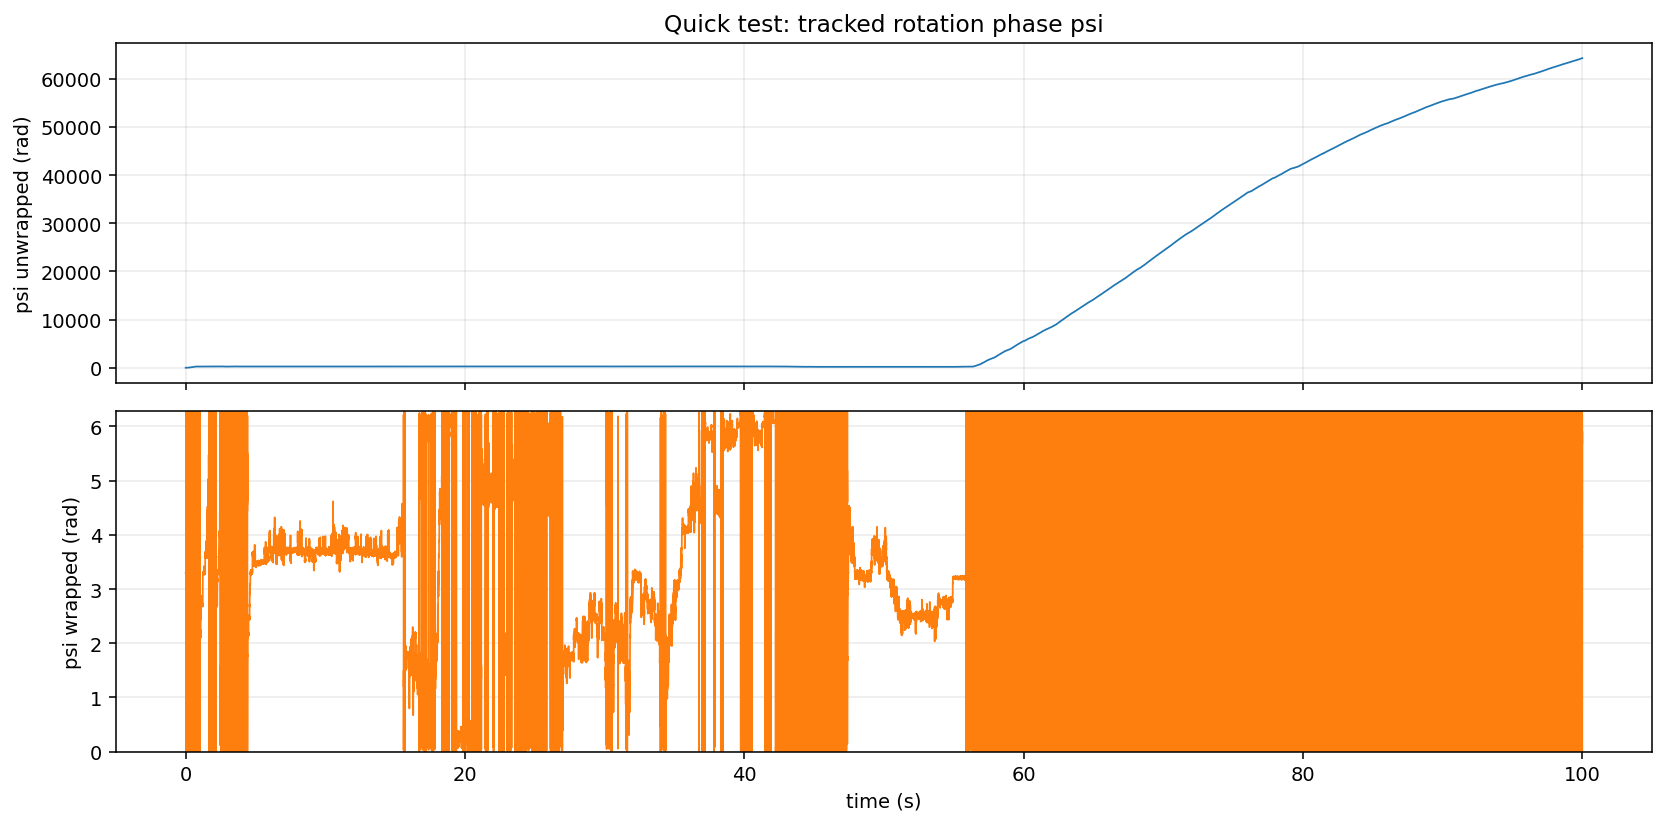

Test window: TEST_T_START=0.0, TEST_T_END=500
Plotted 2,500,001 points from t=0.000s to t=100.000s
Run the next cell to use the same window for phi_lab/theta_lab.


In [74]:
# ── Quick test plot: psi in test window (unwrapped + wrapped) ─────────────────
# Single source of truth: edit only these two lines, then run this cell
TEST_T_START = 0.0   # seconds; use None for start of trace
TEST_T_END = 500     # seconds; use None for end of trace

_mask_test = np.ones(len(_time_phase), dtype=bool)
if TEST_T_START is not None:
    _mask_test &= _time_phase >= TEST_T_START
if TEST_T_END is not None:
    _mask_test &= _time_phase <= TEST_T_END

t_test = _time_phase[_mask_test]
psi_test = psi[_mask_test]

if len(t_test) == 0:
    print("No points in selected test window for psi plot.")
else:
    psi_test_wrapped = np.mod(psi_test, 2.0 * np.pi)

    fig, (ax_u, ax_w) = plt.subplots(2, 1, figsize=(12, 6), dpi=140, sharex=True)
    ax_u.plot(t_test, psi_test, lw=0.9, color="tab:blue")
    ax_u.set_ylabel("psi unwrapped (rad)")
    ax_u.grid(alpha=0.25)
    ax_u.set_title("Quick test: tracked rotation phase psi")

    ax_w.plot(t_test, psi_test_wrapped, lw=0.9, color="tab:orange")
    ax_w.set_xlabel("time (s)")
    ax_w.set_ylabel("psi wrapped (rad)")
    ax_w.set_ylim(0.0, 2.0 * np.pi)
    ax_w.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    print(f"Test window: TEST_T_START={TEST_T_START}, TEST_T_END={TEST_T_END}")
    print(f"Plotted {len(t_test):,} points from t={t_test[0]:.3f}s to t={t_test[-1]:.3f}s")
    print("Run the next cell to use the same window for phi_lab/theta_lab.")

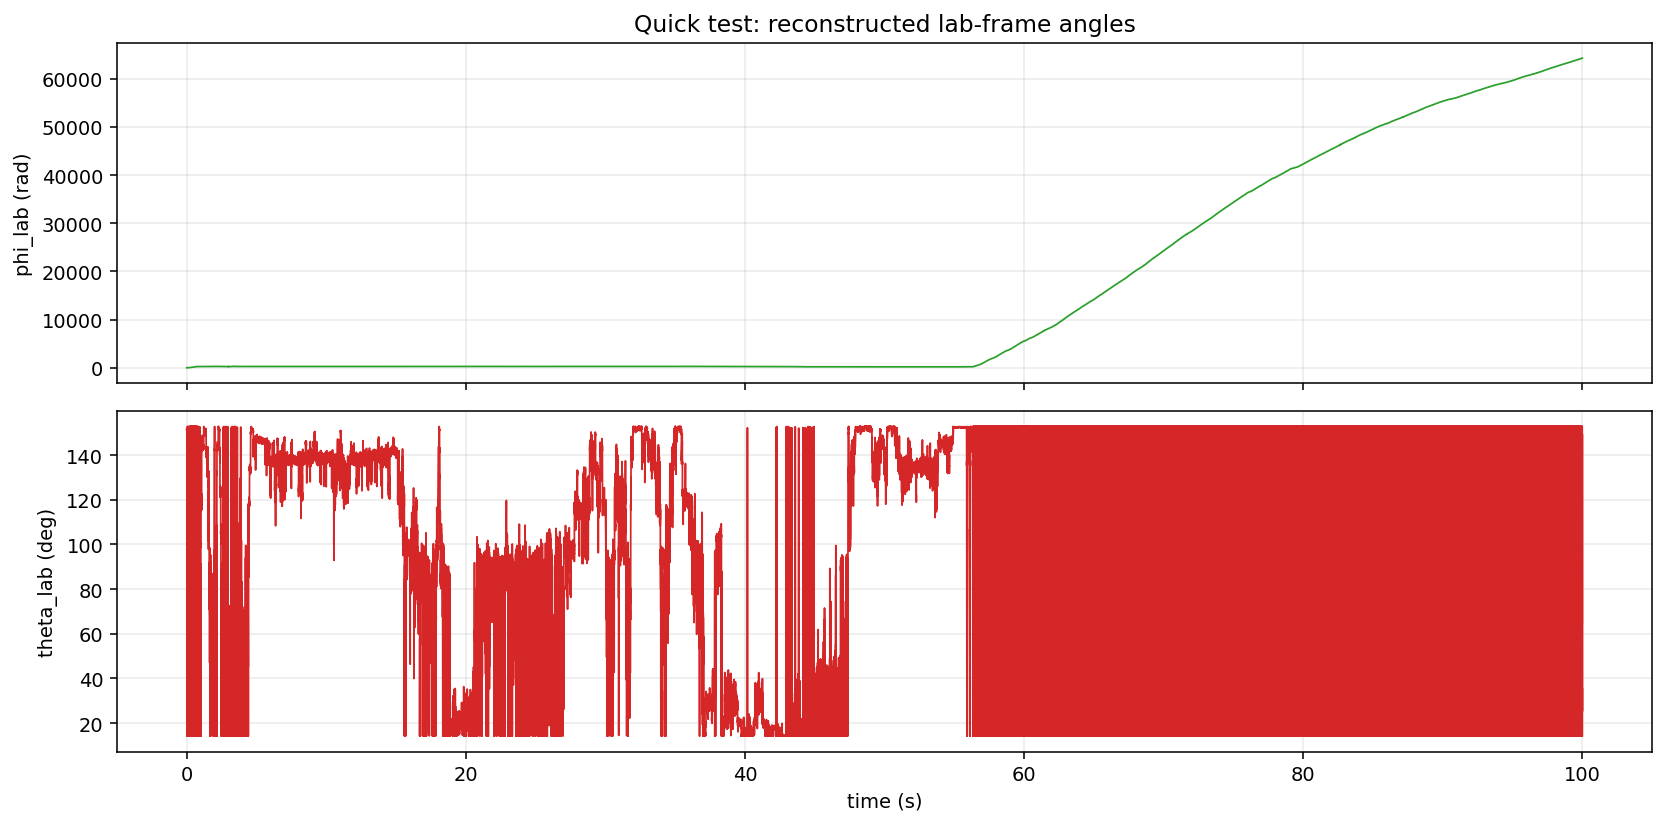

Test window: TEST_T_START=0.0, TEST_T_END=500
Plotted phi_lab/theta_lab for 2,500,001 points in test window


In [75]:
# ── Quick test plot: phi_lab and theta_lab in test window ─────────────────────
# Uses TEST_T_START / TEST_T_END defined in the previous quick-look cell.
if "TEST_T_START" not in globals() or "TEST_T_END" not in globals():
    raise RuntimeError("Define TEST_T_START / TEST_T_END (run the previous quick-look psi cell) first.")

_mask_test = np.ones(len(_time_phase), dtype=bool)
if TEST_T_START is not None:
    _mask_test &= _time_phase >= TEST_T_START
if TEST_T_END is not None:
    _mask_test &= _time_phase <= TEST_T_END

t_test = _time_phase[_mask_test]
phi_lab_test = phi_lab[_mask_test]
theta_lab_test = theta_lab[_mask_test]

if len(t_test) == 0:
    print("No points in selected test window for phi_lab/theta_lab plot.")
else:
    fig, (ax_phi, ax_theta) = plt.subplots(2, 1, figsize=(12, 6), dpi=140, sharex=True)

    ax_phi.plot(t_test, phi_lab_test, lw=0.9, color="tab:green")
    ax_phi.set_ylabel("phi_lab (rad)")
    ax_phi.grid(alpha=0.25)
    ax_phi.set_title("Quick test: reconstructed lab-frame angles")

    ax_theta.plot(t_test, theta_lab_test, lw=0.9, color="tab:red")
    ax_theta.set_xlabel("time (s)")
    ax_theta.set_ylabel("theta_lab (deg)")
    ax_theta.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    print(f"Test window: TEST_T_START={TEST_T_START}, TEST_T_END={TEST_T_END}")
    print(f"Plotted phi_lab/theta_lab for {len(t_test):,} points in test window")

## 11. Output figures

Render summary figures for the anisotropy cloud, sphere trajectory, and rotation speed.

The speed figure uses `SPEED_ENFORCE_MONOTONIC_PSI` (default `True`), which projects `psi` to its running maximum before windowed slope estimation. This suppresses backward rotation; set to `False` to see signed instantaneous speed.


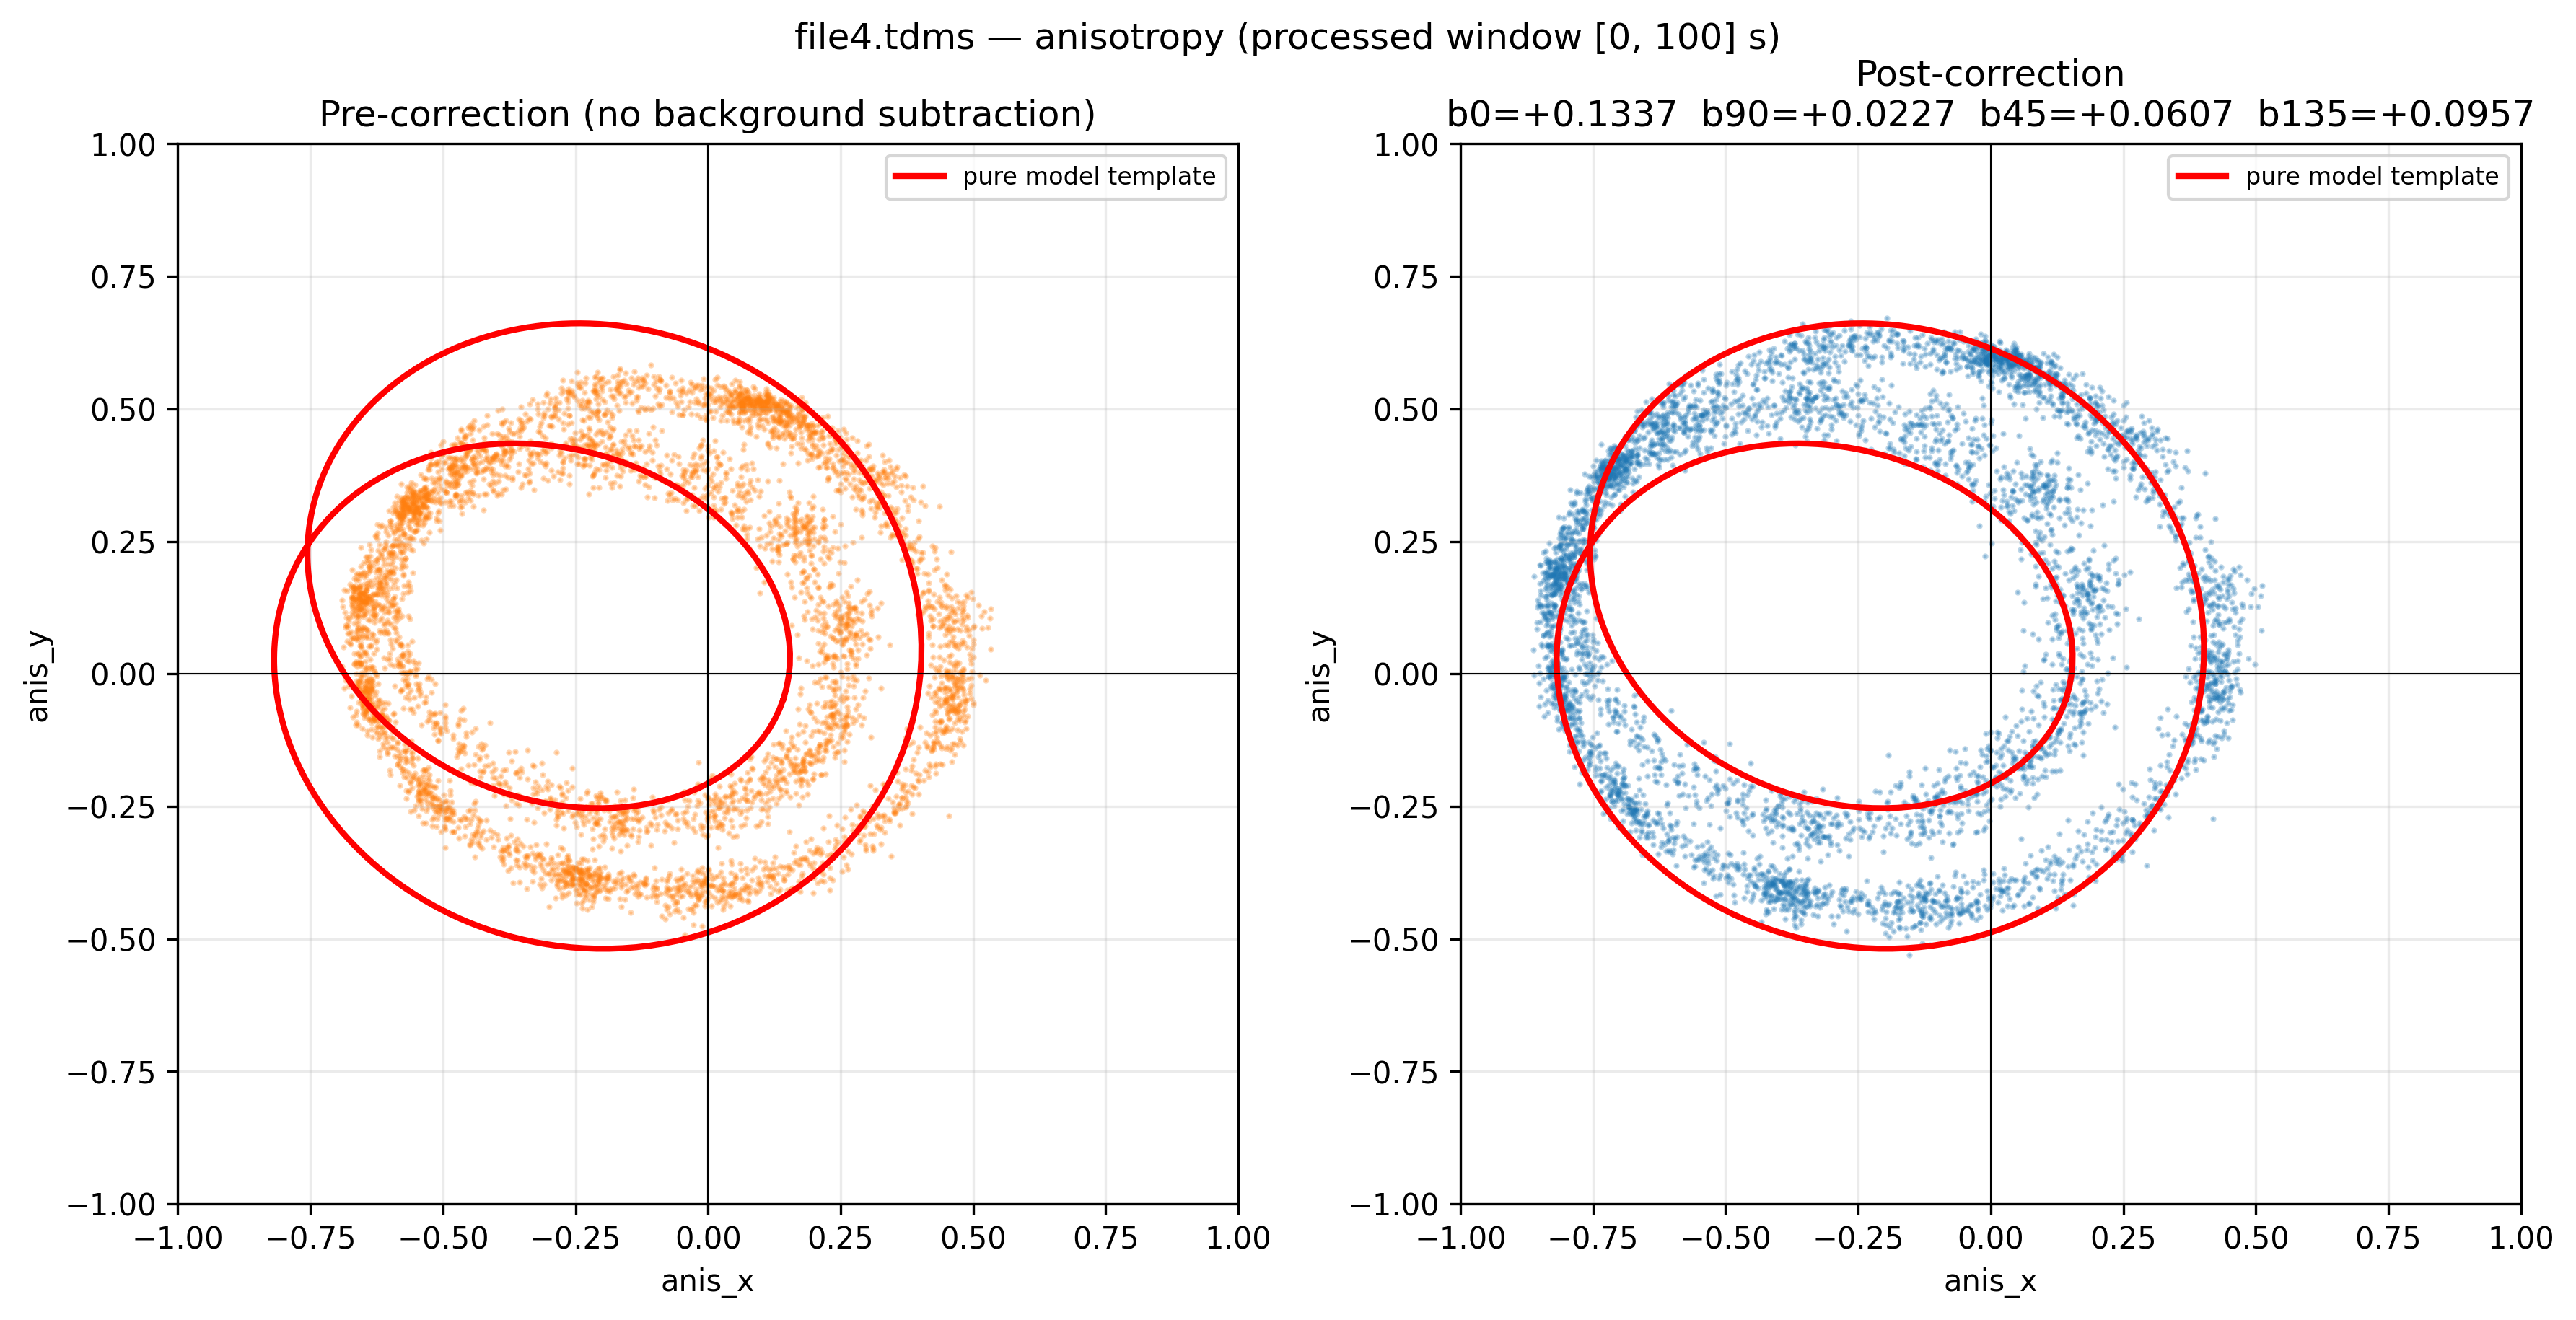

Saved: 01_anisotropy_shape.png


In [76]:
# ── Figure 1: Anisotropy shape (pre- and post-correction) ────────────────────
_dec_sc = max(1, len(anis_x[_mask]) // 5000)
_ax_sc  = anis_x[_mask][::_dec_sc]
_ay_sc  = anis_y[_mask][::_dec_sc]
_ax_nc  = anis_x_nocor[_mask][::_dec_sc]
_ay_nc  = anis_y_nocor[_mask][::_dec_sc]

# Pure model template
_ax_model_pure, _ay_model_pure = fourkas_template(
    Theta_axis_fitted, Phi_axis_fitted, Lambda_fitted, A_cal, B_cal, C_cal)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), dpi=300)

ax1.scatter(_ax_nc, _ay_nc, s=1, alpha=0.3, c="tab:orange", rasterized=True)
ax1.plot(np.append(_ax_model_pure, _ax_model_pure[0]),
         np.append(_ay_model_pure, _ay_model_pure[0]),
         'r-', lw=2, label='pure model template')
ax1.set_title("Pre-correction (no background subtraction)")
ax1.legend(fontsize=8)

ax2.scatter(_ax_sc, _ay_sc, s=1, alpha=0.3, c="tab:blue", rasterized=True)
ax2.plot(np.append(_ax_model_pure, _ax_model_pure[0]),
         np.append(_ay_model_pure, _ay_model_pure[0]),
         'r-', lw=2, label='pure model template')
ax2.set_title(f"Post-correction\n"
              f"b0={b0_fitted:+.4f}  b90={b90_fitted:+.4f}  "
              f"b45={b45_fitted:+.4f}  b135={b135_fitted:+.4f}")
ax2.legend(fontsize=8)

for _ax in (ax1, ax2):
    _ax.axhline(0, color="k", lw=0.5, zorder=3)
    _ax.axvline(0, color="k", lw=0.5, zorder=3)
    _ax.set_xlabel("anis_x"); _ax.set_ylabel("anis_y")
    _ax.set_xlim(-1, 1); _ax.set_ylim(-1, 1)
    _ax.set_aspect("equal"); _ax.grid(alpha=0.25)

_proc_label = f"processed window [{data_t_start}, {data_t_end}] s"
fig.suptitle(f"{tdms_path.name} — anisotropy ({_proc_label})")
plt.tight_layout()
fig.savefig(_output_dir / "01_anisotropy_shape.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: 01_anisotropy_shape.png")

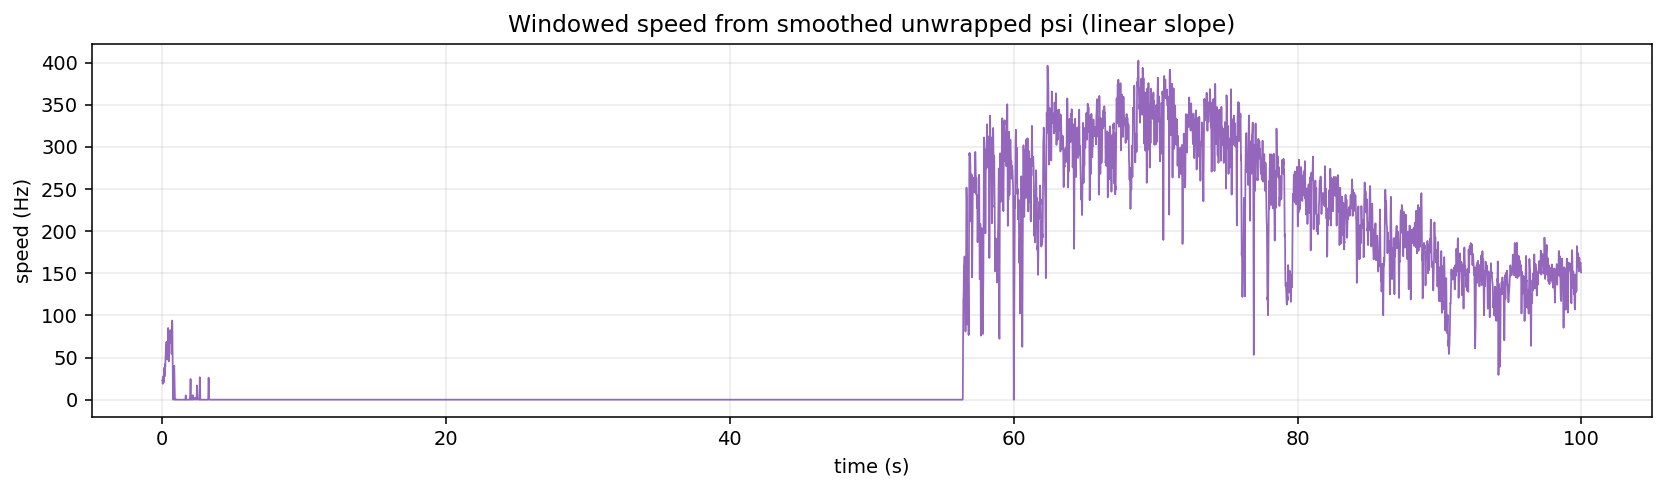

Speed settings:
  PHASE_DECIMATION=10 -> dt_phase=40.00 us
  speed_window_s=0.050000 (1250 samples)
  speed_overlap_s=0.040000 (1000 samples)
  windows=9996, step=250 samples
  SPEED_ENFORCE_MONOTONIC_PSI=True
Speed summary: mean=102.308 Hz, std=126.358 Hz
Saved: 02_speed_from_psi.png


In [77]:
# ── Figure 2: Speed from smoothed unwrapped psi (windowed robust slope) ─────────
speed_window_s = 0.05    # seconds
speed_overlap_s = 0.04   # seconds (must be < speed_window_s)

# Use monotonic projection by default so speed reflects net forward rotation.
SPEED_ENFORCE_MONOTONIC_PSI = True

if ANGLE_RECONSTRUCTION_MODE == "direct_fourkas":
    print("Speed plot skipped: ANGLE_RECONSTRUCTION_MODE='direct_fourkas'.")
    print("(This mode uses direct Fourkas angles only; psi-speed is intentionally not plotted.)")
else:
    _dt_phase = float(np.median(np.diff(_time_phase))) if len(_time_phase) > 1 else np.nan
    if not np.isfinite(_dt_phase) or _dt_phase <= 0:
        raise RuntimeError(
            "Invalid `_time_phase` spacing; run the processed-window phase-tracking cell (Section 10) first."
        )

    speed_nperseg = max(5, int(round(speed_window_s / _dt_phase)))
    speed_overlap = int(round(speed_overlap_s / _dt_phase))
    speed_overlap = min(max(0, speed_overlap), speed_nperseg - 1)
    speed_step = speed_nperseg - speed_overlap

    if len(psi) < speed_nperseg:
        raise RuntimeError(
            f"Not enough samples for speed window: len(psi)={len(psi)}, nperseg={speed_nperseg}. "
            "Reduce speed_window_s or run with smaller PHASE_DECIMATION."
        )

    psi_for_speed = np.maximum.accumulate(psi) if SPEED_ENFORCE_MONOTONIC_PSI else psi

    _nw = 1 + (len(psi_for_speed) - speed_nperseg) // speed_step
    speed_hz = np.empty(_nw, dtype=float)
    speed_time = np.empty(_nw, dtype=float)

    for _w in range(_nw):
        _s = _w * speed_step
        _e = _s + speed_nperseg
        _t = _time_phase[_s:_e]
        _p = psi_for_speed[_s:_e]
        _tc = _t - _t[0]
        _n = len(_tc)
        _sum_t = np.sum(_tc)
        _sum_p = np.sum(_p)
        _sum_tt = np.sum(_tc * _tc)
        _sum_tp = np.sum(_tc * _p)
        _den = _n * _sum_tt - _sum_t * _sum_t
        _slope = (_n * _sum_tp - _sum_t * _sum_p) / _den if abs(_den) > 1e-30 else 0.0
        speed_hz[_w] = _slope / (2.0 * np.pi)
        speed_time[_w] = 0.5 * (_t[0] + _t[-1])

    fig_sp, ax_sp = plt.subplots(1, 1, figsize=(12, 3.6), dpi=140)
    ax_sp.plot(speed_time, speed_hz, lw=0.9, color="tab:purple")
    ax_sp.set_xlabel("time (s)")
    ax_sp.set_ylabel("speed (Hz)")
    ax_sp.set_title("Windowed speed from smoothed unwrapped psi (linear slope)")
    ax_sp.grid(alpha=0.25)
    plt.tight_layout()
    fig_sp.savefig(_output_dir / "02_speed_from_psi.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Speed settings:")
    print(f"  PHASE_DECIMATION={PHASE_DECIMATION} -> dt_phase={_dt_phase*1e6:.2f} us")
    print(f"  speed_window_s={speed_window_s:.6f} ({speed_nperseg} samples)")
    print(f"  speed_overlap_s={speed_overlap_s:.6f} ({speed_overlap} samples)")
    print(f"  windows={_nw}, step={speed_step} samples")
    print(f"  SPEED_ENFORCE_MONOTONIC_PSI={SPEED_ENFORCE_MONOTONIC_PSI}")

    print(f"Speed summary: mean={np.nanmean(speed_hz):.3f} Hz, std={np.nanstd(speed_hz):.3f} Hz")
    print("Saved: 02_speed_from_psi.png")

C:\Users\denny\AppData\Local\Temp\ipykernel_10956\2780390410.py:64: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\denny\AppData\Local\Temp\ipykernel_10956\2780390410.py:66: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig_ang.savefig(_output_dir / "03_angles_by_mode.png", dpi=300, bbox_inches="tight")
c:\Users\denny\workspace\pyqtrod\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


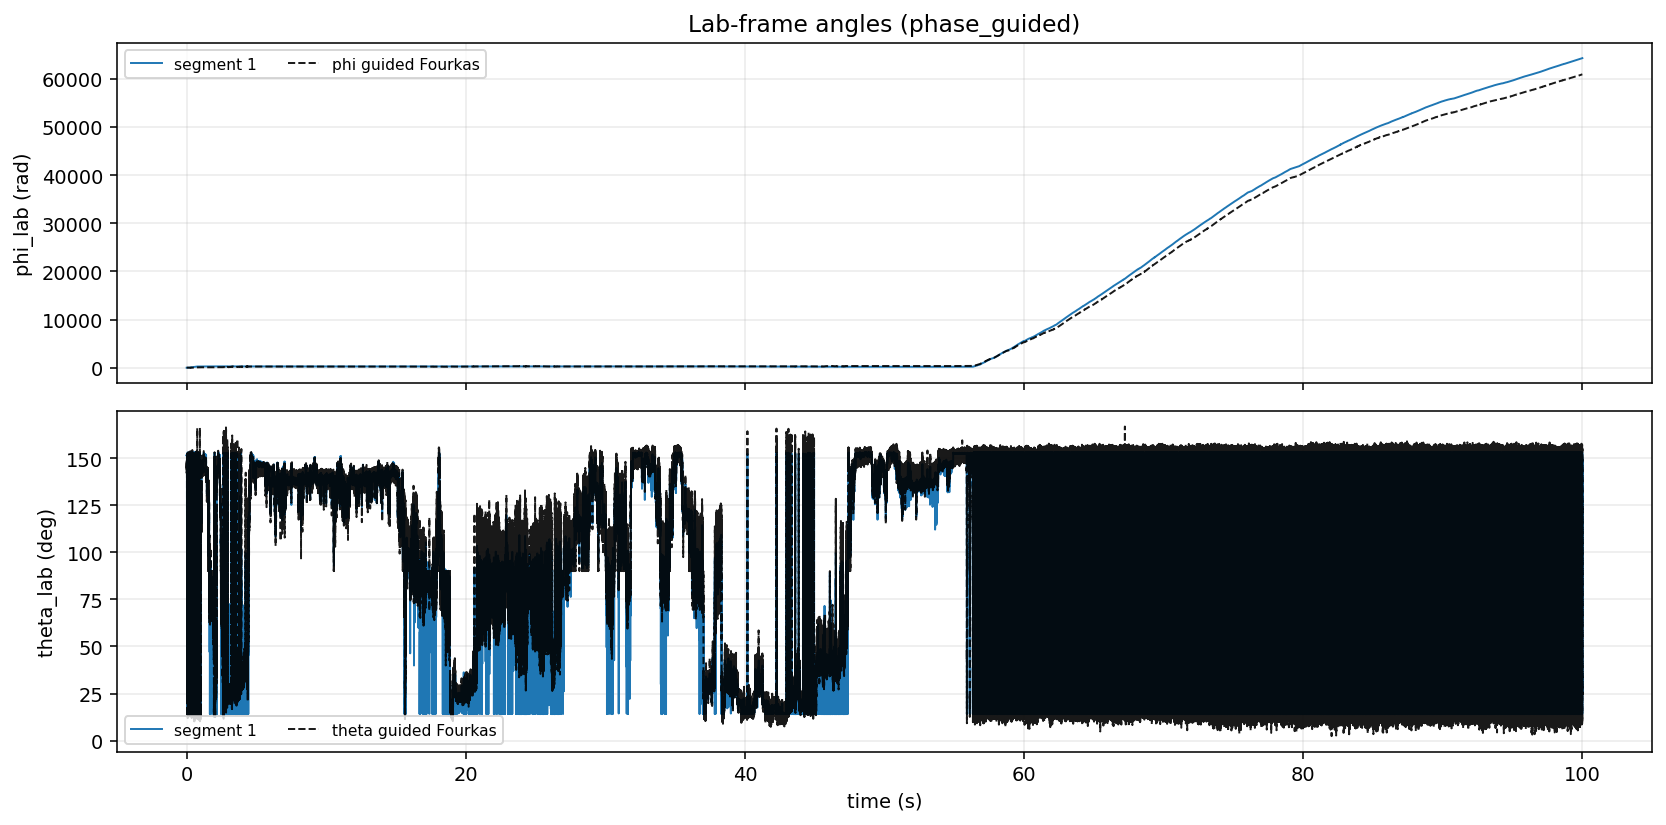

Saved: 03_angles_by_mode.png


In [78]:
# ── Figure 3: Lab-frame angle traces by reconstruction mode ───────────────────
if "_time_phase" not in globals() or "theta_lab" not in globals() or "phi_lab" not in globals():
    raise RuntimeError(
        "Angle traces are not built. Run the processed-window phase-tracking cell "
        "(Section 10) before this figure cell."
    )

_mask_phase = np.ones(len(_time_phase), dtype=bool)
if plot_t_start is not None:
    _mask_phase &= _time_phase >= plot_t_start
if plot_t_end is not None:
    _mask_phase &= _time_phase <= plot_t_end

_ta = _time_phase[_mask_phase]
if len(_ta) == 0:
    print("No points in selected figure window for angle plot.")
else:
    fig_ang, (axp, axt) = plt.subplots(2, 1, figsize=(12, 6), dpi=140, sharex=True)

    if ANGLE_RECONSTRUCTION_MODE == "phase_guided":
        _phi_guided = phi_lab_guided[_mask_phase]
        _theta_guided = theta_lab_guided[_mask_phase]

        # Segment-colored phase-matched traces (axis-refit segments).
        _colors = plt.cm.tab20(np.linspace(0, 1, max(1, len(phase_segment_ranges))))
        for _k, (_s, _e) in enumerate(phase_segment_ranges):
            _seg_mask = np.zeros(len(_time_phase), dtype=bool)
            _seg_mask[_s:_e] = True
            _seg_mask &= _mask_phase
            if not np.any(_seg_mask):
                continue
            _tt = _time_phase[_seg_mask]
            _pp = phi_lab_phase[_seg_mask]
            _th = theta_lab_phase[_seg_mask]
            _lab = f"segment {_k+1}"
            axp.plot(_tt, _pp, lw=1.0, color=_colors[_k], label=_lab)
            axt.plot(_tt, _th, lw=1.0, color=_colors[_k], label=_lab)

        # Overlay guided Fourkas traces in black dashed for comparison.
        axp.plot(_ta, _phi_guided, lw=1.0, color="k", ls="--", alpha=0.9, label="phi guided Fourkas")
        axt.plot(_ta, _theta_guided, lw=1.0, color="k", ls="--", alpha=0.9, label="theta guided Fourkas")

        # Mark refit event times.
        if "phase_refit_events" in globals() and len(phase_refit_events) > 0:
            for _ev in phase_refit_events:
                _tx = float(_ev["t"] )
                if (_tx >= _ta[0]) and (_tx <= _ta[-1]):
                    axp.axvline(_tx, color="0.3", lw=0.8, ls=":", alpha=0.8)
                    axt.axvline(_tx, color="0.3", lw=0.8, ls=":", alpha=0.8)
    else:
        _phi_direct = phi_lab[_mask_phase]
        _theta_direct = theta_lab[_mask_phase]
        axp.plot(_ta, _phi_direct, lw=1.0, color="tab:green", label="phi direct Fourkas")
        axt.plot(_ta, _theta_direct, lw=1.0, color="tab:red", label="theta direct Fourkas")

    axp.set_ylabel("phi_lab (rad)")
    axt.set_ylabel("theta_lab (deg)")
    axt.set_xlabel("time (s)")
    axp.grid(alpha=0.25)
    axt.grid(alpha=0.25)
    axp.legend(fontsize=8, ncol=2)
    axt.legend(fontsize=8, ncol=2)
    axp.set_title(f"Lab-frame angles ({ANGLE_RECONSTRUCTION_MODE})")
    plt.tight_layout()

    fig_ang.savefig(_output_dir / "03_angles_by_mode.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: 03_angles_by_mode.png")

## Export fit parameters + tracked phase

Saves a compact `.npz` file containing fit parameters and the KDTree-tracked phase trace for downstream analysis.

In [79]:
# ── Export fit parameters + tracked phase ─────────────────────────────────────
_export_path = _output_dir / "fit_params.npz"

np.savez(
    _export_path,
    # ── Fitted geometry ──
    Theta_axis=Theta_axis_fitted,
    Phi_axis=Phi_axis_fitted,
    Lambda=Lambda_fitted,
    uncertainties=uncertainties,
    # ── Fitted backgrounds ──
    dc=dc_fitted, fa=fa_fitted, fb=fb_fitted,
    b0=b0_fitted, b90=b90_fitted, b45=b45_fitted, b135=b135_fitted,
    # ── Channel correction ──
    a=np.array(a),       # gains [a_90, a_45, a_135, a_0]
    matcor=matcor,       # 4x4 T-matrix (in stack order)
    # ── Calibration constants ──
    NA_calibrated=NA_CALIBRATED,
    nw=nw,
    A_cal=A_cal, B_cal=B_cal, C_cal=C_cal, R_sat=R_SAT,
    # ── Tracked phase outputs (explicit names) ──
    phase_time=_time_phase,
    phase_psi=psi,
    phase_theta_lab=theta_lab,
    phase_phi_lab=phi_lab,
    phase_idx=_idx_path,
    phase_decimation=PHASE_DECIMATION,
    phase_template_points=PHASE_KDTREE_N_MODEL,
    # ── Data info ──
    freq=freq,
    tdms_path=str(tdms_path),
)

_size_mb = _export_path.stat().st_size / 1e6
print(f"Saved: {_export_path}  ({_size_mb:.2f} MB)")
print("  Contains: axis params, backgrounds, channel corrections, calibration, tracked phase trace")

Saved: C:\Users\denny\workspace\pyqtrod\data_analysed\2025_07_02_MT_DX_MRB\file4\fit_params.npz  (90.01 MB)
  Contains: axis params, backgrounds, channel corrections, calibration, tracked phase trace
